# Uplift Modeling
**Background**  
- 【背景】カフェチェーンのCRM戦略
  - あるカフェチェーン。10店舗（Store A〜J）、1万人規模のアプリ会員を持つ
  - 今回は「ラテ」の売上を伸ばすために、アプリでクーポンを配るキャンペーンを企画している
- 【課題】利益の最大化と無駄の排除
  - 全員配布は損: クーポンをあげなくても買う「鉄板層」に配ると、50円（割引分）損をする
  - 予算の壁: 全員に配る予算はないので、効果が出やすい人（クーポンないと買わなそうだが、あると買いやすそうな人）を選びたい
  - 「処置による増分」が見えない: 単なる予測モデルだと「買いそうな人」はわかるけど「クーポン配布のおかげで買う人」はわからない
- 【問題の設定】アップリフトモデリング
  - ユーザーごとに『クーポンがある時の購入確率』と『ない時の購入確率』の差（＝アップリフトスコア）を算出し、TopN人を選び出す
- 【解法】Meta-Learner
1. サンプルデータには、is_treatment（クーポン配布有無）や各種特徴量、結果変数（購入したかどうか）がある
1. これらを使って学習させ、処置した場合の予測値と処置しなかった場合の予測値を算出して差分スコアを出す
1. このスコアが高い人こそが「クーポン配布という処置によって、行動が一番ポジティブに変わる人」という前提で解く

## LightGBM (LGBM)
- 速くて、カテゴリカル変数のまま扱えるので楽。最初に使いたい。
- 仕組み: Gradient Boosting Decision Tree (GBDT) の一種。Leaf-wise（葉単位）の成長などにより高速かつ高精度な学習。
- 長所: 非線形な関係や交互作用を自動的に抽出する能力高い。高次元なカテゴリ変数の処理効率が極めて高い。
- 短所: 複雑な条件分岐をおこなうためデータの局所的なノイズに過学習するリスク。ハイパーパラメータ調整が精度に影響する。
- Leaf-wise: 木を縦に伸ばしていく育て方。誤差を一番減らせそうなノードを見つけて優先的に深く掘り下げてく。効率的に精度を上げられるがデータが少ないと一部の枝だけが伸びすぎて過学習しやすい。
- GOSS: 誤差が小さい（もう学習できてる）データは無視して、誤差が大きいデータだけを使って効率よく計算する。
- EFB: 関連性の低い特徴量同士をひとつにまとめて、扱うデータの種類を減らす。これらによりLGBMは圧倒的なスピードを手に入れた。

## Meta-Learner
**S-Learner, T-Learner共通**  
- 処置した場合の「購入する確率 prob_t」と、処置しなかった場合の「購入する確率 prob_c」とを予測している
  - prob_t(Probability if Treated): もしこの人に処置をしたら何％の確率で購入するかという予測値（期待値）
  - prob_c(Probability if Control): もしこの人に処置をしなかったら何％の確率で購入するかという予測値（期待値）
- ターゲット: 結果変数Y（観測データにおける購入した/しなかったという事実そのもの）
- 不純度を減らす対象: 購入確率の予測値と、観測データとのズレ

**S-Learner（一括学習、仮想推論）**  
- 学習: 特徴量に処置の有無も含める。処置の有無も特徴量の1つとして扱い、1つのモデルで学習させる。
- 推論: 全員に処置した場合と全員に処置しなかった場合とを1つのモデルで予測させ、その差分でスコア（処置効果 CATE）を算出

**T-Learner（分離学習、並行推論）**  
- 学習: データを処置あり/なしで物理的に分け、2つの独立したモデル（Treat,Control）をそれぞれ別々に学習させる。
- 推論: 2つのモデルそれぞれに予測させ、その差分でスコア（処置効果 CATE）を算出


**X-Learner（二段階推論、残差回帰型）**  
- 「処置効果 CATE の推定値」を予測している（処置による増減度合い、リフトの大きさという点でS,Tと異なる）
- ターゲット: D 個別処置効果（ITE）の推定値。買った事実ではなく「この人にとってのプラスαの価値」を直接的にターゲットとしている。
- 不純度を減らす対象：モデルの予測値と、擬似アウトカム（観測データでの事実とモデルが予測した反実仮想との差分）とのズレ

1. 学習: データを処置あり/なしで物理的に分け、2モデルをそれぞれ別々に学習させる（T-learnerと同じ）
1. 学習: 観測データでの購入結果と、上記モデルが予測した反実仮想との差分で、擬似的な処置効果（D値）ITEを全員分算出する
1. 学習: 擬似的な処置効果そのものをターゲット（目的変数）にして、リフトの大きさを直接当てるための回帰モデルをさらに学習させる
1. 推論: 傾向スコアを使って、二つの回帰モデルを重み付けすることで、リフトの大きさを回帰で推定する

X-Learnerは2つの回帰モデルを作っている（処置群データをベースに作ったリフト予測と、対照群データをベースに作ったリフト予測）
傾向スコア（年齢や来店回数などなんらか特徴を持つ人が、どのくらいの確率で処置群に割り振られやすいか、処置の受けやすさ）を使って、処置群に近い特徴の人には処置群ベースのモデルを、対照群に近い特徴の人には対照群ベースのモデルを重く採用することで重み付けしている

**S-Learnerの弱点:**  
- 処置効果にバイアス（偏り）が発生する傾向がある
- 処置変数を使って分割しても予測精度がほとんど上がらないなら、この変数を使うのは情報の利得がないと判断して、処置変数での分割をおこなわなくなる（無視されやすい）。また処置効果の貢献度がちょっとはあったとしても正則化により控えめになりがち。
- 以上からS-Learnerでは（処置変数を他の特徴量と同じに扱う構造であるがゆえに）特に処置変数Tの結果変数Yへの影響が共変量Xに比べて小さい場合、ゼロに向かってバイアスかかる可能性ある。

**T-Learnerの弱点:**  
- 引き続き正則化バイアス（偏り）が発生する場合がある
- treatとcontrolは別々に学習する。そのため正則化の効き具合が独立に決まる（片方では強く抑制されもう片方では弱く抑制されるなどバラバラ）。すると差分をとったときにバイアスが残ったり増幅されるリスクがある（scoreの分散大きくなりがち）
- またtreat,controlに分割することで（サンプルサイズ小さく分散大きくなり）データが疎の領域が出現。正則化かかってるとデータ不足の未知領域においてモデルは安全策として予測値を平均値やゼロに近づけようとする。treatもconotrolもよくわからないからゼロ（または平均）と答えを出し、結果的にその差分であるscoreもゼロに。
- 以上からT-Learnerにおいても（2モデルに分割する構造であるがゆえに）S-Learner同様にバイアス発生する場合ある。

**X-Learnerの利点:**  
- アップリフトモデリングにちょうどいい
- T-Learnerのtreatモデルは処置した人のデータだけで学習する。当然処置しなかった場合の結果変数（正解データ）はない。そこで処置しなかった場合の潜在的結果変数として、controlモデルでの推定値を使用する。同様にcontrolモデルでは、処置した場合の潜在的結果変数としてtreatモデルでの推定値を使用する。こうして反実仮想との差分を取ることで処置群対照群それぞれのITEを推定する（Individual Treatment Effect 個々の因果効果）。そしてCATE（Conditional Average Treatment Effect 条件付き平均処置効果）を推定する。
- だがこれだけならT-Learner同様にサンプルサイズ小さいときに推定精度が低い可能性ある。そこで推定したCATEに重み付けをおこなう。これには傾向スコアを使うのがいいとわかっている。
- 傾向スコアで重み付けすることで、処置群と対照群の共変量の不均衡を調整し、観測された共変量による選択バイアスを低減させる。例えば、介入群（T）が極端に少なく、対照群（C）が膨大な場合、介入群で作った不安定なモデルよりも、データが豊富な対照群ベースの推計値を重視する（前者の影響を小さく、後者の重みを大きくする）のでデータの不均衡に強い。
- 以上からX-Learnerではバイアスを低減させつつ、処置による増分を直接学習する構造なのがピッタリとも言える。

**X-Learnerの弱点:**  
- 差分（増減分）に注目しすぎるあまり、購入確率は低いけど処置による純増確率は高い（ふだんは購入しないけど、処置で激変する）を高く評価してしまう可能性あり（ROIよくないところに着目しすぎ）

In [1]:
# import
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

# from causalimpact import CausalImpact
# from prophet import Prophet
# import pymc as pm
# import arviz as az

import sklearn
import lightgbm as lgb
import shap
# import xgboost as xgb

# create datetime
print("Created(JST)", pd.Timestamp.now(tz="Asia/Tokyo").strftime("%Y-%m-%d %H:%M:%S"))

# version
print("pandas", pd.__version__)
print("numpy", np.__version__)
print("matplotlib", plt.matplotlib.__version__)
print("seaborn", sns.__version__)
# import causalimpact; print("causalimpact", causalimpact.__version__)
# import prophet; print("prophet", prophet.__version__)
# print("pymc", pm.__version__)
# print("arviz", az.__version__)

print("scikit-learn", sklearn.__version__)
print("lightgbm", lgb.__version__)
import shap; print("shap", shap.__version__)
# print("xgboost", xgb.__version__)

Created(JST) 2026-05-05 10:03:03
pandas 3.0.2
numpy 2.4.3
matplotlib 3.10.9
seaborn 0.13.2
scikit-learn 1.8.0
lightgbm 4.6.0
shap 0.51.0


In [2]:
# サンプルのdataframeを生成する
import string

# 乱数固定
np.random.seed(42)

# --- 基本設定 ---
n_stores = 10  # 10店舗くらいある設定にする
n_customers_per_store = 1000 # 1店舗あたり1000人くらい
n_total = n_stores * n_customers_per_store
chars = string.ascii_lowercase + string.digits

# 1. ID系の生成
store_ids = [f'Store_{string.ascii_uppercase[i]}' for i in range(n_stores)]
# 英小文字と数字の8桁ID
customer_ids = [''.join(np.random.choice(list(chars), 8)) for _ in range(n_total)]

# 2. 顧客マスタ & 過去ログ
# 会員歴（年）: 指数分布っぽく（新しい人の方が多い）
membership_years = np.random.exponential(2, n_total).clip(0.5, 10)

# 過去3ヶ月の来店回数: 平均月4回（週1）くらい
past_visit_frequency = np.random.poisson(12, n_total) 

# 過去のラテ購入率（これが潜在的な好みの代理指標になる）0.1〜0.9の間で分布
past_latte_ratio = np.random.beta(2, 5, n_total)

# 過去のクーポン利用率（これが感度の代理指標になる）
past_coupon_usage_rate = np.random.beta(1, 3, n_total)

# 3. 当日のコンテキスト
# 日付はキャンペーン当日のイメージ
campaign_date = pd.Timestamp('2025-07-10')
# 店舗IDを割り振り
assigned_stores = np.random.choice(store_ids, n_total)
# 気温（店舗ごとに少し変えてもいいけどまずはランダムで）
current_temp = np.random.normal(15, 5, n_total)
is_raining = np.random.binomial(1, 0.2, n_total)


# 4. 処置フラグ（is_treatment）
# A/Bテストのようにランダムにクーポンを送る
is_treatment = np.random.binomial(1, 0.5, n_total)


# --- 5. 購買フラグ（is_purchased）の裏ロジック ---
# ここは「観測できない真理」として定義。生成されるのは結果のみ
# 基本確率 + 好みによる加算 + クーポンによる押し上げ(感度) - 雨による低下
# 少しだけ店舗ごとのクセも混ぜる
store_effect = {s: np.random.normal(0, 0.5) for s in store_ids}
store_bias = np.array([store_effect[s] for s in assigned_stores])

base_logit = (
    -2.5 
    + (past_latte_ratio * 5.0) 
    + (is_treatment * past_coupon_usage_rate * 6.0) # クーポンへの反応
    + store_bias # 店舗ごとの売れやすさ
    - (current_temp * 0.08) # 寒いほどラテ
    - (is_raining * 1.2) # 雨はやっぱり厳しい...
)

prob = 1 / (1 + np.exp(-base_logit))
is_purchased = np.random.binomial(1, prob)

# --- DataFrameにまとめる ---
df1 = pd.DataFrame({
    'date': campaign_date,
    'customer_id': customer_ids,
    'store_id': assigned_stores,
    'membership_years': membership_years,
    'visit_frequency': past_visit_frequency,
    'past_latte_ratio': past_latte_ratio,
    'past_coupon_usage_rate': past_coupon_usage_rate,
    'current_temp': current_temp,
    'is_raining': is_raining,
    'is_treatment': is_treatment,
    'is_purchased': is_purchased
})

In [3]:
print(df1.head())
# print(df1.tail())
# print(df1.info())

        date customer_id store_id  membership_years  visit_frequency  \
0 2025-07-10    2ohuswkk  Store_D          0.500000               11   
1 2025-07-10    x9xcvbx3  Store_E          8.094284               16   
2 2025-07-10    bu6lvy01  Store_G          1.757246               15   
3 2025-07-10    pocguird  Store_I          1.678419               15   
4 2025-07-10    ynizbt1g  Store_F          0.889914               17   

   past_latte_ratio  past_coupon_usage_rate  current_temp  is_raining  \
0          0.512749                0.599454     17.369056           1   
1          0.106634                0.133991     16.182607           0   
2          0.082623                0.156412     13.797987           0   
3          0.568721                0.453719      5.640766           0   
4          0.267246                0.264691     10.145935           0   

   is_treatment  is_purchased  
0             1             1  
1             0             0  
2             0             0  


In [4]:
print(df1.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    10000 non-null  datetime64[us]
 1   customer_id             10000 non-null  str           
 2   store_id                10000 non-null  str           
 3   membership_years        10000 non-null  float64       
 4   visit_frequency         10000 non-null  int64         
 5   past_latte_ratio        10000 non-null  float64       
 6   past_coupon_usage_rate  10000 non-null  float64       
 7   current_temp            10000 non-null  float64       
 8   is_raining              10000 non-null  int64         
 9   is_treatment            10000 non-null  int64         
 10  is_purchased            10000 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(4), str(2)
memory usage: 859.5 KB
None


In [5]:
# 数値型の列（int系とfloat系）を抽出して、すべて float64 に統一
float_cols = df1.select_dtypes(include=['int64', 'int32', 'float64', 'float32']).columns
df1[float_cols] = df1[float_cols].astype(float)

In [6]:
# 数値データのみを対象にする
print(df1.describe())

                      date  membership_years  visit_frequency  \
count                10000      10000.000000     10000.000000   
mean   2025-07-10 00:00:00          2.059469        12.029400   
min    2025-07-10 00:00:00          0.500000         2.000000   
25%    2025-07-10 00:00:00          0.575110        10.000000   
50%    2025-07-10 00:00:00          1.366649        12.000000   
75%    2025-07-10 00:00:00          2.774599        14.000000   
max    2025-07-10 00:00:00         10.000000        27.000000   
std                    NaN          1.927320         3.443591   

       past_latte_ratio  past_coupon_usage_rate  current_temp    is_raining  \
count      10000.000000            10000.000000  10000.000000  10000.000000   
mean           0.285198                0.247807     14.957699      0.202000   
min            0.003303                0.000008     -3.405199      0.000000   
25%            0.159193                0.089301     11.566117      0.000000   
50%            0.26

In [7]:
# 「数値以外（カテゴリデータなど）」の要約（頻度やユニーク数）も見たい場合
df1.describe(exclude='number')

,date,customer_id,store_id
count,10000,10000,10000
unique,NaN,10000,10
top,NaN,2ohuswkk,Store_A
freq,NaN,1,1063
mean,2025-07-10 00:00:00,NaN,NaN
min,2025-07-10 00:00:00,NaN,NaN
25%,2025-07-10 00:00:00,NaN,NaN
50%,2025-07-10 00:00:00,NaN,NaN
75%,2025-07-10 00:00:00,NaN,NaN
max,2025-07-10 00:00:00,NaN,NaN


## check by store
- 店舗ごとに、特徴量の値と処置効果の関係を見てみる

In [8]:
df1.groupby('store_id')['is_purchased'].describe(percentiles=[.25, .5, .75, .9, .95, .99]).round(3)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
store_id,,,,,,,,,,,
Store_A,1063.0,0.114,0.318,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_B,992.0,0.292,0.455,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
Store_C,997.0,0.267,0.443,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
Store_D,1008.0,0.302,0.459,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
Store_E,1005.0,0.207,0.405,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_F,1014.0,0.243,0.429,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_G,980.0,0.234,0.423,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_H,981.0,0.225,0.418,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_I,1023.0,0.079,0.270,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0


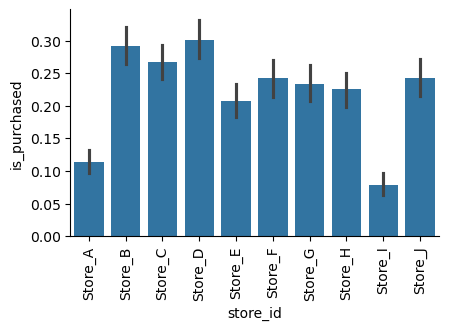

In [9]:
sns.catplot(data=df1, x="store_id", y="is_purchased", kind="bar", aspect=1.5, height=3, order=sorted(df1['store_id'].unique()))
plt.xticks(rotation=90)
plt.show()

In [10]:
df1.groupby('store_id')['past_latte_ratio'].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
store_id,,,,,,,,
Store_A,1063.0,0.298,0.162,0.004,0.175,0.277,0.398,0.835
Store_B,992.0,0.281,0.153,0.008,0.163,0.265,0.380,0.820
Store_C,997.0,0.283,0.161,0.013,0.156,0.255,0.382,0.796
Store_D,1008.0,0.277,0.154,0.011,0.158,0.253,0.368,0.886
Store_E,1005.0,0.288,0.157,0.007,0.166,0.267,0.387,0.840
Store_F,1014.0,0.290,0.162,0.008,0.166,0.269,0.394,0.865
Store_G,980.0,0.285,0.161,0.005,0.156,0.266,0.394,0.775
Store_H,981.0,0.287,0.161,0.005,0.158,0.271,0.393,0.839
Store_I,1023.0,0.284,0.159,0.003,0.154,0.262,0.392,0.824


In [11]:
df1.groupby('store_id')['past_coupon_usage_rate'].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
store_id,,,,,,,,
Store_A,1063.0,0.249,0.196,0.001,0.089,0.199,0.371,0.938
Store_B,992.0,0.247,0.195,0.000,0.088,0.203,0.374,0.952
Store_C,997.0,0.246,0.196,0.000,0.090,0.198,0.363,0.956
Store_D,1008.0,0.254,0.198,0.000,0.090,0.215,0.365,0.915
Store_E,1005.0,0.253,0.193,0.000,0.095,0.211,0.373,0.865
Store_F,1014.0,0.250,0.188,0.000,0.096,0.215,0.361,0.940
Store_G,980.0,0.241,0.185,0.000,0.095,0.200,0.351,0.870
Store_H,981.0,0.250,0.196,0.001,0.085,0.210,0.377,0.914
Store_I,1023.0,0.237,0.190,0.000,0.079,0.189,0.364,0.868


In [12]:
df1.groupby('store_id')['current_temp'].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
store_id,,,,,,,,
Store_A,1063.0,15.2,5.0,-3.0,11.9,15.0,18.7,28.8
Store_B,992.0,14.9,4.9,-3.1,11.6,14.9,18.2,33.7
Store_C,997.0,15.1,5.0,-3.4,11.6,15.1,18.3,33.3
Store_D,1008.0,15.1,4.9,2.7,11.7,15.1,18.3,34.9
Store_E,1005.0,15.0,5.0,-2.2,11.5,15.0,18.3,32.1
Store_F,1014.0,15.0,5.0,-2.1,11.5,15.0,18.2,31.2
Store_G,980.0,14.9,5.1,-0.2,11.4,14.9,18.6,29.3
Store_H,981.0,14.7,4.9,0.1,11.3,14.8,18.0,29.2
Store_I,1023.0,14.8,4.8,-1.5,11.5,14.5,18.0,29.8


In [13]:
df1.groupby('store_id')['is_raining'].describe(percentiles=[.25, .5, .75, .9, .95, .99]).round(3)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
store_id,,,,,,,,,,,
Store_A,1063.0,0.204,0.403,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_B,992.0,0.214,0.410,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_C,997.0,0.207,0.405,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_D,1008.0,0.223,0.417,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_E,1005.0,0.209,0.407,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_F,1014.0,0.177,0.381,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_G,980.0,0.210,0.408,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_H,981.0,0.211,0.408,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
Store_I,1023.0,0.188,0.391,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0


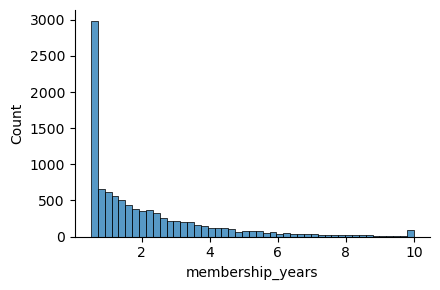

In [14]:
sns.displot(data=df1, x="membership_years", kind="hist", aspect=1.5, height=3)
plt.show()

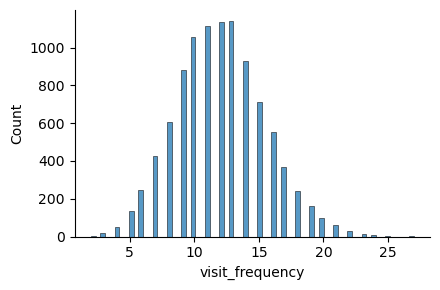

In [15]:
sns.displot(data=df1, x="visit_frequency", kind="hist", aspect=1.5, height=3)
plt.show()

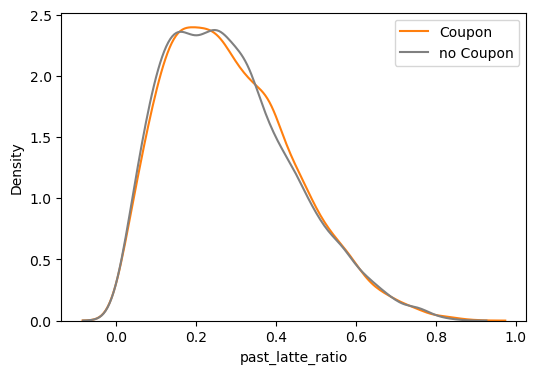

In [16]:
# hue別の数が違う時は個別のkdeplotを重ねる
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df1.query('is_treatment==1'), x="past_latte_ratio", color="tab:orange", label="Coupon")
sns.kdeplot(data=df1.query('is_treatment==0'), x="past_latte_ratio", color="gray", label="no Coupon")
plt.legend(loc='upper right')
plt.show()

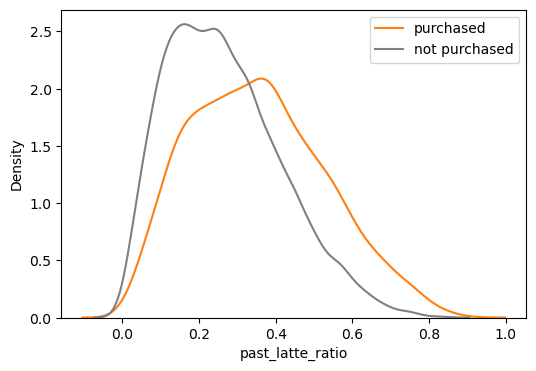

In [17]:
# hue別の数が違う時は個別のkdeplotを重ねる
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df1.query('is_purchased==1'), x="past_latte_ratio", color="tab:orange", label="purchased")
sns.kdeplot(data=df1.query('is_purchased==0'), x="past_latte_ratio", color="gray", label="not purchased")
plt.legend(loc='upper right')
plt.show()

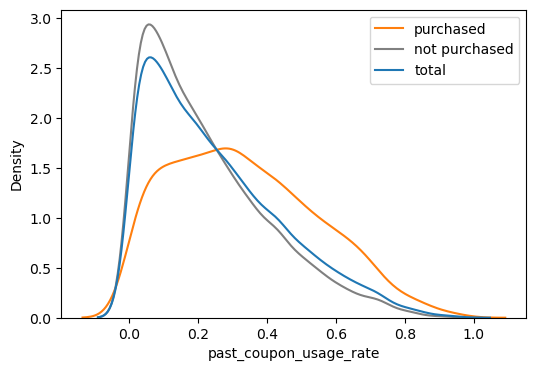

In [18]:
# hue別の数が違う時は個別のkdeplotを重ねる
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df1.query('is_purchased==1'), x="past_coupon_usage_rate", color="tab:orange", label="purchased")
sns.kdeplot(data=df1.query('is_purchased==0'), x="past_coupon_usage_rate", color="gray", label="not purchased")

sns.kdeplot(data=df1, x="past_coupon_usage_rate", color="tab:blue", label="total")

plt.legend(loc='upper right')
plt.show()

# split

In [19]:
from sklearn.model_selection import train_test_split

# store_idをソートしてカテゴリ型にする
# 今ある値を重複なく取ってきて、アルファベット順にソートする
store_order = sorted(df1['store_id'].unique())
# store_order = [f'Store {c}' for c in 'ABCDEFGHIJ']  # 規則性あるならこうでもいい

# 順番（ordered=True）を指定してカテゴリ型に変換
from pandas.api.types import CategoricalDtype
store_type = CategoricalDtype(categories=store_order, ordered=True)
df1['store_id'] = df1['store_id'].astype(store_type)


# 特徴量の整理
# dateやcustomer_idは学習に使わないから除外、is_treatmentは分割に使うから除外
features = [
    'membership_years', 'visit_frequency', 'past_latte_ratio', 'past_coupon_usage_rate', 'current_temp', 'is_raining', 'store_id'
]

# s-learnerはis_treatmentも特徴量に入れる
features_s = features + ['is_treatment']


# 最初に全体をTrainとTestに分ける、これでTestデータのIndexが全モデル共通で固定される
df1_train, df1_test = train_test_split(df1, test_size=0.2, random_state=42)

# S-Learner用のTrainデータ作成
X_s_train = df1_train[features_s]
y_s_train = df1_train['is_purchased']

# データを「処置群群(T)」と「対照群(C)」に分けて
train_t = df1_train.query('is_treatment == 1')
train_c = df1_train.query('is_treatment == 0')
# T/X-Learner用にTrain内で群分け、Indexを保持したまま抽出
X_t_train = train_t[features]
y_t_train = train_t['is_purchased']
X_c_train = train_c[features]
y_c_train = train_c['is_purchased']
# X-Learnerの傾向スコアモデル(g)用の結果変数
y_is_treatment_train = df1_train['is_treatment']

# S-Learner用のテストデータ作成
X_s_test = df1_test[features_s]
y_s_test = df1_test['is_purchased']  # たぶん出番ない
# データを「処置群(T)」と「対照群(C)」に分けて
test_t = df1_test.query('is_treatment == 1')
test_c = df1_test.query('is_treatment == 0')
# T/X-Learner用にTest内で群分け、Indexを保持したまま抽出
X_t_test = test_t[features]
y_t_test = test_t['is_purchased']  # たぶん出番ない
X_c_test = test_c[features]
y_c_test = test_c['is_purchased']  # たぶん出番ない
# X-Learnerの傾向スコアモデル(g)用の結果変数
y_is_treatment_test = df1_test['is_treatment']  # たぶん出番ない

print(X_s_train.shape, y_s_train.shape)
print(X_s_test.shape, y_s_test.shape)
print(X_t_train.shape, y_t_train.shape)
print(X_t_test.shape, y_t_test.shape)
print(X_c_train.shape, y_c_train.shape)
print(X_c_test.shape, y_c_test.shape)
print(y_is_treatment_train.shape)
print(y_is_treatment_test.shape)

(8000, 8) (8000,)
(2000, 8) (2000,)
(4001, 7) (4001,)
(1027, 7) (1027,)
(3999, 7) (3999,)
(973, 7) (973,)
(8000,)
(2000,)


# modeling

In [20]:
from sklearn.calibration import CalibratedClassifierCV

# --- 共通設定 ---
params_clf = {
    'objective': 'binary',  # 分類（買う買わない）タスクであることを明示
    'metric': 'auc',  # 何を基準にモデルの良し悪しを判定するか aucは正解をどれだけ高いスコア順に並べられたか
    'boosting_type': 'gbdt',  # モデルがどうやって賢くなっていくか 勾配ブースティング決定木
    'importance_type': 'gain', # その特徴量でどれだけ予測誤差を減らせたか（XGBのデフォルトgainに近い）
    'random_state': 42,
    'n_estimators': 100,  # 木の数
    'learning_rate': 0.05,
    'enable_categorical': True,
    'verbosity': -1,  # Fatal（致命的エラー）のみ表示
    # 'tree_method': 'hist', # データの量が多いならこれを入れると速いらしい

    'min_child_samples': 5,      # 1つの葉に必要な最小データ数（デフォルト20は多すぎることがある）
    'min_child_weight': 0.001,   # 分岐に必要な最小ヘッセ行列の和（小さくするとより細かく分岐する）
    'num_leaves': 31,            # 1つの木にある葉の最大数（ここを増やすとより複雑な関係を捉えられる）
}

# importance_typeのLGBM初期値はsplit: その特徴量で何回「分岐」したか。たくさん分岐する＝細かい制御に使われているけど、1回あたりの改善幅が小さくても数値が大きくなりやすい。
# split: 連続変数（気温や利用率）などは、何度も細かく刻めるから数値が稼げちゃう。でもそれが本当に決定打だったかは別問題。
# gain: 1回の分割でどれだけ劇的に予測を改善したかを見るから、ビジネス的にインパクトの大きい変数が上位に来やすい。


params_reg = {
    'objective': 'regression',
    'importance_type': 'gain', # その特徴量でどれだけ予測誤差を減らせたか（XGBのデフォルトgainに近い。LGBM初期値はsplit）
    'random_state': 42,
    'n_estimators': 100,
    'learning_rate': 0.05,
    'enable_categorical': True,

    'min_child_samples': 5,      # 1つの葉に必要な最小データ数（デフォルト20は多すぎることがある）
    'min_child_weight': 0.001,   # 分岐に必要な最小ヘッセ行列の和（小さくするとより細かく分岐する）
    'num_leaves': 31,            # 1つの木にある葉の最大数（ここを増やすとより複雑な関係を捉えられる）
}
# 基本的にはparams_clfと同じ設定で。だが
# X-Learnerの回帰で扱うITEは元のis_purchasedに比べてノイズが激しいことがある。その際「回帰の方だけ少し木を浅くして、過学習を抑えよう」とか、分類はLogLossを、回帰はMSEを最適化するからそれぞれが収束するまでのスピード（必要な n_estimators）が違うこともあるのでそんなときは微調整する


# キャリブレーション付きモデルの学習関数
def train_calibrated_model(X, y):
    base_model = lgb.LGBMClassifier(**params_clf)
    # cross-validationを用いて確率を較正する（method='sigmoid' or 'isotonic'） 
    model = CalibratedClassifierCV(base_model, cv=3, method='sigmoid')
    model.fit(X, y)
    return model


# --- 1. S-Learner (Single Learner) ---
model_s = train_calibrated_model(X_s_train, y_s_train)

def predict_s_learner(X):
    X_t = X.assign(is_treatment=1)
    X_c = X.assign(is_treatment=0)
    prob_t = model_s.predict_proba(X_t)[:, 1]
    prob_c = model_s.predict_proba(X_c)[:, 1]
    return prob_t, prob_c, prob_t - prob_c


# --- 2. T-Learner (Two Learner) ---
model_t = train_calibrated_model(X_t_train, y_t_train)
model_c = train_calibrated_model(X_c_train, y_c_train)

def predict_t_learner(X):
    prob_t = model_t.predict_proba(X)[:, 1]
    prob_c = model_c.predict_proba(X)[:, 1]   
    return prob_t, prob_c, prob_t - prob_c


# --- 3. X-Learner (Cross Learner) ---
# 潜在的増分（反実仮想）との差分からITEを算出
ite_t = y_t_train - model_c.predict_proba(X_t_train)[:, 1]
ite_c = model_t.predict_proba(X_c_train)[:, 1] - y_c_train
# 増分予測モデル（回帰）
reg_t = lgb.LGBMRegressor(**params_reg).fit(X_t_train, ite_t)
reg_c = lgb.LGBMRegressor(**params_reg).fit(X_c_train, ite_c)
# 傾向スコア（Propensity Score）全ての学習データで推定
# g = lgb.LGBMClassifier(**params_clf).fit(X_s_train[features], y_is_treatment_train)
g = train_calibrated_model(X_s_train[features], y_is_treatment_train)

def predict_x_learner(X):
    # tau_t, tau_cを算出
    tau_t = reg_t.predict(X) # 処置群ベースの増分予測
    tau_c = reg_c.predict(X) # 対照群ベースの増分予測
    # X-Learnerは増分予測(reg_t, reg_c)を傾向スコアで重み付けする
    ps = g.predict_proba(X)[:, 1]
    score = ps * tau_t + (1 - ps) * tau_c
    return tau_t, tau_c, score

- なぜキャリブレーションが必要なの？  
LightGBMなどのモデルがpredict_probaで出す数値は、純粋な確率とは限らない  
  - モデルのクセ: 多くのアルゴリズムは0か1かをはっきり分けるように学習するから、自信があるデータには 0.99、ないものには 0.01 と極端な値を出しがち（過信）。
  - 不均衡データの影響: 購入率が極端に低いデータだと、数値が全体的に小さく沈んでしまうこともある。
- 具体的に何をやってるの？  
CalibratedClassifierCVの内部で行われているのは、モデルの出したスコアを実際の正解率に変換する関数をもう一つ作る
  1. ベースモデルの学習: まずは普通にLightGBMで学習して、スコア（0〜1の数値）を出せるようにする。
  2. 変換用データの用意: 学習に使っていないデータに対して、ベースモデルでスコアを予測させる。
  3. マッピング（関数の作成）:「スコアが0.6〜0.7のグループ」を集めたら、実際の購入率は「0.45」だった。「スコアが0.8〜0.9のグループ」を集めたら、実際の購入率は「0.70」だった。この「ズレ」を埋めるための変換カーブ（シグモイド関数など）を学習する。
  4. 予測時の適用: 新しいデータに対して LGBMスコア → 変換カーブ → 較正済み確率 という順で計算して出力する。
- アップリフトモデリングでの重要性
  - アップリフトモデリングは 「確率の引き算（Prob_T−Prob_C）」 をする。
  - 較正前: 0.9(自信満々のT)−0.1(自信満々のC)=0.8
  - 較正後: 0.7(現実的なT)−0.2(現実的なC)=0.5
  - もし片方のモデルだけが「過信」していたり、両方のモデルの目盛りがズレていたりすると、引き算の結果（スコア）がデタラメになって、「効くはずのない人にクーポンを送る」というミスリードが起きてしまう。
  - キャリブレーションを挟むことで、初めて「この人はクーポンで確率が 5% 上がる」という言葉に実効性が伴うようになる。


| アルゴリズム | スコアの傾向（クセ） | キャリブレーションの必要性 |
|---|---|---|
|ロジスティック回帰	| 数学的に確率を直接最適化するので、比較的そのままでも精度が高い。 | 低〜中 |
|決定木系 (LightGBM, XGBoost, Random Forest)	| 0か1かをハッキリ分けるノードを作るため、「0.1や0.9」などの端っこにスコアが固まりやすい（過信）。 | 高 |
|SVM (サポートベクターマシン)	| 「境界線からどれだけ離れているか」をスコアにするので、そのままでは確率として使えない。	| 必須 |
|ニューラルネットワーク	| 学習が進みすぎると、出力が0か1に極端に張り付きやすい。	| 中〜高 |


- CalibratedClassifierCV で選べる手法（method）には主に2つある
  - Sigmoid (Platt Scaling):データが少なめの時や、ズレが「シグモイド関数（S字）」に近い時に強い。
  - Isotonic (等調回帰):データが大量にある時に有効。特定の関数に当てはめず、データの形に合わせて柔軟に補正する（非線形なズレにも対応できる）。

## calc Uplift Score

In [21]:
# 元のデータセットにscoreを格納するためのdataframe作成（indexを保持したまま）
# trainデータ（過学習チェックのためにtrainデータにも予測値を付与する）
train_df = df1.loc[X_s_train.index].copy()

train_X_s = train_df[features_s]
train_X_tx = train_df[features]
# trainデータに対して較正済み確率で予測する
(train_df['prob_t_s'], train_df['prob_c_s'], train_df['score_s']) = predict_s_learner(train_X_s)
(train_df['prob_t_t'], train_df['prob_c_t'], train_df['score_t']) = predict_t_learner(train_X_tx)
# (train_df['prob_t_x'], train_df['prob_c_x'], train_df['score_x']) = predict_x_learner(train_X_tx)
(train_df['tau_t_x'], train_df['tau_c_x'], train_df['score_x']) = predict_x_learner(train_X_tx)


# 元のデータセットにscoreを格納するためのdataframe作成（indexを保持したまま）
# testデータ
test_df = df1.loc[X_s_test.index].copy()

test_X_s = test_df[features_s]
test_X_tx = test_df[features]
# testデータに対して較正済み確率で予測する
(test_df['prob_t_s'], test_df['prob_c_s'], test_df['score_s']) = predict_s_learner(test_X_s)
(test_df['prob_t_t'], test_df['prob_c_t'], test_df['score_t']) = predict_t_learner(test_X_tx)
# (test_df['prob_t_x'], test_df['prob_c_x'], test_df['score_x']) = predict_x_learner(test_X_tx)
(test_df['tau_t_x'], test_df['tau_c_x'], test_df['score_x']) = predict_x_learner(test_X_tx)

In [22]:
test_df.head()

,date,customer_id,store_id,membership_years,visit_frequency,past_latte_ratio,past_coupon_usage_rate,current_temp,is_raining,is_treatment,is_purchased,prob_t_s,prob_c_s,score_s,prob_t_t,prob_c_t,score_t,tau_t_x,tau_c_x,score_x
6252,2025-07-10,72oprak9,Store_B,1.131008,13.0,0.329511,0.318267,11.815919,0.0,1.0,0.0,0.567710,0.180820,0.386890,0.554349,0.161002,0.393347,0.331686,0.262789,0.297086
4684,2025-07-10,zz1zb853,Store_B,1.027515,12.0,0.177604,0.366080,11.316006,1.0,1.0,0.0,0.218432,0.085593,0.132838,0.211172,0.079734,0.131438,0.199075,0.296426,0.247511
1731,2025-07-10,o891djf3,Store_F,0.907617,17.0,0.105403,0.717648,10.872299,0.0,0.0,0.0,0.845638,0.099757,0.745881,0.811853,0.086151,0.725701,0.735285,0.692154,0.713741
4742,2025-07-10,gmb3va0g,Store_B,0.850244,10.0,0.258505,0.211869,9.139388,0.0,0.0,1.0,0.434525,0.137168,0.297357,0.423169,0.105990,0.317180,0.222607,0.162536,0.192652
4521,2025-07-10,6qkgq1qj,Store_C,3.598152,14.0,0.378194,0.023138,11.426953,1.0,0.0,0.0,0.100957,0.093301,0.007656,0.122718,0.084439,0.038279,0.011147,0.023478,0.017228


## calc Qini
- s,t,xごとに元のデータセット+scoreにqiniをつけたdataframeの辞書を作成（過学習チェック用にtrainも）
- Qini自体はモデル全体の傾向を眺めるのに使う
- Qiniのどこまでを施策対象とするかなど探索するときに、scoreとprob_t, prob_cの関係性を見ていく

In [23]:
def add_uplift_metrics(df, score_col):
    """
    指定したuplift_score列に基づいて、Indexを維持したままQini計算用の統計量を追加する関数
    """
    # 1. 元のIndexを壊さないようにスコアでソートしたコピーを作成
    res = df.sort_values(score_col, ascending=False).copy()
    # 2. 累積統計量の計算（Index順ではなく、現在の行順で計算される）
    # cumsum()などは、DataFrameの現在の並び順に対して実行される
    res['cum_n'] = np.arange(1, len(res) + 1)    
    # 処置群(T)と対照群(C)のフラグを数値化しておくと計算が楽
    is_t = (res['is_treatment'] == 1).astype(int)
    is_c = (res['is_treatment'] == 0).astype(int)
    # 累積購入数と累積人数
    res['cum_t_p'] = (res['is_purchased'] * is_t).cumsum()
    res['cum_t_n'] = is_t.cumsum()
    res['cum_c_p'] = (res['is_purchased'] * is_c).cumsum()
    res['cum_c_n'] = is_c.cumsum()    
    # 3. Qiniスコアの計算: Qini = (Treatment群の購入数) - (Control群の購入数 * Treatment群の人数 / Control群の人数)
    # これにより両群の人数差を補正した純増数が算出できる
    res['qini'] = res['cum_t_p'] - (res['cum_c_p'] * res['cum_t_n'] / (res['cum_c_n'] + 1e-10))
    return res

# 各モデルごとに作成
model_names = ['s', 't', 'x']

qini_results_train = {}
for m in model_names:
    score_col = f'score_{m}'
    qini_results_train[m] = add_uplift_metrics(train_df, score_col)

qini_results_test = {}
for m in model_names:
    score_col = f'score_{m}'
    qini_results_test[m] = add_uplift_metrics(test_df, score_col)

In [24]:
# 例えばtestデータにおけるT-Learnerのデータセットはこれで呼び出せる（score_tでソートされてる=cum_n）
qini_results_test['t'].head()

,date,customer_id,store_id,membership_years,visit_frequency,past_latte_ratio,past_coupon_usage_rate,current_temp,is_raining,is_treatment,...,score_t,tau_t_x,tau_c_x,score_x,cum_n,cum_t_p,cum_t_n,cum_c_p,cum_c_n,qini
7377,2025-07-10,kw6h9962,Store_B,2.100148,17.0,0.393971,0.871941,18.079847,0.0,1.0,...,0.783047,0.831745,0.718436,0.775323,1,1.0,1,0.0,0,1.000000
8520,2025-07-10,w33hljgq,Store_D,3.551590,15.0,0.288758,0.879779,13.370523,0.0,0.0,...,0.774258,0.870075,0.771639,0.821720,2,1.0,1,0.0,1,1.000000
9972,2025-07-10,297ilueg,Store_B,1.764925,14.0,0.288428,0.847413,17.416082,0.0,1.0,...,0.772704,0.825741,0.751547,0.788884,3,2.0,2,0.0,1,2.000000
3399,2025-07-10,aj4emx0a,Store_A,0.500000,10.0,0.504649,0.869354,17.531517,0.0,0.0,...,0.772518,0.677276,0.702747,0.690549,4,2.0,2,0.0,2,2.000000
7930,2025-07-10,5hxdquie,Store_D,2.592474,9.0,0.513474,0.826553,24.073069,0.0,0.0,...,0.768716,0.757995,0.695784,0.725990,5,2.0,2,1.0,3,1.333333


## calc SHAP
- 特徴量が増えると大変なので、元データとは別でSHAP値だけのDataFrameを格納する辞書を作成する
- 元データとIndexは同じなので、後で結合は簡単にできる

In [25]:
def get_avg_shap_values(calibrated_model, X_test):
    """
    calibrated_modelの内部の全モデル（CV分）からSHAP値を取得して平均化する関数（S,T-Learnerで使用）
    """
    all_shaps = []
    # 内部の各学習済みモデル（cvの数だけある）に対してループ
    for clf in calibrated_model.calibrated_classifiers_:
        # 1. 内部モデルを取り出す
        model = clf.estimator
        # 2. Explainerの初期化
        explainer = shap.TreeExplainer(model)
        # 3. SHAP値の計算
        # check_additivity=False を入れると、計算のわずかな誤差によるWarningを抑えられる
        shap_values_raw = explainer.shap_values(X_test, check_additivity=False)
        # 4. 型の判定と「購入(1)」側の抽出
        # shap_values_rawがリスト（[0]が非購入、[1]が購入）の場合（[負例のSHAP, 正例のSHAP]）
        if isinstance(shap_values_raw, list):
            s_val = np.array(shap_values_raw[1])
        # numpy配列の場合
        elif isinstance(shap_values_raw, np.ndarray):
            if len(shap_values_raw.shape) == 3:
                # 3次元配列の場合 [サンプル数, 特徴量数, クラス数]の場合、正例のインデックス1を取る
                s_val = shap_values_raw[:, :, 1]
            else:
                # 2次元配列（すでに正例のみ）の場合
                s_val = shap_values_raw        
        all_shaps.append(s_val)
    # 全CVモデルのSHAP値を平均化して、一つのSHAP値行列にする
    return np.mean(all_shaps, axis=0)

In [26]:
# モデルや関連データを詰め込むための辞書を先に作っておく
artifacts = {}
# --- S-Learner ---
# (モデル学習コード) ... model_s.fit(X_s, y_s)
artifacts['s'] = {
    'model_s': model_s,
    'features_list': features_s # Sは処置フラグも特徴量
}
# --- T-Learner ---
# (モデル学習コード) ... model_t, model_c
artifacts['t'] = {
    'model_t': model_t,
    'model_c': model_c,
    'features_list': features
}
# --- X-Learner ---
# (モデル学習コード) ... reg_t, reg_c
artifacts['x'] = {
    'reg_t': reg_t,
    'reg_c': reg_c,
    'g': g, # 傾向スコアモデル
    'features_list': features
}



# 1. 保存用の辞書（または個別の変数）を準備
shap_df_s = {}
shap_dfs_t = {}
shap_dfs_x = {}

for m_name in ['s', 't', 'x']:
    # 各モデルで計算対象とするリストを定義
    # Sは1つ、TとXは2つ（treat/control）
    sides = ['main'] if m_name == 's' else ['treat', 'control']
    
    for side in sides:
        # --- モデルと特徴量の動的な取り出し ---
        if m_name == 's':
            target_model = artifacts['s']['model_s']
            curr_features = artifacts['s']['features_list']
            save_name = 'shap_df_s'
        elif m_name == 't':
            target_model = artifacts['t']['model_t'] if side == 'treat' else artifacts['t']['model_c']
            curr_features = artifacts['t']['features_list']
            save_name = f't_{side}'
        elif m_name == 'x':
            target_model = artifacts['x']['reg_t'] if side == 'treat' else artifacts['x']['reg_c']
            curr_features = artifacts['x']['features_list']
            save_name = f'x_{side}'

        # --- SHAP計算 ---
        if m_name == 'x':
            # Regressor(回帰)なのでTreeExplainerを直接使用
            explainer = shap.TreeExplainer(target_model)
            raw_shaps = explainer.shap_values(test_df[curr_features])
        else:
            # s,tはCalibratedClassifierCV(分類)なので自作の平均化関数を使用
            raw_shaps = get_avg_shap_values(target_model, test_df[curr_features])
        
        # --- DataFrame化（Indexとカラム名を付与する） ---
        shap_df = pd.DataFrame(
            raw_shaps,
            index=test_df.index,  # 元データのIndexをそのまま使う
            columns=curr_features
        )
        
        # --- 指定の形式で保存 ---
        if m_name == 's':
            shap_df_s = shap_df
        elif m_name == 't':
            shap_dfs_t[side] = shap_df
        elif m_name == 'x':
            shap_dfs_x[side] = shap_df

# s-learnerはdataframeで保存 shap_df_s.head()
# t,x-learnerは辞書形式でtreat/controlごとにdataframeで保存 shap_dfs_t['treat'].head()
# いずれも元データとIndexは同じ

/opt/homebrew/Caskroom/miniforge/base/envs/pm5_v2/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/pm5_v2/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/pm5_v2/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/pm5_v2/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/pm5_v2/li

In [27]:
shap_dfs_t['treat'].head()

,membership_years,visit_frequency,past_latte_ratio,past_coupon_usage_rate,current_temp,is_raining,store_id
6252,0.008930,0.026138,-0.105836,0.532401,0.133006,0.202358,0.528951
4684,0.204002,0.022381,-0.527617,0.427550,0.059419,-0.825359,0.424998
1731,0.072839,-0.019691,-0.515312,2.591783,0.200506,0.166625,0.219369
4742,0.083738,-0.042902,-0.180344,-0.208433,0.430462,0.183372,0.565955
4521,-0.165138,0.092395,0.398300,-1.562477,0.199913,-0.622829,0.300541


## check data
- スコアを格納してるデータセットとSHAPでIndexがズレてないかなど確認

In [28]:
# 元のデータ（test_df）とSHAPデータの行数が一致しているか、Indexが完全一致するか確認
for m_name in ['s', 't', 'x']:
    # 比較対象のDataFrameを特定
    if m_name == 's':
        target_df = shap_df_s
    elif m_name == 't':
        # T,Xはtreat側でチェック（controlも同時に作っているので片方でOK）
        target_df = shap_dfs_t['treat']
    elif m_name == 'x':
        target_df = shap_dfs_x['treat']

    # 1. 行数のチェック
    assert len(test_df) == len(target_df), f"{m_name}の行数が一致しません"
    # 2. Indexの完全一致チェック（順番も含めて一致するか）
    # .equals() は、Indexの値も並び順もすべて等しい時に Trueを返す
    assert test_df.index.equals(target_df.index), f"{m_name}のIndex順が一致しません"
    print(f"✅ {m_name.upper()}-Learner: 行数・Index整合性チェック完了 ({len(target_df)}件)")

✅ S-Learner: 行数・Index整合性チェック完了 (2000件)
✅ T-Learner: 行数・Index整合性チェック完了 (2000件)
✅ X-Learner: 行数・Index整合性チェック完了 (2000件)


In [29]:
# ランダムに数人選んで、元の値（test_df）とSHAP値の関係が矛盾してないか確認する

# 確認したいモデルを指定
target_m = 't'
# T-Learnerの場合は 'treat' 側を代表して確認
target_shap_df = shap_dfs_t['treat']

# ランダムに3人選ぶ
samples = test_df.sample(3)

for idx, row in samples.iterrows():
    print(f"\n--- Index: {idx} ---")
    
    # 特定の特徴量（例：過去クーポン使用率）で比較
    f_name = 'past_coupon_usage_rate'
    
    # 1. 生データの値（test_dfから）
    val = row[f_name]    
    # 2. SHAP値（ターゲットのSHAP用DataFrameから）
    sh_val = target_shap_df.loc[idx, f_name]
    print(f"特徴量名: {f_name}")
    print(f"観測データ（実数値）: {val:.4f}")
    print(f"{target_m.upper()}モデル(Treat)のSHAP値: {sh_val:.4f}")

# もし過去クーポン使用率（past_coupon_usage_rate）が高い人のSHAP値が、過去クーポン使用率が低い人たちと比べて明らかに「購入確率を上げている（プラス）」か「下げている（マイナス）」か、納得感ある数値になっていれば紐付けは正しいって言えそう


--- Index: 5651 ---
特徴量名: past_coupon_usage_rate
観測データ（実数値）: 0.0921
Tモデル(Treat)のSHAP値: -1.1087

--- Index: 6682 ---
特徴量名: past_coupon_usage_rate
観測データ（実数値）: 0.3635
Tモデル(Treat)のSHAP値: 0.5478

--- Index: 5703 ---
特徴量名: past_coupon_usage_rate
観測データ（実数値）: 0.2178
Tモデル(Treat)のSHAP値: -0.1988


In [30]:
# SHAPの「合計値」と「予測値」の相関を確認
# SHAP値の大きな特徴は、各特徴量のSHAP値の合計 + ベースライン（平均予測値）= 個人の予測値 になる（logit空間などの違いはあるけど、基本は比例する）

for m_name in ['s', 't', 'x']:
    # 1. 比較対象のSHAP DataFrameを特定し、行方向（axis=1）に合計する
    if m_name == 's':
        shap_val_df = shap_df_s
        # S-Learner: SHAPが説明しているのは「その行の処置状態における購入確率の予測値」
        is_t = (test_df['is_treatment'] == 1).values
        # なので観測データでの処置状態に応じた予測値を取り出す（コンディションis_tがTrueならprob_t）
        target_val = np.where(is_t, test_df['prob_t_s'], test_df['prob_c_s'])
        label = "購入確率予測値 (P_observed)"
        
    elif m_name == 't':
        # Tは辞書から'treat'のdataframeを取り出す
        # T-Learner: treatでSHAPが説明しているのは「処置した場合の購入確率の予測値」
        shap_val_df = shap_dfs_t['treat']
        # なので比較対象もprob_t_tにする（model_tにおける購入予測確率）
        target_val = test_df['prob_t_t'].values
        label = "処置時の購入確率予測値 (prob_t)"
        
    elif m_name == 'x':
        # Xも辞書から'treat'のdataframeを取り出す
        # X-Learner: treatでSHAPが説明しているのは「処置効果の推定値の予測値」
        shap_val_df = shap_dfs_x['treat']
        # なので比較対象もreg_tの予測値と直接比較
        curr_features = artifacts['x']['features_list']
        target_val = artifacts['x']['reg_t'].predict(test_df[curr_features])
        label = "処置効果の増減値 (reg_t)"

    # SHAP値（各特徴量の貢献度）を横方向に合計、DataFrameなので.sum(axis=1) で各行の合計が出る
    shap_sum = shap_val_df.sum(axis=1).values
    
    # 2. 相関係数を計算
    # shap_sumもtarget_valも同じIndex順であるはずなので、ここで高い相関が出れば「正解」
    corr = np.corrcoef(shap_sum, target_val)[0, 1]
    
    print(f"📊 {m_name.upper()}-Learner ({label} vs SHAP合計) 相関: {corr:.4f}")
    if corr > 0.9:
        print("   -> 紐付け（Index）にズレはありません。信頼できるデータです。")
    else:
        print(f"   -> ⚠️ 要確認：相関が低いです（{corr:.4f}）。計算対象のモデルが合っているか確認してください。")

# 相関が 0.9以上（ほぼ1に近い） なら、その行の予測値はその行のSHAP値によって正しく説明されている（＝ズレていない）証拠

📊 S-Learner (購入確率予測値 (P_observed) vs SHAP合計) 相関: 0.9344
   -> 紐付け（Index）にズレはありません。信頼できるデータです。
📊 T-Learner (処置時の購入確率予測値 (prob_t) vs SHAP合計) 相関: 0.9635
   -> 紐付け（Index）にズレはありません。信頼できるデータです。
📊 X-Learner (処置効果の増減値 (reg_t) vs SHAP合計) 相関: 1.0000
   -> 紐付け（Index）にズレはありません。信頼できるデータです。


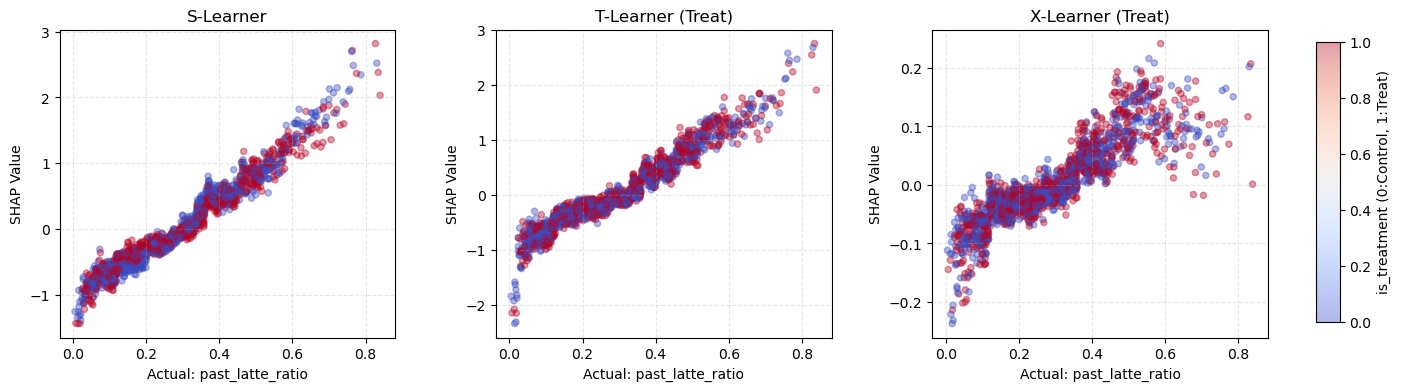

In [31]:
# 特徴量とSHAP値の散布図（Dependence Plot）で確認

# 確認したい特徴量
target_feature = 'past_latte_ratio'

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, m_name in enumerate(['s', 't', 'x']):
    x_val = test_df[target_feature]
    
    # SHAP値の取り出し
    if m_name == 's':
        y_val = shap_df_s[target_feature]
    elif m_name == 't':
        y_val = shap_dfs_t['treat'][target_feature]
    elif m_name == 'x':
        y_val = shap_dfs_x['treat'][target_feature]

    # c=... で処置フラグごとに色分け（赤：処置あり、青：処置なし）    
    scatter = axes[i].scatter(
        x_val, y_val, 
        c=test_df['is_treatment'], 
        cmap='coolwarm', 
        alpha=0.4, 
        s=20
    )

    suffix = "" if m_name == 's' else " (Treat)"
    axes[i].set_title(f'{m_name.upper()}-Learner{suffix}')

    axes[i].set_xlabel(f'Actual: {target_feature}')
    axes[i].set_ylabel('SHAP Value')
    axes[i].grid(True, linestyle='dashed', alpha=0.3)

# 全体のレイアウトを少し左に寄せて、右側にカラーバーのスペースを作る
fig.subplots_adjust(right=0.88, wspace=0.3)
# 凡例: カラーバー専用の軸（場所）を作って配置する
cbar_ax = fig.add_axes([0.91, 0.15, 0.015, 0.7]) # [左, 下, 幅, 高さ]
fig.colorbar(scatter, cax=cbar_ax, label='is_treatment (0:Control, 1:Treat)')

plt.show()
# もしindexがズレていたら、このグラフは「ただの砂嵐」みたいにバラバラになるはず。でも過去ラテ購入率が高いほどSHAP値が上がる（または下がる）といった形が見えていればちゃんと突合できている証拠

# 各指標の比較・整理
|指標|何を表してるか|読み解き|計算の前提|
|---|---|---|---|
|Qini Curve|モデルの予測通りに施策を打った時の「累積の増分」|「モデルの健康診断」。ランダムに送るよりどれだけ効率的か、モデルの精度を評価する。|処置群と対照群のサンプルサイズを補正し、アップリフトスコア順に累積利得をプロットする。|
|Feature Importance (Gain)|モデルが学習中に「予測の誤差をどれだけ減らせたか」の合計点|変数の「選別力」順。 モデルが予測の拠り所にした変数がわかる。|モデル構造に依存。相関が高い変数が複数あるとスコアが分散する特性がある。|
|SHAP|各個体の予測値に対して、各特徴量がどれくらいプラス（またはマイナス）に寄与したか|個体別の「貢献度」順。 値の大小が予測にどう影響したか、個体レベルで可視化できる。|協力ゲーム理論に基づき、全ての変数の組み合わせを考慮して貢献度を公平に分配する。|
|PDP (Partial Dependence)|特定の特徴量を変化させたときの、予測値の平均的な推移|「傾向の可視化」。 変数の値が変化した際、予測対象がどう動くかの平均的な振る舞いを見る。|他の変数は固定し、ターゲット変数だけを仮想的に書き換えて全サンプルの予測値を平均する。|
|Uplift PDP|特徴量の変化による処置効果の変化|「ターゲット層の特定」。 どの値の範囲で「増分」が最大化するか、施策の最適化ルール作成に使う。|各手法（S, T, X）で算出された「処置による差分（リフト）」をプロット。モデルが適切に学習されていることが前提。|  

**どう使い分けるか**  
1. Qini で「モデルの有効性」を判定する: まずはQini曲線が右肩上がりに膨らんでいるか確認。「このモデルを使えばランダムに打つより利益が出る」という確信を持ってから次へ進む。
1. Feature Importance で「主要な特徴量」を特定する: 「来店回数」や「過去の傾向」が効いてるなどとどの変数がモデルにとって重要だったか、全体像をざっくりつかむ。
1. SHAP で「予測の内訳、メカニズム」を解明する: 「過去にクーポンを使った人ほど、今回も買う確率が上がっている」といった（因果関係のような）変数ごとの貢献度の大きさ、分布を確認し、モデルの判断の妥当性をチェックする。
1. PDP / Uplift PDP で「配信ルール」を決める: 「クーポン利用率が0.2以下の人には効果が薄いから送らない」といった、具体的なセグメントや条件（配信閾値）を判断する。

**知っておきたい「前提」の注意点**  
- Qiniの罠（過学習）: 学習データでQiniがよくても、テストデータでガタガタならそれは過学習。必ず未知のデータで評価する。
- 相関の罠: 変数AとBが似ている（例：来店回数と購入金額）と、ImportanceやSHAPではパワーが分散し、本来の重要度より低く見えることがある。
- データの密度（Rug）: PDPで「データがない領域」まで線が引かれていても、そこはモデルの空想（シミュレーション）。足元のラグプロットを見て、実データがある範囲を信じること。過信は禁物。

In [32]:
# まずはモデルの精度評価から

# Qini Curve, AUUC
- 処置による純増を累積でプロット
- AUUC: 正規化されたQini-Curveの下側の面積
  - Qini-Curveは離散的なデータの集まりなので台形公式（Trapezoidal rule）で積分

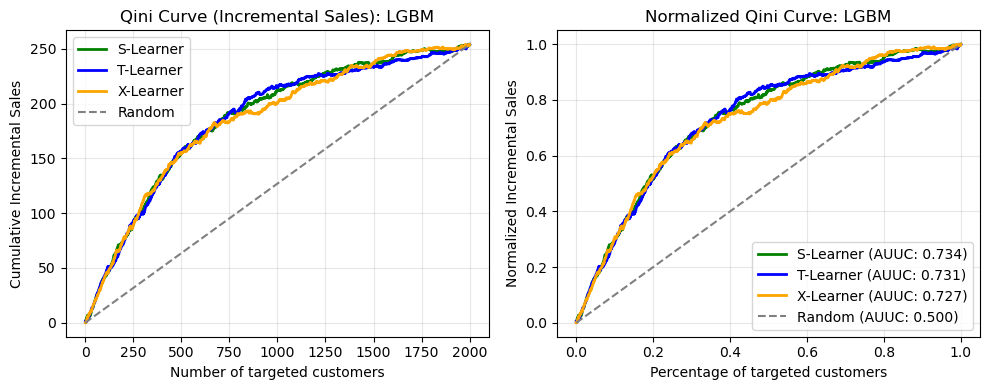

--- Total Incremental Sales if all targeted ---
Expectation: 253.9 customers


In [33]:
# Qini Curveの可視化
# testでの期待値と正規化Qini Curve+AUUC(Area Under the Uplift Curve)を、S,T,X-learner間で比較する

# モデル名のリストと色の設定
model_names = ['s', 't', 'x']
colors = {'s': 'green', 't': 'blue', 'x': 'orange'}

# print("AUUC Results (Normalized)")
# 探索用にデータを保存する辞書を用意
curves_storage = {}

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# --- 左：累積純増数（実数）の比較 ---
for m in model_names:
    res = qini_results_test[m]
    axes[0].plot(res['cum_n'], res['qini'], label=f'{m.upper()}-Learner', color=colors[m], lw=2)
# ランダムライン（どのモデルも終点は同じになるはずなので、sの結果から終点を取得）
final_qini = qini_results_test['s']['qini'].iloc[-1]
axes[0].plot([0, len(test_df)], [0, final_qini], label='Random', color='gray', linestyle='dashed')

axes[0].set_title('Qini Curve (Incremental Sales): LGBM')
axes[0].set_xlabel('Number of targeted customers')
axes[0].set_ylabel('Cumulative Incremental Sales')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- 右：正規化Qini Curve ＋ AUUC算出 ---
for m in model_names:
    res = qini_results_test[m]
    # 横軸：対象人数の割合(0~1) / 縦軸：最大増分に対する割合(0~1)
    norm_x = np.arange(len(res)) / (len(res) - 1)
    norm_y = res['qini'] / res['qini'].max()

    # 後の探索用に保存（xとyをセットで）
    curves_storage[m] = {'x': norm_x, 'y': norm_y}

    # AUUCの計算（台形則を用いて面積を算出）
    if hasattr(np, "trapezoid"):
        auuc_val = np.trapezoid(norm_y, norm_x)
    else:
        auuc_val = np.trapz(norm_y, norm_x)  # numpyのバージョンによってはtrapezoidがない

    # # AUUC画面出力
    # print(f"{m.upper()}-Learner AUUC: {auuc_val:.3f}")
    # 凡例にAUUCの値を追記
    axes[1].plot(norm_x, norm_y, label=f'{m.upper()}-Learner (AUUC: {auuc_val:.3f})', color=colors[m], lw=2)

# ランダムライン（面積は0.5になる）
axes[1].plot([0, 1], [0, 1], label='Random (AUUC: 0.500)', color='gray', linestyle='dashed')

axes[1].set_title('Normalized Qini Curve: LGBM')
axes[1].set_xlabel('Percentage of targeted customers')
axes[1].set_ylabel('Normalized Incremental Sales')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# testデータ全員に処置した場合の期待純増数
print(f"--- Total Incremental Sales if all targeted ---")
print(f"Expectation: {final_qini:.1f} customers")

# 横軸の左側（スコア高い人）: クーポンをあげたら買う確率が高そうで、あげなきゃ買わなそうな人たち（説得可能層 Persuadables）
# 中央、右にいくにつれて、クーポンをあげてもあげなくても買いそうな人たち（鉄板層 Sure Things）や、クーポンあげてもあげなくても買わなそうな人たち（無関心層 Lost Causes）や、クーポンをあげると逆に嫌気がさして買わなくなりそうな人たち（あまのじゃく層 Sleeping Dogs）などが混ざってくるイメージ

# 3モデルともほぼ同じ形状
# 全ユーザー2,000人(test群の人数)のうち、スコア上位500人に配布したら、購入者が150人くらい純増しそう。
# スコア上位750人くらいまでは急角度なのでクーポン配布するほどに純増しやすそう。
# そこからはやや角度が緩やか、純増はやや頭打ち傾向に。それ以上配るとクーポンコストがかさんだり、反応しない人に配ることで効率落ちそう、という期待値をプロットしてるというイメージで見ることができる

In [34]:
# Partial AUUC

# auuc上限のリスト
upper_bounds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0] 

print("Partial AUUC Results (Normalized)")
print(f"{'Upper':<6} | {'S-Learner':<10} | {'T-Learner':<10} | {'X-Learner':<10}")
print("-" * 45)

for ub in upper_bounds:
    results = []
    for m in model_names:
        x = curves_storage[m]['x']
        y = curves_storage[m]['y']
        
        # 指定した上限までのデータを抽出
        mask = x <= ub
        # データが空でないかチェック
        if mask.any():
            if hasattr(np, "trapezoid"):
                p_auuc = np.trapezoid(y[mask], x[mask])
            else:
                p_auuc = np.trapz(y[mask], x[mask])  # numpyのバージョンによってはtrapezoidがない

            results.append(f"{p_auuc:.3f}")
        else:
            results.append("N/A")
            
    # 一行ずつ表示
    print(f"{ub:<6} | {results[0]:<10} | {results[1]:<10} | {results[2]:<10}")

Partial AUUC Results (Normalized)
Upper  | S-Learner  | T-Learner  | X-Learner 
---------------------------------------------
0.1    | 0.016      | 0.015      | 0.015     
0.2    | 0.057      | 0.056      | 0.057     
0.3    | 0.117      | 0.116      | 0.117     
0.4    | 0.189      | 0.189      | 0.188     
0.5    | 0.269      | 0.271      | 0.265     
0.6    | 0.355      | 0.357      | 0.348     
0.7    | 0.445      | 0.447      | 0.437     
0.8    | 0.539      | 0.539      | 0.530     
0.9    | 0.636      | 0.634      | 0.628     
1.0    | 0.734      | 0.731      | 0.727     


## EDA using Qini
- qini_resultsじゃなくてtest_dfで見れるんだが話の流れ的にね

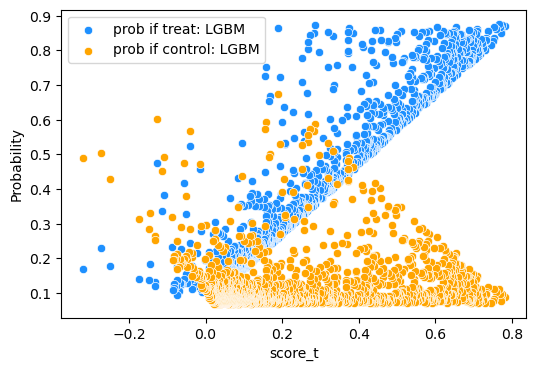

In [35]:
# T-Learnerでのスコアと、処置した場合/しなかった場合の購入確率予測値とを散布図でプロット
plt.figure(figsize=(6, 4))
sns.scatterplot(data=qini_results_test['t'], x="score_t", y="prob_t_t", color='dodgerblue', label='prob if treat: LGBM')
sns.scatterplot(data=qini_results_test['t'], x="score_t", y="prob_c_t", color='orange', label='prob if control: LGBM')
plt.ylabel('Probability')
plt.show()

In [36]:
# スコアが高いほどprob_tとprob_cの差が大きくなっていることがわかる（qini-curveの左右反転）
# 例えばscore0.6以上は説得可能層っぽい。じゃあscore0.6以上の人は何人くらいいるかな。誰と誰かな、など探索するのに使える 

target_score_threshold = 0.6

test_data_all = test_df['score_t'].count()  # qini_results_test['t']['score_t']を参照してもいい以下同文
print(f"Number of test_df customers: {test_data_all}")
target_count = (test_df['score_t'] >= target_score_threshold).sum()
print(f"Number of targeted customers score >= {target_score_threshold}: {target_count}")

target_list = test_df.query('score_t >= @target_score_threshold')
target_list[['store_id', 'customer_id', 'score_t']].sort_values('score_t', ascending=False).round(3).head()

Number of test_df customers: 2000
Number of targeted customers score >= 0.6: 176


,store_id,customer_id,score_t
7377,Store_B,kw6h9962,0.783
8520,Store_D,w33hljgq,0.774
9972,Store_B,297ilueg,0.773
3399,Store_A,aj4emx0a,0.773
7930,Store_D,5hxdquie,0.769


## overfitting check by Qini

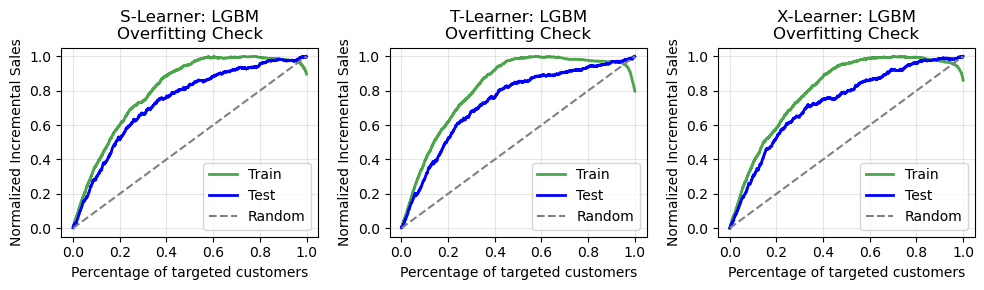

In [37]:
# Qini Curveの可視化
# train,testの正規化Qini Curve（過学習が起きてないかのチェック）

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))

for i, m in enumerate(['s', 't', 'x']):
    # データ取得
    res_train = qini_results_train[m]
    res_test = qini_results_test[m]
    
    # 横軸：0〜1.0 (何%の人にアプローチしたか)
    train_x = np.arange(len(res_train)) / len(res_train)
    test_x = np.arange(len(res_test)) / len(res_test)
    
    # # 縦軸：最大値を1.0に揃える（または1人あたりの増分にする） 
    # 分母をmax()にすることで、そのモデルが「そのデータ内で出した最大成果」に対する進捗を見る
    train_y = res_train['qini'] / res_train['qini'].max()
    test_y = res_test['qini'] / res_test['qini'].max()
    
    axes[i].plot(train_x, train_y, label='Train', color='green', lw=2, alpha=0.7)
    axes[i].plot(test_x, test_y, label='Test', color='blue', lw=2)
    axes[i].plot([0, 1], [0, 1], label='Random', color='gray', linestyle='dashed')
    
    axes[i].set_title(f'{m.upper()}-Learner: LGBM\nOverfitting Check')
    axes[i].set_xlabel('Percentage of targeted customers')
    axes[i].set_ylabel('Normalized Incremental Sales')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3モデルともに、trainにtestが追随してる（形が似てる）ことから、過学習していないことがわかる。
# testの面積（AUCC）がtrainより小さい、あるいはtestの線がガタガタしてrandomを下回るような場合は、過学習してる可能性ある（testの方が性能落ちてる）

## Calibration before/after

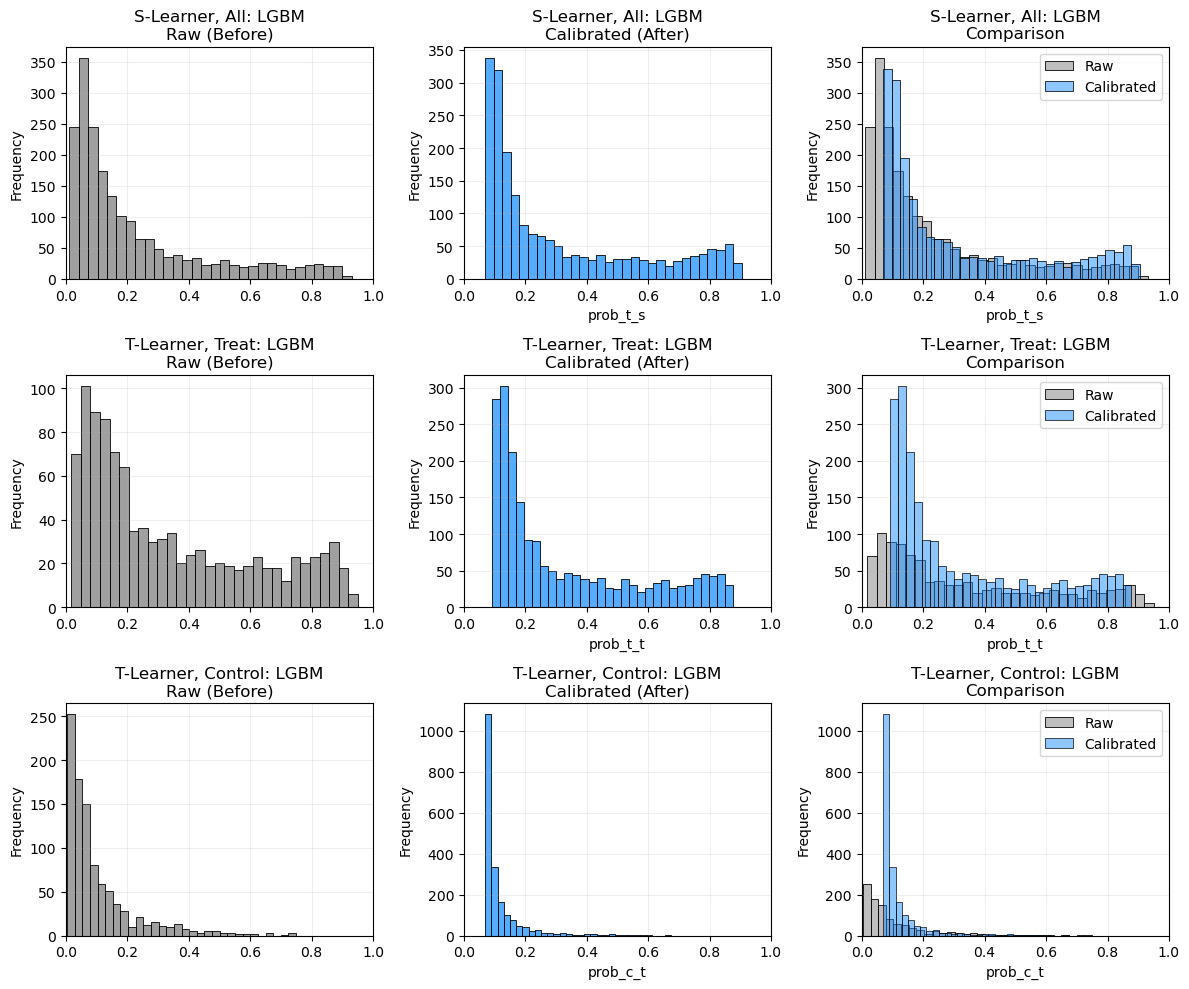

In [38]:
# キャリブレーション前後のスコア分布を比較する

# 比較用のRawモデル（キャリブレーションなし）で別途学習（cvなしの素の状態）してテストデータで予測
raw_models = {}
raw_probs = {}
# S-Learner (Raw)
raw_s = lgb.LGBMClassifier(**params_clf).fit(X_s_train, y_s_train)
raw_probs['s'] = raw_s.predict_proba(X_s_test)[:, 1]
# T-Learner (Raw) - Treatment & Control
raw_t_t = lgb.LGBMClassifier(**params_clf).fit(X_t_train, y_t_train)
raw_t_c = lgb.LGBMClassifier(**params_clf).fit(X_c_train, y_c_train)
raw_probs['t_t'] = raw_t_t.predict_proba(X_t_test)[:, 1]
raw_probs['t_c'] = raw_t_c.predict_proba(X_c_test)[:, 1]

# プロット作成
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 10))

# モデルのラベル定義
targets = [
    ('s', 'S-Learner, All: LGBM', test_df['prob_t_s']), # Sは代表してprob_t_sと比較
    ('t_t', 'T-Learner, Treat: LGBM', test_df['prob_t_t']),
    ('t_c', 'T-Learner, Control: LGBM', test_df['prob_c_t'])
]

for i, (key, label, cal_prob) in enumerate(targets):
    raw_p = raw_probs[key]
    
    # 1. Raw Distribution
    sns.histplot(raw_p, bins=30, color='gray', ax=axes[i, 0])
    axes[i, 0].set_title(f'{label}\nRaw (Before)')
    axes[i, 0].set_xlim(0, 1)
    
    # 2. Calibrated Distribution
    sns.histplot(cal_prob, bins=30, color='dodgerblue', ax=axes[i, 1])
    axes[i, 1].set_title(f'{label}\nCalibrated (After)')
    axes[i, 1].set_xlim(0, 1)
    
    # 3. Comparison
    sns.histplot(raw_p, bins=30, color='gray', alpha=0.5, label='Raw', ax=axes[i, 2])
    sns.histplot(cal_prob, bins=30, color='dodgerblue', alpha=0.5, label='Calibrated', ax=axes[i, 2])
    axes[i, 2].set_title(f'{label}\nComparison')
    axes[i, 2].set_xlim(0, 1)
    axes[i, 2].legend()

for ax in axes.flat:
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# キャリブレーションにより、スコアの分布がより現実的な確率に近づいている
# raw modelは、絶対に買わない（0）やほぼ確実に買う（1）と断定しがちに対し、
# キャリブレーション後は、どんなに条件が良くても/悪くても、100%や0%ということはそうないだろう

## prob_t prob_c
- prob_tとprob_c（tau_tとtau_c）の分布を比較する

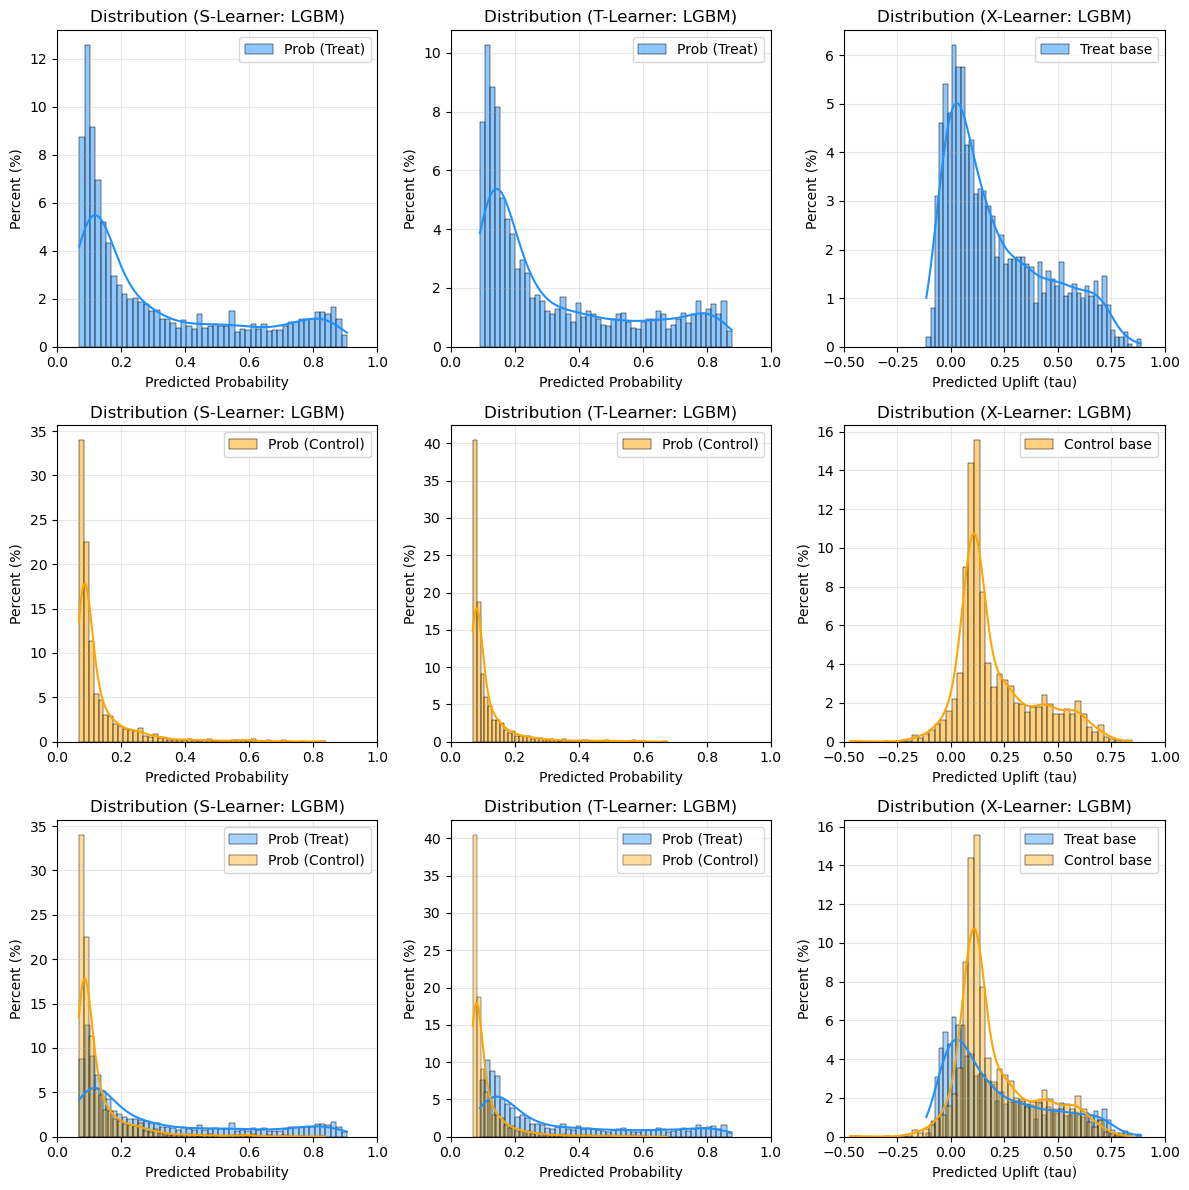

In [39]:
# 各モデルごとにprob_t（tau_t）単体、prob_c（tau_c）単体、重ね合わせ
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))
model_names = ['s', 't', 'x']
model_labels = ['S-Learner', 'T-Learner', 'X-Learner']

for i, m in enumerate(model_names):
    # --- X-Learnerだけカラム名と軸の設定を切り替える ---
    if m == 'x':
        col_t = f'tau_t_{m}'
        col_c = f'tau_c_{m}'
        x_label = 'Predicted Uplift (tau)'
        x_limit = (-0.5, 1.0)  # 増分なので-1.0〜1.0だが、-0.5〜0.5くらいでもいいかも
        label_t = 'Treat base'
        label_c = 'Control base'
    else:
        col_t = f'prob_t_{m}'
        col_c = f'prob_c_{m}'
        x_label = 'Predicted Probability'
        x_limit = (0, 1.0)
        label_t = 'Prob (Treat)'
        label_c = 'Prob (Control)'

    # --- 1行目：Treat単体 (またはTreatベース増分) ---
    sns.histplot(test_df[col_t], bins=50, kde=True, color='dodgerblue', 
                 label=label_t, alpha=0.5, stat="percent", ax=axes[0, i])
    axes[0, i].set_title(f'Distribution ({model_labels[i]}: LGBM)')
    axes[0, i].set_xlim(x_limit)
    axes[0, i].legend()
    
    # --- 2行目：Control単体 (またはControlベース増分) ---
    sns.histplot(test_df[col_c], bins=50, kde=True, color='orange', 
                 label=label_c, alpha=0.5, stat="percent", ax=axes[1, i])
    axes[1, i].set_title(f'Distribution ({model_labels[i]}: LGBM)')
    axes[1, i].set_xlim(x_limit)
    axes[1, i].legend()
    
    # --- 3行目：Comparison (重ね合わせ) ---
    sns.histplot(test_df[col_t], bins=50, kde=True, color='dodgerblue', 
                 label=label_t, alpha=0.4, stat="percent", ax=axes[2, i])
    sns.histplot(test_df[col_c], bins=50, kde=True, color='orange', 
                 label=label_c, alpha=0.4, stat="percent", ax=axes[2, i])
    axes[2, i].set_title(f'Distribution ({model_labels[i]}: LGBM)')
    axes[2, i].set_xlim(x_limit)
    axes[2, i].legend()

    # X軸ラベルは各列の最下段にだけつけるか、共通で設定
    for row in range(3):
        axes[row, i].set_xlabel(x_label)

# 共通の設定（y軸ラベルなど）
for ax in axes.flat:
    ax.set_ylabel('Percent (%)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
# S,Tについて
# Treatment: 0.1付近に山がありつつ、裾野が広く伸びている。クーポンをあげれば、一部の人は購入確率が劇的に上がることを示している。裾野の広さが処置効果の可能性を表していそう。
# Control: 0付近に固まってるのは、クーポンをあげない状態だとほとんどの人の購入確率は極めて低いとモデルが判断している。買わないということにかなり強い確信をモデルが持っている状態と言えそう（確信がなければ0.5付近に山が来る）。
# 重ねたときに左側の重なっている部分: クーポンをあげてもあげなくても確率は低いまま。つまり反応しない（無関心）層。
# 右側の青だけが伸びている部分: アップリフトモデリングのターゲットである、説得できる（Persuadables）層が隠れている場所。

# Xについて
# s,tは0近辺が多すぎるため、右側の伸びてるところでの変化が見えにくい
# treat,controlともに0近辺と0.5以上の部分に山がある。0近辺の山は、クーポンをあげてもあげなくても購入確率の増減がほとんどない人たち（無関心層、鈍感）。0.5以上の山は、クーポンをあげると購入確率が大幅に上がる人たち（説得可能層、反応層）がいることを示唆してるかも。
# X-Learnerは、処置効果の推定値（tau）を直接予測しているので、0.5以上の山が特に重要な意味を持つ。
# treatとcontrolとでは、treatの方が全体的に右側にシフトしている。controlは左側にシフトしている。
# つまり、クーポンをあげると購入確率が上がる人が多いことを示している（振れ幅を大きく見積もってるだけかも）。
# controlのはクーポンをあげないと購入確率の増減がほとんどない人が多いことを示している（控えめな見積もりなのかも）。

# Uplift Score

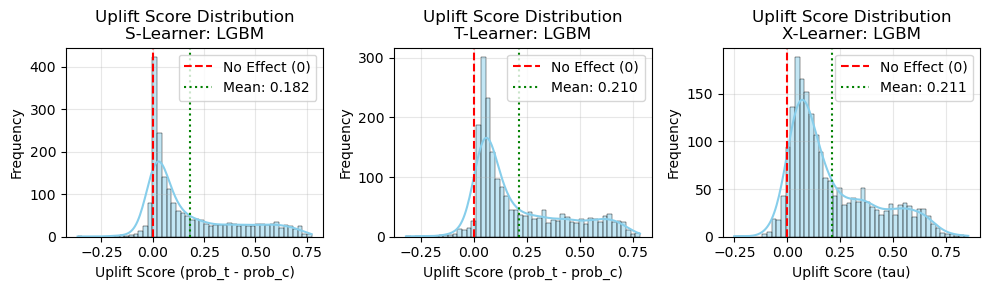

In [41]:
# アップリフトスコアの分布を見てみる
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))

model_names = ['s', 't', 'x']

for i, m in enumerate(model_names):
    # test_df に格納した各モデルのスコア列を指定
    score_col = f'score_{m}'
    
    # ヒストグラムの描画
    sns.histplot(test_df[score_col], bins=50, kde=True, color='skyblue', ax=axes[i])
    
    # 0のライン（効果なし）を赤の破線で引く
    axes[i].axvline(x=0, color='red', linestyle='dashed', label='No Effect (0)')
    
    # 統計情報の表示（平均値など）
    avg_score = test_df[score_col].mean()
    axes[i].axvline(x=avg_score, color='green', linestyle=':', label=f'Mean: {avg_score:.3f}')
    
    axes[i].set_title(f'Uplift Score Distribution\n{m.upper()}-Learner: LGBM')
    axes[i].set_xlabel('Uplift Score (prob_t - prob_c)' if m != 'x' else 'Uplift Score (tau)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## check by quartile

In [42]:
# 1. スコアで5等分にグループ分け（q=5）
test_df['score_s_bin'] = pd.qcut(test_df['score_s'], 5, labels=['Low', 'Mid-Low', 'Mid', 'Mid-High', 'High'])
q_order=['High', 'Mid-High', 'Mid', 'Mid-Low', 'Low']
test_df['score_s_bin'] = pd.Categorical(test_df['score_s_bin'], categories=q_order, ordered=True)

# 2. グループごとに、過去のラテ購入率や会員歴の平均を見てみる
profile_s = test_df.groupby('score_s_bin', observed=True).agg({
    'score_s': 'mean',
    'past_latte_ratio': 'mean',
    'past_coupon_usage_rate': 'mean',
    'visit_frequency': 'mean',
    'membership_years': 'mean',
    'current_temp': 'mean'
}).sort_values('score_s', ascending=False)

# print("--- スコアグループ別の平均値 ---")
profile_s.round(3)

,score_s,past_latte_ratio,past_coupon_usage_rate,visit_frequency,membership_years,current_temp
score_s_bin,,,,,,
High,0.562,0.337,0.502,11.895,2.037,14.126
Mid-High,0.250,0.315,0.328,12.050,2.089,14.028
Mid,0.081,0.258,0.201,11.945,1.941,14.969
Mid-Low,0.025,0.231,0.141,12.285,1.971,15.693
Low,-0.009,0.277,0.062,12.062,2.256,16.185


In [43]:
# 1. スコアで5等分にグループ分け（q=5）
test_df['score_t_bin'] = pd.qcut(test_df['score_t'], 5, labels=['Low', 'Mid-Low', 'Mid', 'Mid-High', 'High'])
q_order=['High', 'Mid-High', 'Mid', 'Mid-Low', 'Low']
test_df['score_t_bin'] = pd.Categorical(test_df['score_t_bin'], categories=q_order, ordered=True)

# 2. グループごとに、過去のラテ購入率や会員歴の平均を見てみる
profile_t = test_df.groupby('score_t_bin', observed=True).agg({
    'score_t': 'mean',
    'past_latte_ratio': 'mean',
    'past_coupon_usage_rate': 'mean',
    'visit_frequency': 'mean',
    'membership_years': 'mean',
    'current_temp': 'mean'
}).sort_values('score_t', ascending=False)

# print("--- スコアグループ別の平均値 ---")
profile_t.round(3)

,score_t,past_latte_ratio,past_coupon_usage_rate,visit_frequency,membership_years,current_temp
score_t_bin,,,,,,
High,0.579,0.345,0.503,11.932,1.986,14.023
Mid-High,0.286,0.313,0.316,11.988,2.051,14.257
Mid,0.114,0.266,0.202,12.052,1.965,14.891
Mid-Low,0.057,0.238,0.143,12.068,1.991,15.681
Low,0.014,0.256,0.070,12.198,2.301,16.150


In [44]:
# 1. スコアで5等分にグループ分け（q=5）
test_df['score_x_bin'] = pd.qcut(test_df['score_x'], 5, labels=['Low', 'Mid-Low', 'Mid', 'Mid-High', 'High'])
q_order=['High', 'Mid-High', 'Mid', 'Mid-Low', 'Low']
test_df['score_x_bin'] = pd.Categorical(test_df['score_x_bin'], categories=q_order, ordered=True)

# 2. グループごとに、過去のラテ購入率や会員歴の平均を見てみる
profile_x = test_df.groupby('score_x_bin', observed=True).agg({
    'score_x': 'mean',
    'past_latte_ratio': 'mean',
    'past_coupon_usage_rate': 'mean',
    'visit_frequency': 'mean',
    'membership_years': 'mean',
    'current_temp': 'mean'
}).sort_values('score_x', ascending=False)

# print("--- スコアグループ別の平均値 ---")
profile_x.round(3)

,score_x,past_latte_ratio,past_coupon_usage_rate,visit_frequency,membership_years,current_temp
score_x_bin,,,,,,
High,0.552,0.329,0.524,11.760,2.028,14.164
Mid-High,0.285,0.305,0.326,12.032,2.122,14.583
Mid,0.137,0.278,0.190,12.042,1.939,14.975
Mid-Low,0.072,0.249,0.133,12.438,1.915,14.945
Low,0.009,0.257,0.063,11.965,2.291,16.334


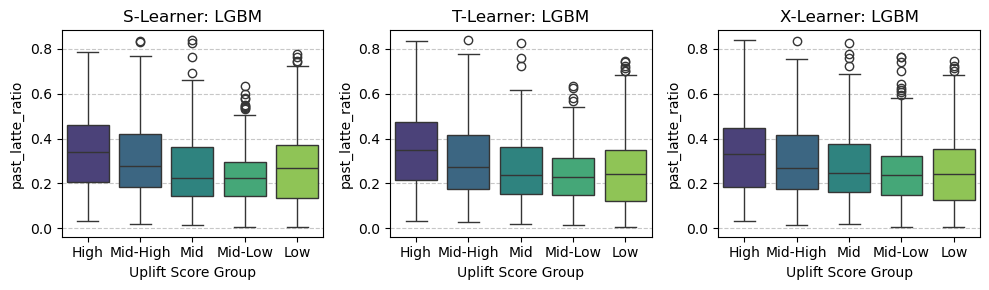

In [45]:
# 3. 可視化（過去のラテ購入率とスコアの関係）
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3)) # 1行3列のグリッドでaxesを作成
# s-learner
sns.boxplot(x='score_s_bin', y='past_latte_ratio', data=test_df, hue='score_s_bin',  # 色分けの基準を指定
            palette='viridis', legend=False, ax=axes[0], 
            dodge=False,  # hueによる横並び（dodging）をオフにすることで、xラベル中央真上に箱ひげを配置
            )
axes[0].set_title('S-Learner: LGBM')
axes[0].set_xlabel('Uplift Score Group')
axes[0].grid(axis='y', linestyle='dashed', alpha=0.7)

# t-learner
sns.boxplot(x='score_t_bin', y='past_latte_ratio', data=test_df, hue='score_t_bin',  # 色分けの基準を指定
            palette='viridis', legend=False, ax=axes[1], 
            dodge=False,  # hueによる横並び（dodging）をオフにすることで、xラベル中央真上に箱ひげを配置
            )
axes[1].set_title('T-Learner: LGBM')
axes[1].set_xlabel('Uplift Score Group')
axes[1].grid(axis='y', linestyle='dashed', alpha=0.7)

# x-learner
sns.boxplot(x='score_x_bin', y='past_latte_ratio', data=test_df, hue='score_x_bin',  # 色分けの基準を指定
            palette='viridis', legend=False, ax=axes[2], 
            dodge=False,  # hueによる横並び（dodging）をオフにすることで、xラベル中央真上に箱ひげを配置
            )
axes[2].set_title('X-Learner: LGBM')
axes[2].set_xlabel('Uplift Score Group')
axes[2].grid(axis='y', linestyle='dashed', alpha=0.7)
plt.tight_layout()
plt.show()
# 過去のラテ購入率は高スコアほど高めではあるが、群間で極端に違うわけでもない

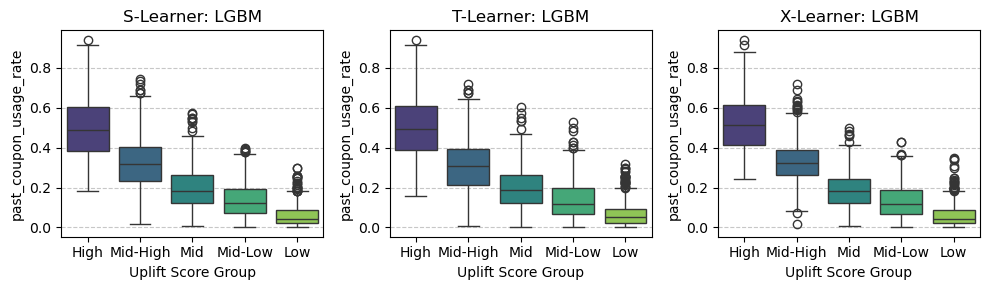

In [46]:
# 3. 可視化（過去のクーポン利用率とスコアの関係）
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3)) # 1行3列のグリッドでaxesを作成
# s-learner
sns.boxplot(x='score_s_bin', y='past_coupon_usage_rate', data=test_df, hue='score_s_bin',  # 色分けの基準を指定
            palette='viridis', legend=False, ax=axes[0], 
            dodge=False,  # hueによる横並び（dodging）をオフにすることで、xラベル中央真上に箱ひげを配置
            )
axes[0].set_title('S-Learner: LGBM')
axes[0].set_xlabel('Uplift Score Group')
axes[0].grid(axis='y', linestyle='dashed', alpha=0.7)

# t-learner
sns.boxplot(x='score_t_bin', y='past_coupon_usage_rate', data=test_df, hue='score_t_bin',  # 色分けの基準を指定
            palette='viridis', legend=False, ax=axes[1], 
            dodge=False,  # hueによる横並び（dodging）をオフにすることで、xラベル中央真上に箱ひげを配置
            )
axes[1].set_title('T-Learner: LGBM')
axes[1].set_xlabel('Uplift Score Group')
axes[1].grid(axis='y', linestyle='dashed', alpha=0.7)

# x-learner
sns.boxplot(x='score_x_bin', y='past_coupon_usage_rate', data=test_df, hue='score_x_bin',  # 色分けの基準を指定
            palette='viridis', legend=False, ax=axes[2], 
            dodge=False,  # hueによる横並び（dodging）をオフにすることで、xラベル中央真上に箱ひげを配置
            )
axes[2].set_title('X-Learner: LGBM')
axes[2].set_xlabel('Uplift Score Group')
axes[2].grid(axis='y', linestyle='dashed', alpha=0.7)
plt.tight_layout()
plt.show()
# 過去のクーポン利用率は高スコアほど高め、群間でもずいぶん違いがある

In [47]:
print(test_df.groupby('score_s_bin')['membership_years'].describe().round(3))
print(test_df.groupby('score_t_bin')['membership_years'].describe().round(3))
print(test_df.groupby('score_x_bin')['membership_years'].describe().round(3))

             count   mean    std  min    25%    50%    75%   max
score_s_bin                                                     
High         400.0  2.037  1.860  0.5  0.608  1.347  2.610  10.0
Mid-High     400.0  2.089  2.025  0.5  0.549  1.393  2.797  10.0
Mid          400.0  1.941  1.938  0.5  0.522  1.160  2.515  10.0
Mid-Low      400.0  1.971  1.795  0.5  0.579  1.440  2.547  10.0
Low          400.0  2.256  1.988  0.5  0.717  1.700  2.936  10.0
             count   mean    std  min    25%    50%    75%   max
score_t_bin                                                     
High         400.0  1.986  1.776  0.5  0.608  1.308  2.580  10.0
Mid-High     400.0  2.051  2.072  0.5  0.500  1.331  2.707  10.0
Mid          400.0  1.965  1.914  0.5  0.509  1.285  2.512  10.0
Mid-Low      400.0  1.991  1.792  0.5  0.646  1.451  2.547  10.0
Low          400.0  2.301  2.038  0.5  0.688  1.745  3.080  10.0
             count   mean    std  min    25%    50%    75%   max
score_x_bin              

In [48]:
print(test_df.groupby('score_s_bin')['visit_frequency'].describe().round(3))
print(test_df.groupby('score_t_bin')['visit_frequency'].describe().round(3))
print(test_df.groupby('score_x_bin')['visit_frequency'].describe().round(3))

             count    mean    std  min    25%   50%   75%   max
score_s_bin                                                    
High         400.0  11.895  3.344  4.0   9.75  12.0  14.0  21.0
Mid-High     400.0  12.050  3.525  2.0  10.00  12.0  14.0  27.0
Mid          400.0  11.945  3.517  3.0   9.75  12.0  14.0  22.0
Mid-Low      400.0  12.285  3.509  4.0  10.00  12.0  14.0  23.0
Low          400.0  12.062  3.481  3.0  10.00  12.0  14.0  23.0
             count    mean    std  min   25%   50%   75%   max
score_t_bin                                                   
High         400.0  11.932  3.278  4.0  10.0  12.0  14.0  21.0
Mid-High     400.0  11.988  3.491  2.0  10.0  12.0  14.0  27.0
Mid          400.0  12.052  3.667  4.0   9.0  12.0  15.0  22.0
Mid-Low      400.0  12.068  3.432  3.0  10.0  12.0  14.0  23.0
Low          400.0  12.198  3.508  3.0  10.0  12.0  15.0  23.0
             count    mean    std  min   25%   50%    75%   max
score_x_bin                                    

In [49]:
print(test_df.groupby('score_s_bin')['score_s'].describe().round(3))
print(test_df.groupby('score_t_bin')['score_t'].describe().round(3))
print(test_df.groupby('score_x_bin')['score_x'].describe().round(3))

             count   mean    std    min    25%    50%    75%    max
score_s_bin                                                        
High         400.0  0.562  0.098  0.395  0.481  0.559  0.642  0.773
Mid-High     400.0  0.250  0.076  0.137  0.182  0.236  0.314  0.394
Mid          400.0  0.081  0.026  0.044  0.059  0.076  0.101  0.137
Mid-Low      400.0  0.025  0.009  0.012  0.018  0.024  0.032  0.044
Low          400.0 -0.009  0.036 -0.366 -0.008  0.003  0.007  0.012
             count   mean    std    min    25%    50%    75%    max
score_t_bin                                                        
High         400.0  0.579  0.093  0.423  0.499  0.581  0.650  0.783
Mid-High     400.0  0.286  0.074  0.168  0.221  0.279  0.342  0.423
Mid          400.0  0.114  0.027  0.076  0.089  0.110  0.135  0.168
Mid-Low      400.0  0.057  0.010  0.040  0.048  0.057  0.066  0.076
Low          400.0  0.014  0.043 -0.322  0.016  0.028  0.034  0.040
             count   mean    std    min    25%  

In [50]:
print(test_df.groupby('score_s_bin')[['prob_t_s', 'prob_c_s']].describe().round(3))

            prob_t_s                                                   \
               count   mean    std    min    25%    50%    75%    max   
score_s_bin                                                             
High           400.0  0.721  0.115  0.474  0.626  0.740  0.820  0.896   
Mid-High       400.0  0.412  0.163  0.216  0.292  0.375  0.468  0.897   
Mid            400.0  0.198  0.094  0.118  0.149  0.172  0.209  0.905   
Mid-Low        400.0  0.117  0.037  0.082  0.099  0.109  0.121  0.483   
Low            400.0  0.110  0.074  0.070  0.081  0.089  0.111  0.846   

            prob_c_s                                                   
               count   mean    std    min    25%    50%    75%    max  
score_s_bin                                                            
High           400.0  0.160  0.081  0.076  0.098  0.130  0.207  0.472  
Mid-High       400.0  0.162  0.139  0.071  0.086  0.102  0.170  0.725  
Mid            400.0  0.116  0.086  0.069  0.080  0.089

In [51]:
print(test_df.groupby('score_t_bin')[['prob_t_t', 'prob_c_t']].describe().round(3))

            prob_t_t                                                   \
               count   mean    std    min    25%    50%    75%    max   
score_t_bin                                                             
High           400.0  0.713  0.103  0.500  0.634  0.727  0.800  0.877   
Mid-High       400.0  0.423  0.136  0.244  0.325  0.400  0.477  0.873   
Mid            400.0  0.218  0.072  0.150  0.176  0.201  0.235  0.751   
Mid-Low        400.0  0.143  0.027  0.111  0.127  0.138  0.151  0.373   
Low            400.0  0.128  0.052  0.092  0.105  0.112  0.127  0.525   

            prob_c_t                                                   
               count   mean    std    min    25%    50%    75%    max  
score_t_bin                                                            
High           400.0  0.134  0.067  0.071  0.085  0.108  0.160  0.417  
Mid-High       400.0  0.137  0.108  0.070  0.080  0.095  0.136  0.674  
Mid            400.0  0.104  0.062  0.069  0.076  0.085

In [52]:
print(test_df.groupby('score_x_bin')[['tau_t_x', 'tau_c_x']].describe().round(3))

            tau_t_x                                                  tau_c_x  \
              count   mean    std    min    25%    50%    75%    max   count   
score_x_bin                                                                    
High          400.0  0.588  0.118  0.266  0.506  0.589  0.679  0.890   400.0   
Mid-High      400.0  0.312  0.100  0.021  0.240  0.308  0.376  0.614   400.0   
Mid           400.0  0.143  0.063 -0.059  0.099  0.139  0.180  0.414   400.0   
Mid-Low       400.0  0.040  0.041 -0.066  0.013  0.038  0.061  0.245   400.0   
Low           400.0 -0.020  0.041 -0.115 -0.049 -0.028  0.003  0.183   400.0   

                                                              
              mean    std    min    25%    50%    75%    max  
score_x_bin                                                   
High         0.516  0.115  0.075  0.442  0.520  0.595  0.847  
Mid-High     0.258  0.088  0.038  0.198  0.256  0.312  0.484  
Mid          0.132  0.052 -0.082  0.111  0.1

## check by model
- S, T, Xは計算の仕組みが違うので、同じデータを見ても「誰を評価するか」がズレることがある
- SとTが一致している場合: この人は誰（どのモデル）が見ても『買いそう』な人だねという安心感につながる
- SとXがズレている場合: 
  - Sは「購入確率」に引っ張られやすいので「処置に関係なく買う人（鉄板）」をHighにしがち
  - Xは「増分」を見るので、「クーポンがある時だけ買う人（説得可能）」をHighにする
  - もしこの2つが大きくズレていたら、「Xの方がより真のアップリフト（純増）を捉えられている」という判断材料になる

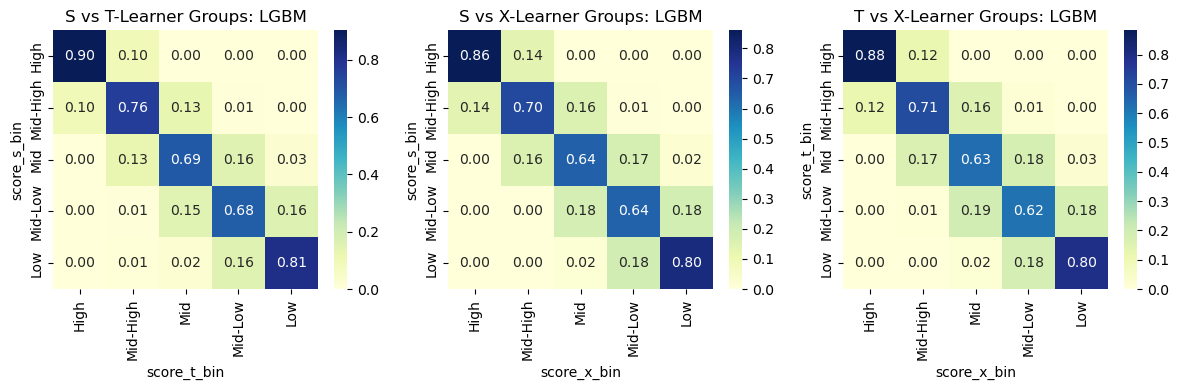

Note: Rows are normalized to sum to 1.0.
注釈: 行の合計が1.0になるよう正規化されています


In [53]:
# learner間でのスコア五分位グループ一致度をヒートマップで可視化
# クロス集計（行ごとに100%になるよう正規化）
cross_tab_st = pd.crosstab(test_df['score_s_bin'], test_df['score_t_bin'], normalize='index')
cross_tab_sx = pd.crosstab(test_df['score_s_bin'], test_df['score_x_bin'], normalize='index')
cross_tab_tx = pd.crosstab(test_df['score_t_bin'], test_df['score_x_bin'], normalize='index')

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4)) # 1行3列のグリッドでaxesを作成
# s vs t-learner
sns.heatmap(cross_tab_st, annot=True, cmap='YlGnBu', fmt='.2f', ax=axes[0])
axes[0].set_title('S vs T-Learner Groups: LGBM')

# s vs x-learner
sns.heatmap(cross_tab_sx, annot=True, cmap='YlGnBu', fmt='.2f', ax=axes[1])
axes[1].set_title('S vs X-Learner Groups: LGBM')

# t vs x-learner
sns.heatmap(cross_tab_tx, annot=True, cmap='YlGnBu', fmt='.2f', ax=axes[2])
axes[2].set_title('T vs X-Learner Groups: LGBM')
plt.tight_layout()
plt.show()

print("Note: Rows are normalized to sum to 1.0.")
print("注釈: 行の合計が1.0になるよう正規化されています")


# 対角線（左上から右下）が高い: どのモデルもだいたい同じ（安定している）。
# 対角線に集中してない、バラけていると（モデルが不確かとも言えるのでどのモデルを採用するかに慎重であったうえで）以下のような解釈、打ち手が考えられる

# 中央表のS-LearnerとX-Learnerの比較が、買う人（S）と動く人（X）のズレが顕著に出やすいかも。
# 右上が高い（SはHighなのにXはLow 購入確率は高いが純増は低い）: Sは『買う』と言ってるけど、Xは『クーポンあげても意味ない（増えない）』と言っている＝ 鉄板客の判別
# 左下が高い（SはLowなのにXはHigh 購入確率は低いけど処置による純増確率は高い）: 普段は買わないけど、クーポンで激変する、説得可能（Persuadables）な隠れたお宝客をXが見つけている

# 例えば、予算が限られているから絶対に無駄打ちしたくない状況なら「SでもXでもHighになった人」だけに絞って送る、という打ち手が、
# 逆に、新しい層を開拓したいなら「Sでは低いけどXだけで高く評価された人」を狙い撃ちする、という打ち手が考えられる

# このデータではいずれも対角線が濃く、3モデルとも同じ人を同じように評価している。どのモデル採用してもターゲットは変わらなさそう
# モデルの仕組み（S, T, X）に依存しないほどに、特徴量とクーポンへの反応との相関が強いことを意味してる

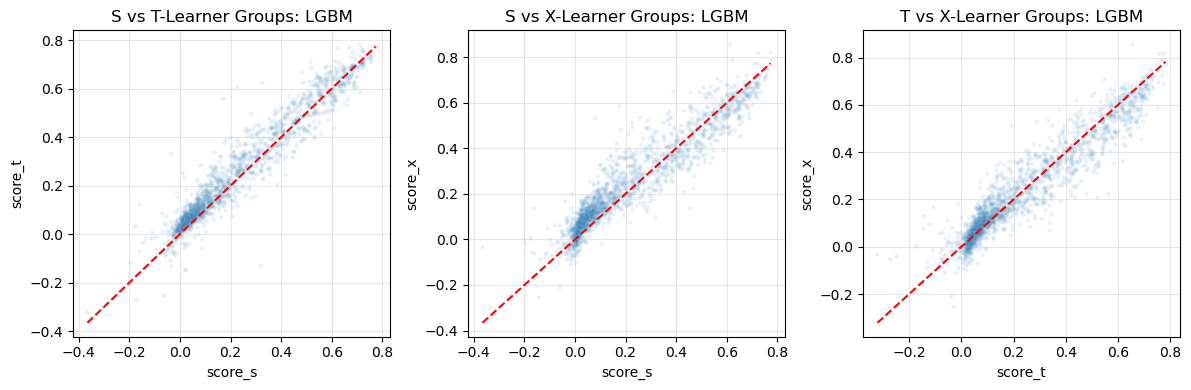

In [54]:
# learner間でのスコアの一致度を散布図で可視化
# 上のヒートマップとは縦横が入れ替わっている

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4)) # 1行3列のグリッドでaxesを作成
# s vs t-learner
sns.scatterplot(data=test_df, x='score_s', y='score_t', alpha=0.1, s=10, ax=axes[0])
# 45度線を引いてズレを確認
axes[0].plot([test_df['score_s'].min(), test_df['score_s'].max()], 
         [test_df['score_s'].min(), test_df['score_s'].max()], 
         color='red', linestyle='dashed')
axes[0].set_title('S vs T-Learner Groups: LGBM')
axes[0].grid(True, alpha=0.3)

# s vs x-learner
sns.scatterplot(data=test_df, x='score_s', y='score_x', alpha=0.1, s=10, ax=axes[1])
# 45度線を引いてズレを確認
axes[1].plot([test_df['score_s'].min(), test_df['score_s'].max()], 
         [test_df['score_s'].min(), test_df['score_s'].max()], 
         color='red', linestyle='dashed')
axes[1].set_title('S vs X-Learner Groups: LGBM')
axes[1].grid(True, alpha=0.3)

# t vs x-learner
sns.scatterplot(data=test_df, x='score_t', y='score_x', alpha=0.1, s=10, ax=axes[2])
# 45度線を引いてズレを確認
axes[2].plot([test_df['score_t'].min(), test_df['score_t'].max()], 
         [test_df['score_t'].min(), test_df['score_t'].max()], 
         color='red', linestyle='dashed')
axes[2].set_title('T vs X-Learner Groups: LGBM')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# スコア五分位グループ一別ではなく個別に見ても、このデータではいずれも対角線が濃く、3モデルとも同じ人を同じように評価している。どのモデル採用してもターゲットは変わらなさそう
# モデルの仕組み（S, T, X）に依存しないほど、特徴量とクーポンへの反応の相関が強いことを意味してる

# Feature Importance
- モデルの予測に、どの特徴量が強く影響するかを把握する
  - 数値が大きいほど、その特徴量が予測の精度を上げるために役立ったことを意味する
  - あくまでモデルの学習効率を示す指標。いかに効率よく分類できたかというモデル側の都合が強い（SHAPとの違い）
  - 特徴量の重要度がドメイン知識に沿っているか確認することで、適切なモデルになっているかのチェックにもなる

- S-Learner
  - 「購入するかどうか」を分けるのに役立った特徴量
  - 処置変数が上位にない場合は使用してるアルゴリズムによっては設定を見直すことで改善することもある
  - 処置変数が上位になきゃダメってことはない（がSHAPでだとモデルとしてちょっとどうだろう）
- T-Learner
  - 「処置したあるいは処置しなかった場合において購入するかどうか」を分けるのに役立った特徴量
  - なのでtreatmentとcontrolで登場する特徴量が違ったり、順位が異なることもある
- X-Learner
  - 「処置効果あるいは潜在的な処置効果の大きさ」を分けるのに役立った特徴量
  - 処置効果: 処置により購入する確率の増分度合い、振れ幅、リフト
  - 潜在的な処置効果: 実際には処置しなかったがもしも処置をしていた場合に購入する確率の増分度合い、振れ幅、リフト

LightGBM,XGBoostの場合  
**特徴量の重要度（Feature Importance：Gain）の定義**  
- モデルが学習中にその特徴量を用いてデータ分割したときに、その分割がどれだけ予測精度を向上させたか（予測誤差の総和: 損失関数をどれだけ減らせたか）を情報の価値、利得として評価している

**直感的なイメージ**   
- モデルは、データを「YESかNOか」で枝分かれさせて、購入確率を絞り込んでいく。例えば「過去にクーポンを使った？」で分けたとき、買った人と買わなかった人がパキッとキレイに分かれたら高い得点。「雨が降ってる？」で分けても、買う確率がそんなに変わらなければ得点低い。

**もう少し技術的に**  
1. 不純度の測定: 分割前のデータがどれだけ混ざり合っているかを測定
1. 最適な分割: 特徴量（例：過去の利用率）を使ってデータを2つに分ける。
1. 情報利得の計算: 分割前と分割後の不純度の差分（情報利得 Information Gain）を計算。
1. 総和の算出: モデル内のすべての木において、その特徴量が使われた全ノード（分岐点）の情報利得を合算。

- 厳密にはLightGBMは勾配情報を活用した効率的な「損失減少量」を、XGBoostは正則化項を含む「構造スコア」の改善幅を計算している。
- LightGBMのgain: 損失の減少を見ているんだが、学習の仕方に工夫がある。
  - 仕組み: 全データを使わず、勾配（誤差）が大きいデータを優先的に使って学習する（GOSS Gradient-based One-Side Sampling）。
  - 特徴: 効率よく学習するために「データのサブセット」で計算された利得を、全体に合うように重み付けして復元している（勾配 Gradientと二階微分 Hessianを使って、どこで分ければ一番得かを高速に計算している）。
- XGBoostのgain: 情報利得そのものではなく、構造スコア Structure Scoreの改善幅を見ている。
  - 仕組み: 分割前のノードのスコアと、分割後の左右のノードのスコアの合計を比較する。
  - 特徴: 正則化項（lambdaやgamma）が計算式に組み込まれてるので、モデルの複雑さを抑えつつどれだけ誤差を減らせたかをダイレクトに評価している。

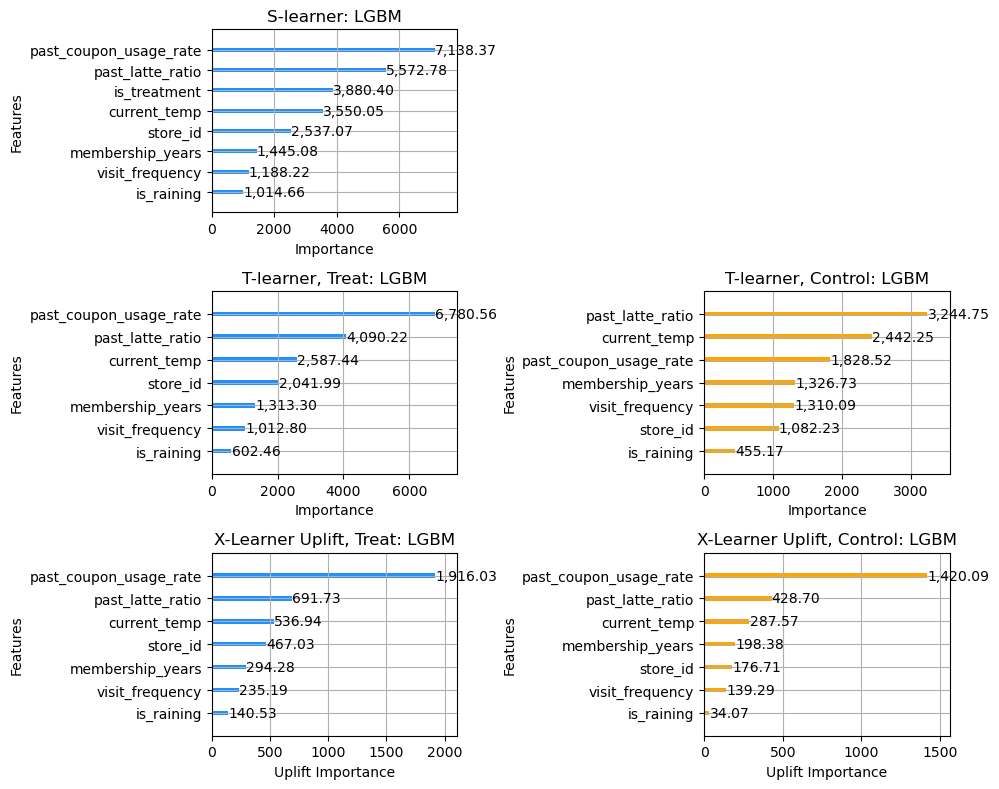

In [55]:
# gainの合計値をそのままプロット

# モデル作成時にcv=3などと設定している場合、内部で3つの異なるモデルを学習して、その平均をとるような構造になっている。
# ので、estimator自体は学習済みの状態として保持されていない。
# というわけでfeature importanceを表示するなら、学習済みの中から1つ取り出す必要がある。

fig, ax = plt.subplots(3, 2, figsize=(10, 8))
# s-learner
lgb.plot_importance(model_s.calibrated_classifiers_[0].estimator,   # 1つめの学習済みモデルにアクセス
                    max_num_features=10, importance_type='gain', ax=ax[0, 0], color='dodgerblue', 
                    title='S-learner: LGBM', xlabel='Importance')
# ax[0, 0]の中にあるテキストオブジェクトをループで回して丸める
for text in ax[0, 0].texts:
    val = float(text.get_text())
    text.set_text(f"{val:,.2f}") # 小数点以下2桁で表示

# 2行3列（計6つ）のうち、2番目（インデックス[0, 1]）のグラフを非表示にする
ax[0, 1].axis('off')


# t-learner, Model_T (クーポンありの世界)
lgb.plot_importance(model_t.calibrated_classifiers_[0].estimator,   # 1つめの学習済みモデルにアクセス
                    max_num_features=10, importance_type='gain', ax=ax[1, 0], color='dodgerblue', 
                    title='T-learner, Treat: LGBM', xlabel='Importance')
# ax[1, 0]の中にあるテキストオブジェクトをループで回して丸める
for text in ax[1, 0].texts:
    val = float(text.get_text())
    text.set_text(f"{val:,.2f}") # 小数点以下2桁で表示

# t-learner, Model_C (クーポンなしの世界)
lgb.plot_importance(model_c.calibrated_classifiers_[0].estimator, 
                    max_num_features=10, importance_type='gain', ax=ax[1, 1], color='orange', 
                    title='T-learner, Control: LGBM', xlabel='Importance')
for text in ax[1, 1].texts:
    val = float(text.get_text())
    text.set_text(f"{val:,.2f}") # 小数点以下2桁で表示


# x-learner, Model_T (クーポンありの世界)treat側のリフト予測
lgb.plot_importance(reg_t, max_num_features=10, importance_type='gain', ax=ax[2, 0], color='dodgerblue', 
                    title='X-Learner Uplift, Treat: LGBM', xlabel='Uplift Importance')
# ax[2, 0]の中にあるテキストオブジェクトをループで回して丸める
for text in ax[2, 0].texts:
    val = float(text.get_text())
    text.set_text(f"{val:,.2f}") # 小数点以下2桁で表示

# x-learner, Model_C (クーポンなしの世界)control側のリフト予測
lgb.plot_importance(reg_c, max_num_features=10, importance_type='gain', ax=ax[2, 1], color='orange', 
                    title='X-Learner Uplift, Control: LGBM', xlabel='Uplift Importance')
# ax[2, 1]の中にあるテキストオブジェクトをループで回して丸める
for text in ax[2, 1].texts:
    val = float(text.get_text())
    text.set_text(f"{val:,.2f}") # 小数点以下2桁で表示

plt.tight_layout()
plt.show()

# plot_importanceは生のスコアをそのままグラフにする（正規化されてない）
# このモデルちゃんと学習できてる？を見たいとき（デバッグ）: 生のGainを見る
# どの変数が支配的なのかモデル間で比較したいとき（分析）: 正規化したグラフを作る

In [56]:
# TreatmentとControlでの値の大きさの違い
# Treatmentの方が数値が大きいのは、そのモデルがどれだけ確信を持って予測できているか の違いでもある。統計学的にはモデルの分離能（Separability）の違いとして説明できる。

# Treatment（左）:  クーポン利用率という超強力なヒントがあるから、モデルが「この変数さえ見れば、買うか買わないか確信を持って言える」と判断して、得点がドカンと積み上がっている状態。言い換えると、処置（クーポン配布）という非常に強いシグナルと相関する特徴量（過去の利用率）が存在するため、各ノードでの情報利得が大きく、モデルが効率的に収束している。

# Control（右）： クーポンがない世界では、これが決め手！という決定打が少なくて、いろんな変数にポイントが分散しちゃっている状態。言い換えると、購入を決定づける要因が分散しており、ノードごとの不純度の減少幅が相対的に小さいため、累積のGainも低くなっていると考えられる。

# 分析結果をまとめるときは、数字そのものよりも 「比率」や「順位」 に注目する。
# 左のモデルでは1位が2位の1.6倍も重要なんだな。右のモデルでは1位と2位の差が左ほどではないかな。
# こんなふうに見ることで「クーポンがある世界では、特定の行動履歴が予測の鍵を握っている」というストーリーがより強固に

## nomalized
- gainの合計値を正規化した値をプロット
- feature importanceを複数モデルの平均値でsns.barplotで描画する

In [57]:
# 正規化した値を取り出して、特徴量を絞り込む

def get_total_importance(calibrated_model):
    """
    calibrated_modelの内部の全モデル（CV分）からimportanceを取得して平均化する関数（S,T-Learnerで使用）
    """
    # 各モデルのimportanceをリストに格納
    total_importance = [
        clf.estimator.feature_importances_ 
        for clf in calibrated_model.calibrated_classifiers_
    ]

    # 複数モデルの平均を計算
    avg_importance = np.mean(total_importance, axis=0)

    # 合計が1になるように正規化する（XGBでは合計が1になるように正規化された値が入っているがLGBMはそうなってない）
    return avg_importance / np.sum(avg_importance)

# 平均importanceを取得
avg_improb_s = get_total_importance(model_s)
avg_improb_t = get_total_importance(model_t)
avg_improb_c = get_total_importance(model_c)


# X-Learnerの回帰モデルは単体なので、artifactsからfeature_importances_で取得
# reg_t: 処置した時の効果の出やすさを学習 reg_c: 処置しなかった時の効果の出やすさを学習
# 合計が1になるように正規化する（XGBでは合計が1になるように正規化された値が入っているがLGBMはそうなってない）
imp_x_t_raw = artifacts['x']['reg_t'].feature_importances_
avg_imp_x_t = imp_x_t_raw / np.sum(imp_x_t_raw)

imp_x_c_raw = artifacts['x']['reg_c'].feature_importances_
avg_imp_x_c = imp_x_c_raw / np.sum(imp_x_c_raw)




# 可視化用のdataframe作成
def create_imp_df(avg_imp, features):
    return pd.DataFrame({'feature': features, 'importance': avg_imp}).sort_values('importance', ascending=False)

# 1. まず全データで作成
df_imp_s_full = create_imp_df(avg_improb_s, features_s)
df_imp_t_t_full = create_imp_df(avg_improb_t, features)
df_imp_t_c_full = create_imp_df(avg_improb_c, features)
df_imp_x_t_full = create_imp_df(avg_imp_x_t, features)
df_imp_x_c_full = create_imp_df(avg_imp_x_c, features)

# 2. ここで絞り込み
# パターンA：上位10件だけ出す
top_n = 10
df_imp_s = df_imp_s_full.head(top_n)
df_imp_t_t = df_imp_t_t_full.head(top_n)
df_imp_t_c = df_imp_t_c_full.head(top_n)
df_imp_x_t = df_imp_x_t_full.head(top_n)
df_imp_x_c = df_imp_x_c_full.head(top_n)

# パターンB：指定の特徴量に絞り込む場合
# target_list = ['past_coupon_usage_rate', 'store_id']
# df_imp_s = df_imp_s_full[df_imp_s_full['feature'].isin(target_list)]
# df_imp_t_t = df_imp_t_t_full[df_imp_t_t_full['feature'].isin(target_list)]
# df_imp_t_c = df_imp_t_c_full[df_imp_t_c_full['feature'].isin(target_list)]
# df_imp_x_t = df_imp_x_t_full[df_imp_x_t_full['feature'].isin(target_list)]
# df_imp_x_c = df_imp_x_c_full[df_imp_x_c_full['feature'].isin(target_list)]

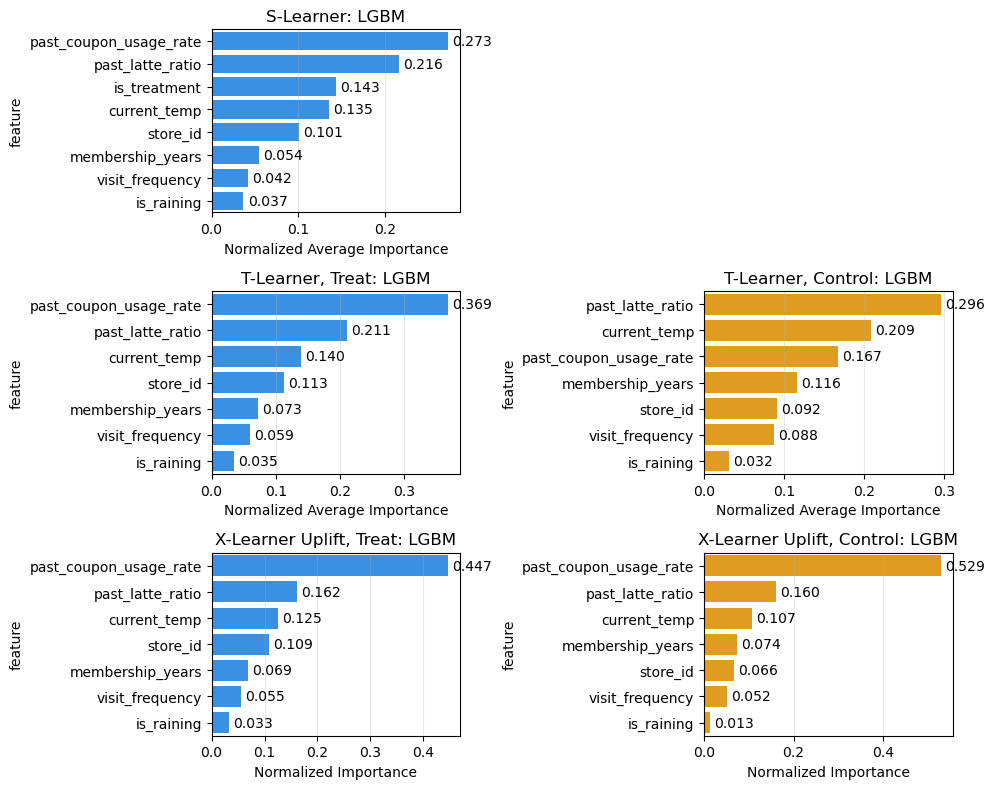

In [58]:
# gainの合計値を正規化した値をプロット
# feature importanceを複数モデルの平均値でsns.barplotで描画する

fig, axes = plt.subplots(3, 2, figsize=(10, 8))
# s-learner
sns.barplot(x='importance', y='feature', data=df_imp_s, ax=axes[0, 0], color='dodgerblue')
axes[0, 0].set_title('S-Learner: LGBM')
axes[0, 0].set_xlabel('Normalized Average Importance')
axes[0, 0].xaxis.grid(True, alpha=0.3)
for i in axes[0, 0].containers:
    axes[0, 0].bar_label(i, padding=3, fmt='{:,.3f}')

# 3行2列（計6つ）のうち、6番目（インデックス[0, 1]）のグラフを非表示にする
axes[0, 1].axis('off')

# t-learner(treat)
sns.barplot(x='importance', y='feature', data=df_imp_t_t, ax=axes[1, 0], color='dodgerblue')
axes[1, 0].set_title('T-Learner, Treat: LGBM')
axes[1, 0].set_xlabel('Normalized Average Importance')
axes[1, 0].xaxis.grid(True, alpha=0.3)
for i in axes[1, 0].containers:
    axes[1, 0].bar_label(i, padding=3, fmt='{:,.3f}')

# t-learner(control)
sns.barplot(x='importance', y='feature', data=df_imp_t_c, ax=axes[1, 1], color='orange')
axes[1, 1].set_title('T-Learner, Control: LGBM')
axes[1, 1].set_xlabel('Normalized Average Importance')
axes[1, 1].xaxis.grid(True, alpha=0.3)
for i in axes[1, 1].containers:
    axes[1, 1].bar_label(i, padding=3, fmt='{:,.3f}')

# x-learner(treat)
sns.barplot(x='importance', y='feature', data=df_imp_x_t, ax=axes[2, 0], color='dodgerblue')
axes[2, 0].set_title('X-Learner Uplift, Treat: LGBM')
axes[2, 0].set_xlabel('Normalized Importance')
axes[2, 0].xaxis.grid(True, alpha=0.3)
for i in axes[2, 0].containers:
    axes[2, 0].bar_label(i, padding=3, fmt='{:,.3f}')

# x-learner(control)
sns.barplot(x='importance', y='feature', data=df_imp_x_c, ax=axes[2, 1], color='orange')
axes[2, 1].set_title('X-Learner Uplift, Control: LGBM')
axes[2, 1].set_xlabel('Normalized Importance')
axes[2, 1].xaxis.grid(True, alpha=0.3)
for i in axes[2, 1].containers:
    axes[2, 1].bar_label(i, padding=3, fmt='{:,.3f}')

plt.tight_layout()
plt.show()

In [59]:
# sについて
# 処置変数（is_treatment）が2位を引き離して1位。とりあえずクーポンを配布すれば他の特徴量はどうあれ購入確率は上がる、というs-learnerらしい予測モデル

# tについて
# Treatment（クーポンあり）の1位：past_coupon_usage_rate 過去のクーポン利用、おトクに敏感かどうかがクーポンをあげた時に購入するかどうかの最大の決め手になっている
# Control（クーポンなし）の1位：past_latte_ratio（過去のラテ率）クーポンがない世界では、ラテがどれだけ好きかが購入を決める一番の要素になっている
# sと違い1位が2位に大差をつけておらず、天気やお店要因も重要とみなしている。tとcで順位が大きく異なる特徴量があればそれはクーポンがある時の動き、ない時の動きのメカニズムを表しているのだろうと捉えやすい

# xについて
# treat,controlともにpast_coupon_usage_rateが1位。処置効果の押し上げ度合いとしては、反実仮想でも過去のクーポン利用が強い。
# 言い換えると、今はクーポンをもらっていない人たちの中でも、もしもらっていたら激変したはずの人（＝過去にクーポンをよく使っていた人）を、X-Learnerは見つけた、不純度を劇的に減らせる（＝効果の強弱を説明できる）と判断した

# SHAP
- モデルの予測の理由を考える、予測の根拠を理解するのに有用
- 各特徴量が予測にどれだけ影響を与えているか（貢献度）を定量化するのが目的
- モデルがそのように予測した理由を説明する必要がある場合や、各特徴量が予測にどのように影響するかを理解したい場合に役立つ
- 機械学習では高い予測性を達成するために複雑なモデルを使用することが一般的に。その結果モデル単体では直感的な解釈がしにくい。そこでSHAPのような方法が求められる
- 並び順は貢献度の絶対値の大きさ順。その特徴量が予測値をどれだけ大きく動かしたか（平均絶対SHAP値）
- Feature Importance（Gain）とSHAP（SHapley Additive exPlanations）とで並び順が入れ替わることがよくある

mean absolute shap valueが表してるのは  
- S-Learner
  - 購入確率の予測値への平均的な影響度
- T-Learner
  - treat: 処置した場合の購入確率の予測値への平均的な影響度
  - control: 処置しなかった場合の購入確率の予測値への平均的な影響度
- X-Learner
  - treat: 処置効果の予測値を増減させる要因への平均的な影響度
  - control: 潜在的な処置効果の予測値を増減させる要因への平均的な影響度
  - 処置効果: 処置により購入する確率の増分度合い、振れ幅、リフト
  - 潜在的な処置効果: 実際には処置しなかったがもしも処置をしていた場合に購入する確率の増分度合い、振れ幅、リフト

In [60]:
# SHAP各種をプロットするための下準備

# 予測値の平均（期待値）を計算、、基準点、ベースラインとして使う
# barとbeeswarmだけであれば、base_values=Noneでいいんだが、waterfallではエラーになるため必要
base_val_s = artifacts['s']['model_s'].predict_proba(test_df[features_s])[:, 1].mean()
base_val_t_t = artifacts['t']['model_t'].predict_proba(test_df[features])[:, 1].mean()
base_val_t_c = artifacts['t']['model_c'].predict_proba(test_df[features])[:, 1].mean()

# X-Learnerでは回帰での予測値の平均をとる
base_val_x_t = artifacts['x']['reg_t'].predict(test_df[features]).mean()
base_val_x_c = artifacts['x']['reg_c'].predict(test_df[features]).mean()

# T,X-Learnerの差分の基準点も計算しておく（treat - control）
base_val_t_diff = base_val_t_t - base_val_t_c
base_val_x_diff = base_val_x_t - base_val_x_c


# 各種情報を含めたExplanationオブジェクトを作成
exp_s = shap.Explanation(values=shap_df_s.values, base_values=base_val_s, data=test_df[features_s].values, feature_names=features_s)
exp_t_t = shap.Explanation(values=shap_dfs_t['treat'].values, base_values=base_val_t_t, data=test_df[features].values, feature_names=features)
exp_t_c = shap.Explanation(values=shap_dfs_t['control'].values, base_values=base_val_t_c, data=test_df[features].values, feature_names=features)
exp_x_t = shap.Explanation(values=shap_dfs_x['treat'].values, base_values=base_val_x_t, data=test_df[features].values, feature_names=features)
exp_x_c = shap.Explanation(values=shap_dfs_x['control'].values, base_values=base_val_x_c, data=test_df[features].values, feature_names=features)

# t,xについては差分のも用意する
# 差分（Upliftへの寄与）を計算しておいて
shap_t_diff_values = shap_dfs_t['treat'].values - shap_dfs_t['control'].values
shap_x_diff_values = shap_dfs_x['treat'].values - shap_dfs_x['control'].values
# Explanationオブジェクトを作成
exp_t_diff = shap.Explanation(values=shap_t_diff_values, base_values=base_val_t_diff, data=test_df[features].values,feature_names=features)
exp_x_diff = shap.Explanation(values=shap_x_diff_values, base_values=base_val_x_diff, data=test_df[features].values,feature_names=features)

## SHAP bar

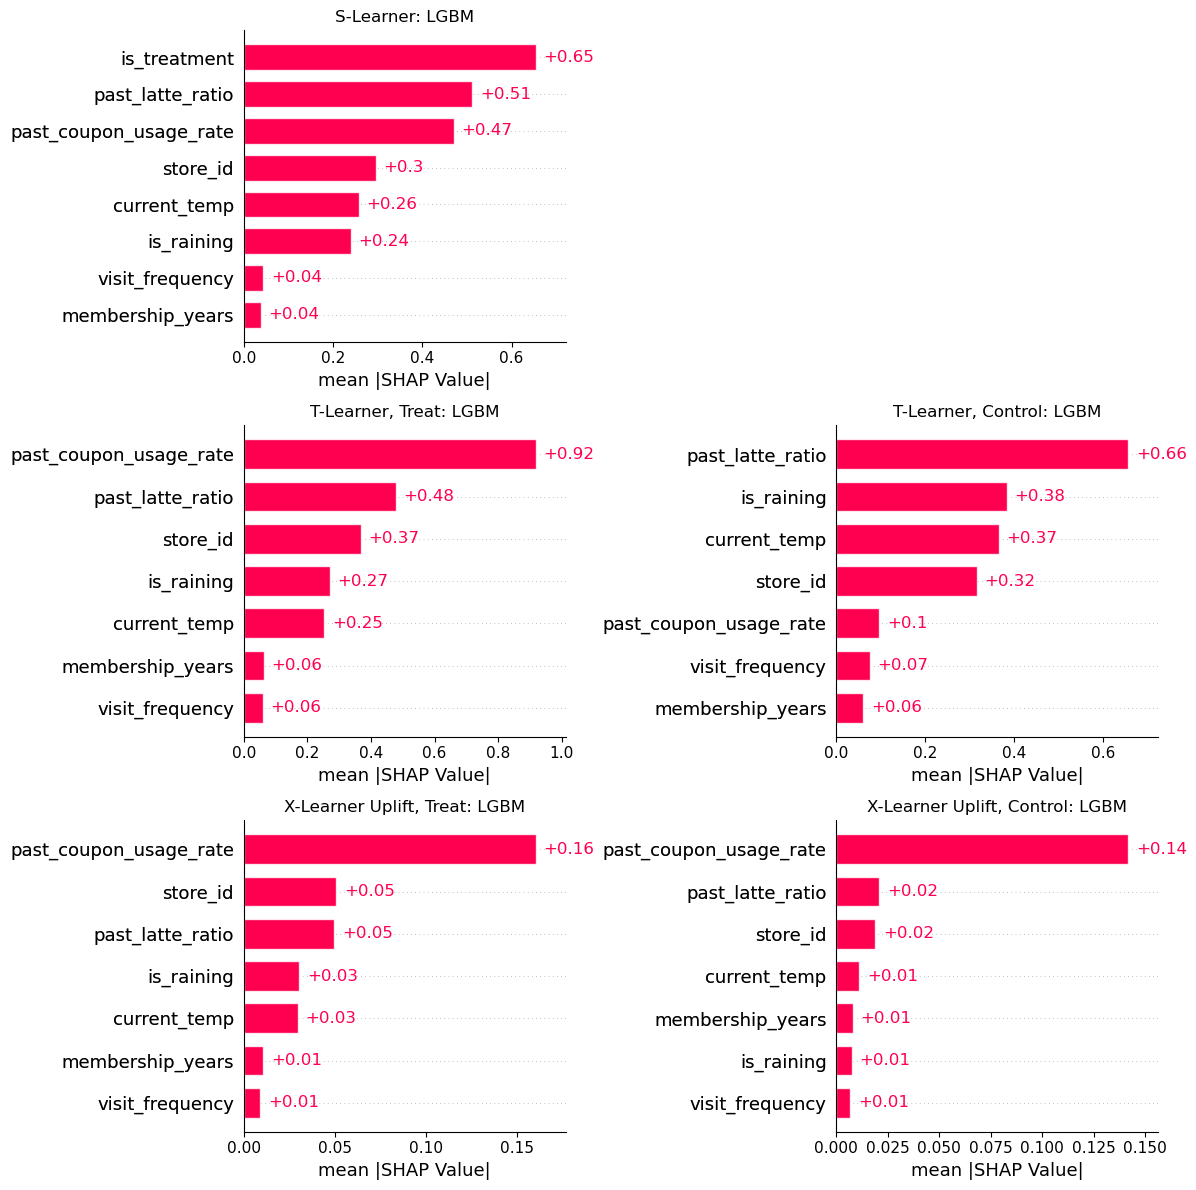

In [61]:
# モデル別にbarをプロット（SHAP値の絶対値の平均 Mean Absolute SHAP Value）
# 予測値への平均的な貢献度を表す（予測値にプラスに効くかマイナスに効くかはこのグラフではわからない）

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
# s-learner
plt.sca(axes[0, 0])
shap.plots.bar(exp_s, show=False, max_display=10)
axes[0, 0].set_title('S-Learner: LGBM')
axes[0, 0].set_xlabel('mean |SHAP Value|')

# 3行2列（計6つ）のうち、6番目（インデックス[0, 1]）のグラフを非表示にする
axes[0, 1].axis('off')

# t-learner(treat)
plt.sca(axes[1, 0])
shap.plots.bar(exp_t_t, show=False, max_display=10)
axes[1, 0].set_title('T-Learner, Treat: LGBM')
axes[1, 0].set_xlabel('mean |SHAP Value|')

# t-learner(control)
plt.sca(axes[1, 1])
shap.plots.bar(exp_t_c, show=False, max_display=10)
axes[1, 1].set_title('T-Learner, Control: LGBM')
axes[1, 1].set_xlabel('mean |SHAP Value|')

# x-learner(treat)
plt.sca(axes[2, 0])
shap.plots.bar(exp_x_t, show=False, max_display=10)
axes[2, 0].set_title('X-Learner Uplift, Treat: LGBM')
axes[2, 0].set_xlabel('mean |SHAP Value|')

# x-learner(control)
plt.sca(axes[2, 1])
shap.plots.bar(exp_x_c, show=False, max_display=10)
axes[2, 1].set_title('X-Learner Uplift, Control: LGBM')
axes[2, 1].set_xlabel('mean |SHAP Value|')

fig.set_size_inches(12, 12)  # 全部の描画が終わった後に、無理やり元のサイズに戻す
plt.tight_layout()
plt.show()

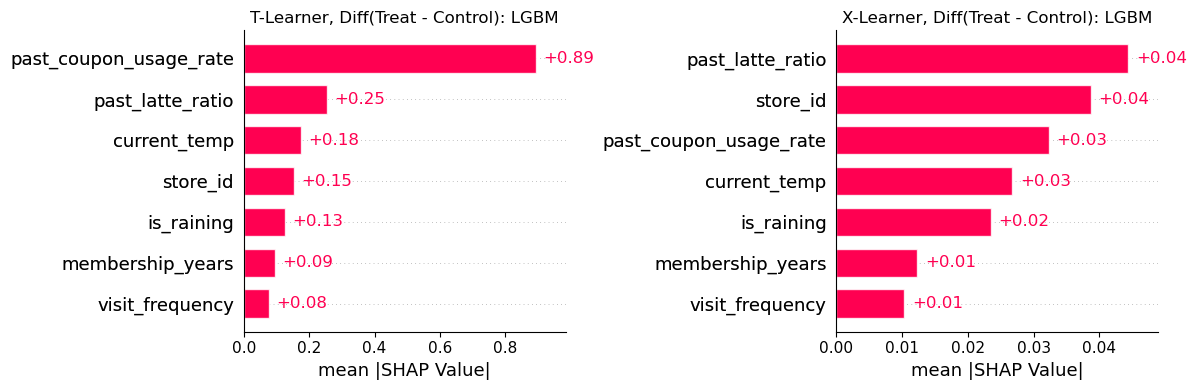

In [62]:
# T,X-Learnerの差分のbarをプロット（SHAP値の絶対値の平均 Mean Absolute SHAP Value）
# 予測値への平均的な貢献度を表す（予測値にプラスに効くかマイナスに効くかはこのグラフではわからない）

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# t-learner diff
plt.sca(axes[0])
shap.plots.bar(exp_t_diff, show=False, max_display=10)
axes[0].set_title('T-Learner, Diff(Treat - Control): LGBM')
axes[0].set_xlabel('mean |SHAP Value|')

# x-learner diff
plt.sca(axes[1])
shap.plots.bar(exp_x_diff, show=False, max_display=10)
axes[1].set_title('X-Learner, Diff(Treat - Control): LGBM')
axes[1].set_xlabel('mean |SHAP Value|')


fig.set_size_inches(12, 4)  # 全部の描画が終わった後に、無理やり元のサイズに戻す

plt.tight_layout()
plt.show()


# tの結果からすると、処置による購入する確率への貢献度は、過去のクーポン利用歴が大きい。
# xの結果からすると、処置効果への貢献度は、クーポン利用歴、ラテ注文歴、どの店かはだいたい同程度

# T-Learner (左側): 「買う確率」では、past_coupon_usage_rate（+0.89）が圧倒的
#「過去にクーポンを使ったことがある人は、今回も（処置に関わらず）買う確率がめちゃくちゃ高い」というベースラインの強さを表している可能性が高い。つまり「もともとの優良顧客」を見つけている状態。

# X-Learner (右側): 「効果（伸びしろ）」上位3つ（ラテ、クーポン、店舗）が+0.04前後で並んでいて、特定の要因が突出していない
# T-Learnerでは圧倒的だった「クーポン歴」のインパクトが、X-Learner（効果の増分）では相対的に小さくなってる。
# これは「クーポン歴がある人は確かに買うけど、クーポンを配布したからといって追加で劇的に伸びるわけではない」つまり鉄板層（鉄板で買う人）であることを示唆してるかも。
# 逆に past_latte_ratio が僅差で1位（+0.04）に浮上しているのは、「ラテをよく飲む人こそ、今回の処置で行動が変わりやすい（説得可能層）」というインサイトが隠れている可能性がある


# T-Learnerで見ると『もともと買う人』の特定には過去のクーポン歴が最強。でも、X-Learnerで『処置によって誰が一番動くか（処置効果）』を見ると、ラテ注文歴や店舗、クーポン歴など、複数の要因が複雑に絡み合っていて、突出した一つの決め手があるわけではない

# 差分のSHAPのバーチャートが意味するもの: アップリフトのkey指標の特定:
# 普通のSHAPバー（T単体など）だと、「元々よく買う人」を見分ける特徴量が上位に来がち。しかし差分SHAPで上位に来る変数は、「クーポンがある時とない時で、行動が一番激変した理由」を指し示してる。

In [63]:
# 平均絶対SHAP値を計算してソートして表示
# 例えばt-learnerのtreatモデルのSHAP値平均を算出（して値だけあれば事足りるとき用）

mean_abs_shap = np.abs(shap_dfs_t['treat'].values).mean(axis=0)
df_shap_importance = pd.DataFrame({
    'feature': features, 
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

print(df_shap_importance.head(10).round(2))

                  feature  mean_abs_shap
3  past_coupon_usage_rate           0.92
2        past_latte_ratio           0.48
6                store_id           0.37
5              is_raining           0.27
4            current_temp           0.25
0        membership_years           0.06
1         visit_frequency           0.06


## SHAP beeswarm

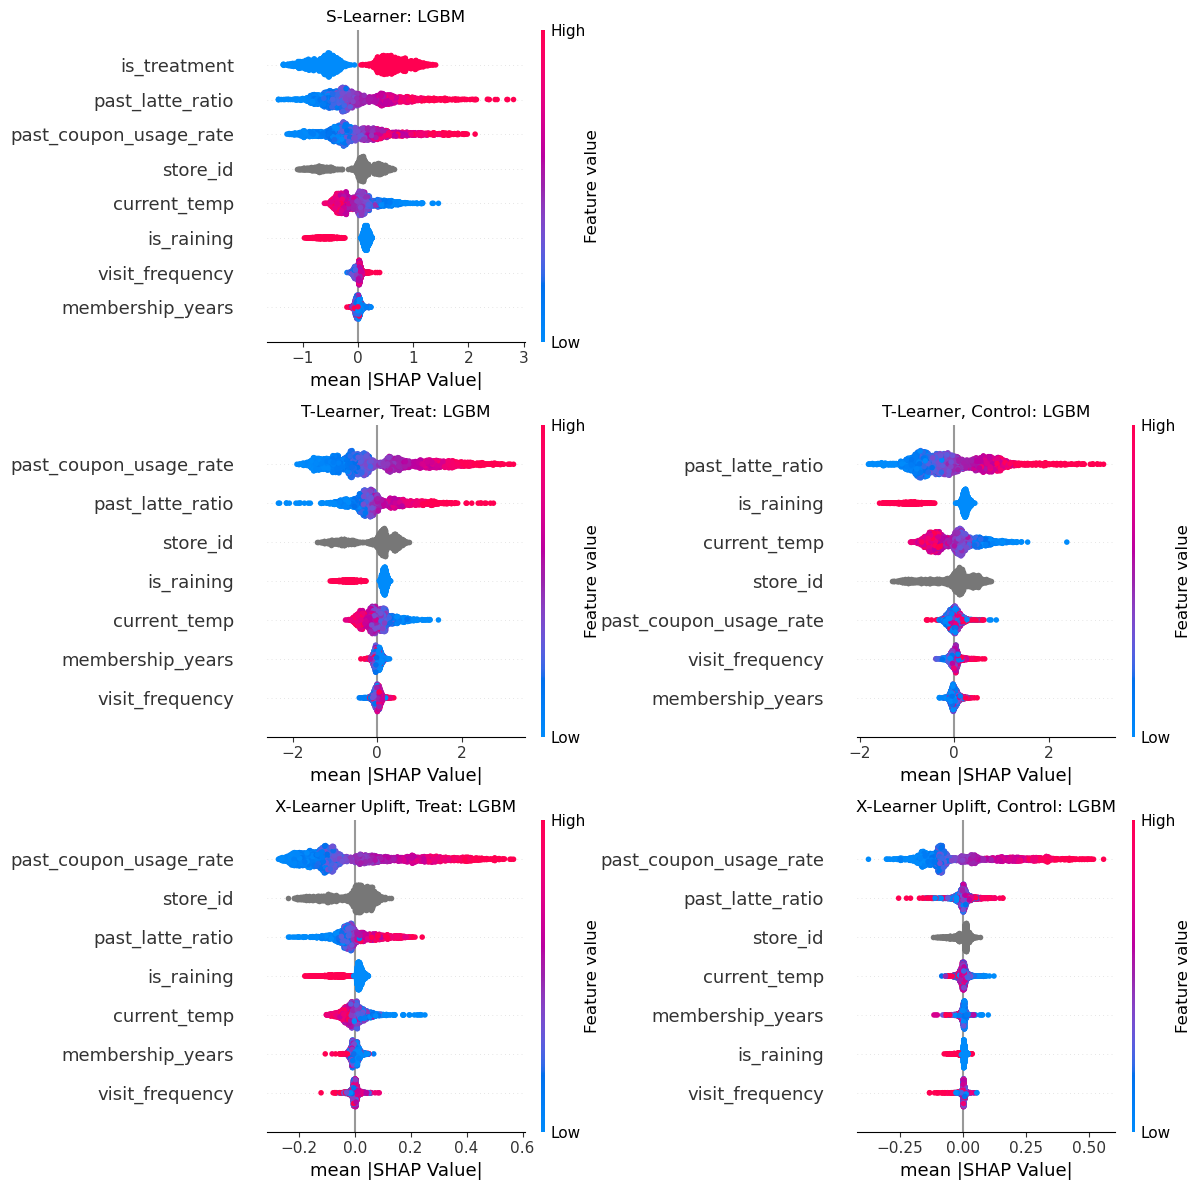

In [64]:
# beeswarmをプロット
# ・予測値への貢献度の方向性: 0より右にあるとプラスに効く（予測値を押し上げる）
# ・貢献度の大きさ: 赤は特徴量の値が高い、青は低い
# ・SHAP値の分布


fig, axes = plt.subplots(3, 2, figsize=(12, 12))
# s-learner
plt.sca(axes[0, 0])
shap.plots.beeswarm(exp_s, show=False, max_display=10)
axes[0, 0].set_title('S-Learner: LGBM')
axes[0, 0].set_xlabel('mean |SHAP Value|')

# 3行2列（計6つ）のうち、6番目（インデックス[0, 1]）のグラフを非表示にする
axes[0, 1].axis('off')

# t-learner(treat)
plt.sca(axes[1, 0])
shap.plots.beeswarm(exp_t_t, show=False, max_display=10)
axes[1, 0].set_title('T-Learner, Treat: LGBM')
axes[1, 0].set_xlabel('mean |SHAP Value|')

# t-learner(control)
plt.sca(axes[1, 1])
shap.plots.beeswarm(exp_t_c, show=False, max_display=10)
axes[1, 1].set_title('T-Learner, Control: LGBM')
axes[1, 1].set_xlabel('mean |SHAP Value|')

# x-learner(treat)
plt.sca(axes[2, 0])
shap.plots.beeswarm(exp_x_t, show=False, max_display=10)
axes[2, 0].set_title('X-Learner Uplift, Treat: LGBM')
axes[2, 0].set_xlabel('mean |SHAP Value|')

# x-learner(control)
plt.sca(axes[2, 1])
shap.plots.beeswarm(exp_x_c, show=False, max_display=10)
axes[2, 1].set_title('X-Learner Uplift, Control: LGBM')
axes[2, 1].set_xlabel('mean |SHAP Value|')

fig.set_size_inches(12, 12)  # 全部の描画が終わった後に、無理やり元のサイズに戻す
plt.tight_layout()
plt.show()

In [65]:
# 各特徴量の貢献度を分解して示している
# ・予測値への貢献度の方向性: 0より右にあるとプラスに効く（予測値を押し上げる）
# ・貢献度の大きさ: 赤は特徴量の値が高い、青は低い

# T-Learnerの場合
# 1. 「過去のクーポン利用率」の違い
# Treatment（左）: past_coupon_usage_rate が1位かつ赤いドット（利用率が高い人）が右側に突き抜けてる。クーポンをあげた世界では、過去にクーポンを使った経験があることが、購入を決定づけるブースターになりそう。
# Control（右）: 下から3番目まで沈んでてドットも中央に固まってる。クーポンない時は過去のクーポン利用歴は購入に関係ないらしい。

# 2. 「過去のラテ購入率（≒ラテ好き）」の違い
# Treatment（左）: クーポンをあげると、下では1位だった影響力が2位に後退。好みよりもおトクへの反応の方が行動のスイッチっぽい。
# Control（右）: 1位past_latte_ratioは赤いドットが右に寄ってる。クーポンがないとそもそもラテ好きかが購入のメイン動機っぽい。

# 3. 「気温（current_temp）」の違い
# 両方のグラフで current_temp の青いドット（気温が低い）が右側（プラス）にある。寒いほどラテが売れるのは共通らしい。

# store_idが上位にある: 購入するかどうかは店によりかなり変わる。地域性や客層といった各店舗の特徴も無視できない要因らしい。

# 以上を踏まえてのアクションは例えば  
# 1. 特徴量エンジニアリング: store_idそのままだと使いにくいから、「その店舗の平均購入率」や「その店舗のクーポンの効果（過去の実績）」といった数値変数に変換（Target Encodingなど）してあげると、モデルの学習効率（Importance）や予測精度が向上する可能性ある。
# 2. 施策の個別化: 予測値の高い店舗を特定し、その店舗客層に合わせた施策を検討するといった、よりきめ細かい戦略が立てられそう。

## SHAP waterfall

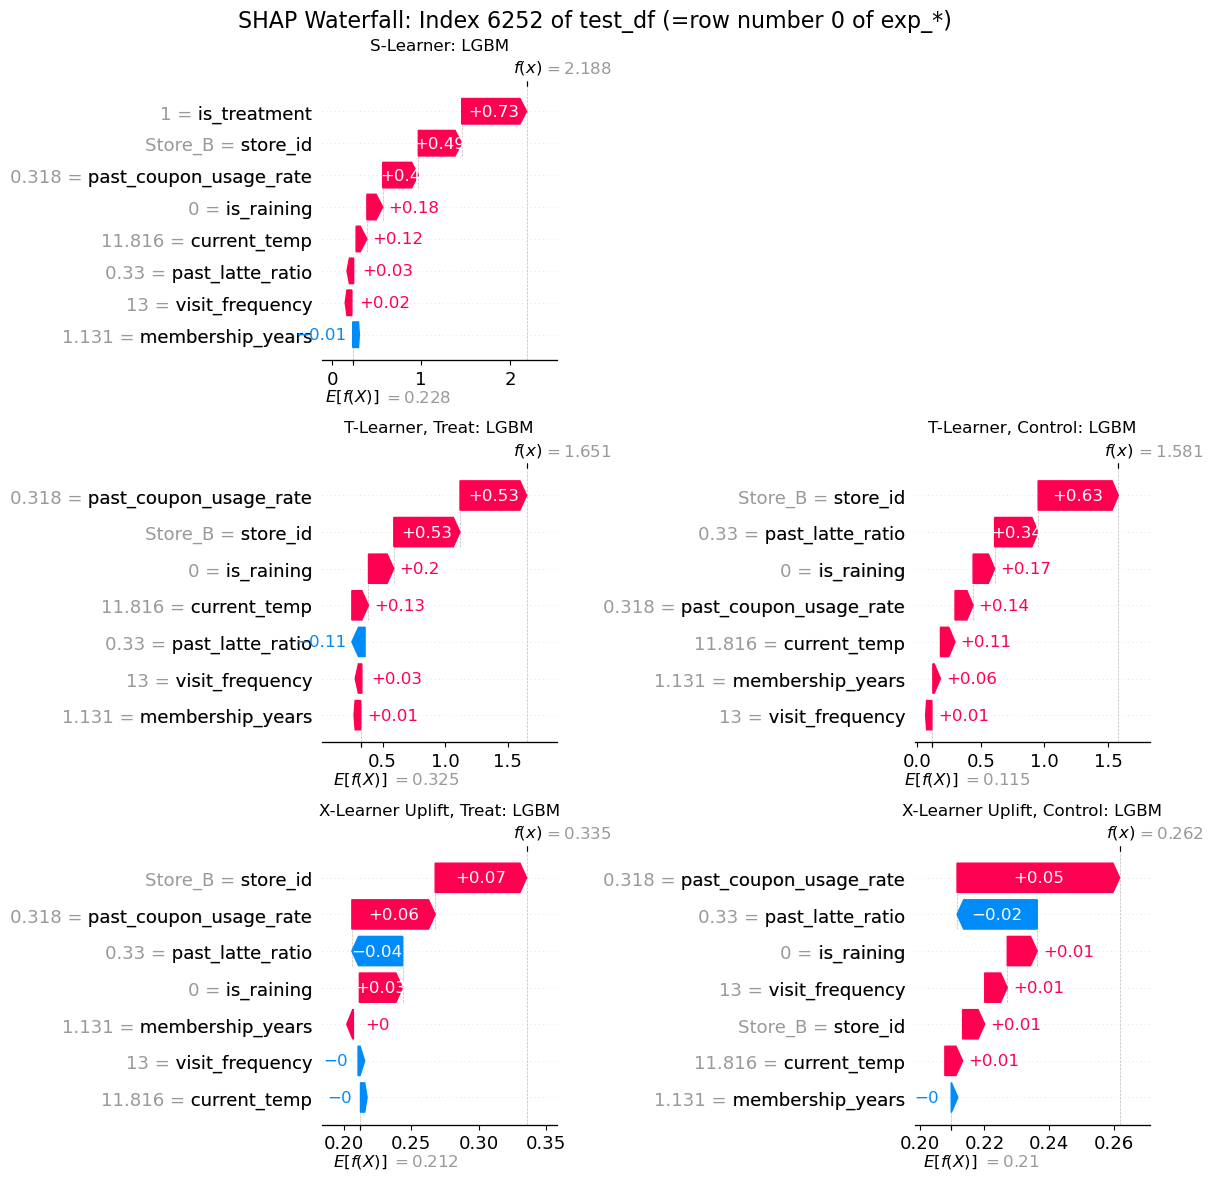

In [66]:
# waterfallをプロット
# ・

# 1. 狙いたいインデックス（顧客IDなど）を指定
target_id = 6252  # これが DataFrame の index だとする
# 2. test_df のインデックスから「行番号（0からの連番）」を取得
target_row_num = test_df.index.get_loc(target_id)


fig, axes = plt.subplots(3, 2, figsize=(16, 12))
# s-learner
plt.sca(axes[0, 0])
shap.plots.waterfall(exp_s[target_row_num], show=False, max_display=10)
axes[0, 0].set_title('S-Learner: LGBM')

# 3行2列（計6つ）のうち、6番目（インデックス[0, 1]）のグラフを非表示にする
axes[0, 1].axis('off')

# t-learner(treat)
plt.sca(axes[1, 0])
shap.plots.waterfall(exp_t_t[target_row_num], show=False, max_display=10)
axes[1, 0].set_title('T-Learner, Treat: LGBM')

# t-learner(control)
plt.sca(axes[1, 1])
shap.plots.waterfall(exp_t_c[target_row_num], show=False, max_display=10)
axes[1, 1].set_title('T-Learner, Control: LGBM')

# x-learner(treat)
plt.sca(axes[2, 0])
shap.plots.waterfall(exp_x_t[target_row_num], show=False, max_display=10)
axes[2, 0].set_title('X-Learner Uplift, Treat: LGBM')

# x-learner(control)
plt.sca(axes[2, 1])
shap.plots.waterfall(exp_x_c[target_row_num], show=False, max_display=10)
axes[2, 1].set_title('X-Learner Uplift, Control: LGBM')


fig.set_size_inches(12, 12)  # 全部の描画が終わった後に、無理やり元のサイズに戻す
fig.suptitle(f'SHAP Waterfall: Index {target_id} of test_df (=row number {target_row_num} of exp_*)', fontsize=16)
plt.tight_layout()
# plt.tight_layout(rect=[0, 0, 1, 0.96]) # タイトルのスペースを空けるための調整
plt.show()

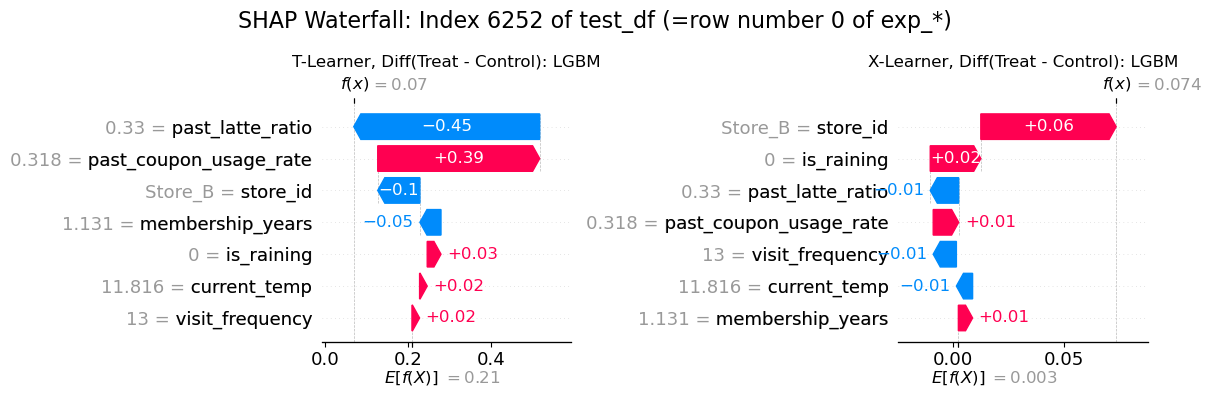

In [67]:
# waterfallをプロット
# ・

# 1. 狙いたいインデックス（顧客IDなど）を指定
target_id = 6252  # これが DataFrame の index だとする
# 2. test_df のインデックスから「行番号（0からの連番）」を取得
target_row_num = test_df.index.get_loc(target_id)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# t-learner diff
plt.sca(axes[0])
shap.plots.waterfall(exp_t_diff[target_row_num], show=False, max_display=10)
axes[0].set_title('T-Learner, Diff(Treat - Control): LGBM')

# x-learner diff
plt.sca(axes[1])
shap.plots.waterfall(exp_x_diff[target_row_num], show=False, max_display=10)
axes[1].set_title('X-Learner, Diff(Treat - Control): LGBM')

fig.set_size_inches(12, 4)  # 全部の描画が終わった後に、無理やり元のサイズに戻す
fig.suptitle(f'SHAP Waterfall: Index {target_id} of test_df (=row number {target_row_num} of exp_*)', fontsize=16)
plt.tight_layout()
# plt.tight_layout(rect=[0, 0, 1, 0.96]) # タイトルのスペースを空けるための調整
plt.show()

Index 6252 は、expデータの 0 行目でした。


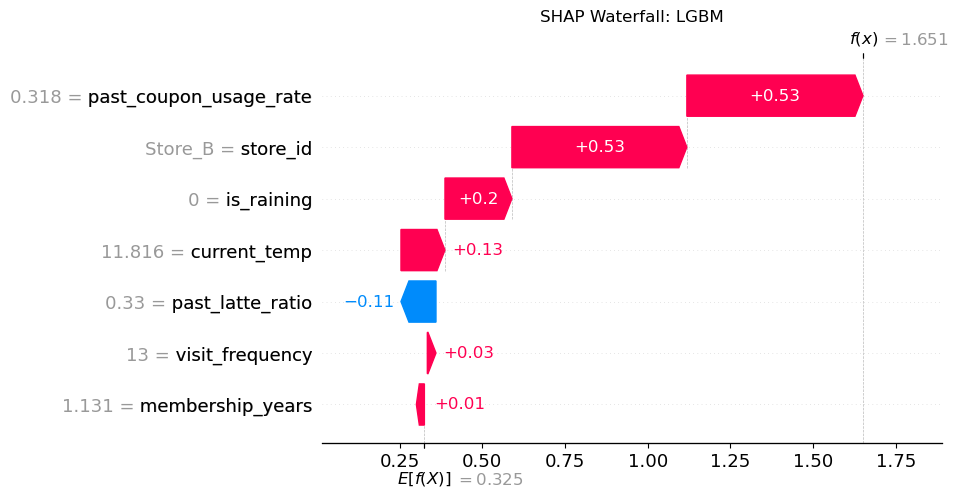

In [68]:
# waterfallを1個だけ大きく見る用

# 1. 狙いたいインデックス（顧客IDなど）を指定
target_id = 6252  # これが DataFrame の index だとする

# 2. test_df のインデックスから「行番号（0からの連番）」を取得
row_num = test_df.index.get_loc(target_id)

print(f"Index {target_id} は、expデータの {row_num} 行目でした。")
# 3. その行番号を使って Explanation をスライス
shap.plots.waterfall(exp_t_t[row_num], show=False, max_display=10)
plt.title(f"SHAP Waterfall: LGBM")
plt.show()

In [69]:
# 1. このwater fallが意味すること（T-Learner: model_t）
# t-learnerのmodel_tの予測に基づいてプロットしてるということは、処置群においてis_purchasedする確率に対する影響度を表現してる
# 「赤が長いほど買う確率を大きく上げ、青が長いほど下げる」と読む

# 目的: 「もしクーポンをあげた場合、この人は買う（is_purchased=1）かどうか」の予測。
# 解釈: E[f(X)]=0.325（平均的な購買確率）からスタートして、この人の個別の事情（赤・青のバー）を足し引きした結果、f(x)=1.22（最終的なスコア）に到達した、という流れ。
# ちょっとした技術的補足
# 最終スコアが 1.22 と 1.0（確率100%）を超えてるのは、分類モデルの「確率」そのものではなく、その手前の「ロジット（Logit）」という値で計算されているため。

# 2. 縦軸のグレーの数値の意味
# Index 6252番さんの実際のデータ（観測値）が表示されてる。
# Store_B = store_id: この人は「店舗B」を利用している。
# 0.318 = past_coupon_usage_rate: 過去のクーポン利用率が約32%。
# 13 = visit_frequency: 来店頻度が13回。
# これらが並んでいるおかげで、「この人は来店頻度が13回とちょい多めだからスコアが+0.03押し上げられたんだな」という風に、「事実」と「影響度（SHAP）」をセットで読み解けるようになってる。
# 3. この人の特徴を読み解くと……
# この 6252番さんは、モデルから見るとかなり「有望（買う確率が高い）」と判断されてる。
# 最大のプラス要因: store_id (Store_B) です。この店舗を利用していることが、購買意欲を強烈に押し上げてる（+0.5）。
# マイナス要因: past_latte_ratio (0.33) ラテを飲む割合が33%程度であることが、この人に関しては少しマイナス（-0.23）に働いてる。

## SHAP scatter
- SHAP値でPartial Dependence Plotのようなグラフを描くこともできる


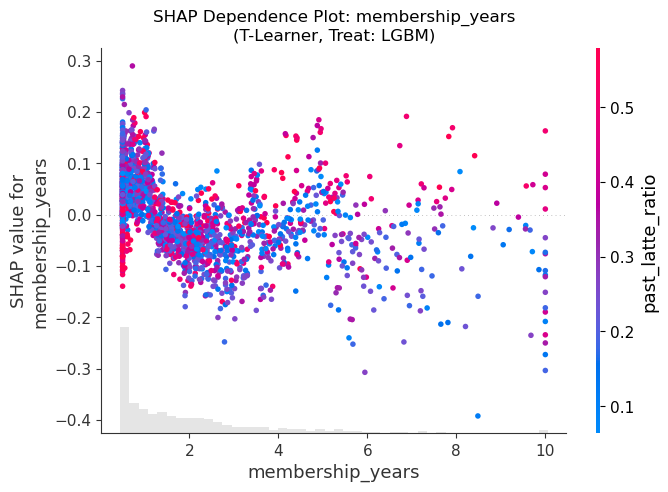

In [70]:
# SHAP Dependence Plot

# 特定の変数（例：membership_years）について、横軸に変数の値、縦軸にSHAP値をプロットする。
# メリット: PDP（Partial Dependence Plot）と似ているが、「個々のデータのバラツキが見える」ので、この値を超えると急にプラスに転じるなといった非線形な動きが見えやすい。
# 自動で「もっとも交互作用（Interaction）が強い別の変数」で色分けしてくれるので、予期せぬ発見がある。

# 例として 'membership_years' を指定
shap_target_feature = 'membership_years'

# Scatterプロットを実行（特定の変数を指定）色分けは自動で決まる
shap.plots.scatter(exp_t_t[:, shap_target_feature], color=exp_t_t, show=False)
plt.title(f'SHAP Dependence Plot: {shap_target_feature}\n(T-Learner, Treat: LGBM)')
plt.show()

# 1. 「入会したて」と「超常連」で効き方が違う
# 初期（0〜1年目）: SHAP値がプラスに振れてる。入会したばかりの人はクーポンがあると購入確率が上がりやすい。新奇性効果的なのかも。
# 中期（2〜3年目）: このあたりでSHAP値が一度マイナス（-0.1以下）に沈んでる。入会してしばらく経ち、少し飽きや慣れが来てのかも。
# 長期（4〜6年目）: そこからまた少し持ち直して、0付近やプラスに戻る層が出てる。長期常連客はまた違った反応を見せているらしい。

# 2. 色分け（past_latte_ratio）との興味深い関係
# 右側のカラーバーを見ると、past_latte_ratio（ラテ率）が相互作用として選ばれてる。
# 1〜2年目の沈んでいる層: 青い点（ラテ率が低い人）が目立ちます。
# 5年前後でプラスに浮上している層: 赤い点（ラテ率が高い人）が混ざってる。
# 解釈: 入会して数年経ち、かつラテをあまり飲まない人は、会員年数が長くなるほどむしろ購入確率（への貢献）が下がってしまうけれど、
# ラテ好きの常連さんになれば、年数が経ってもプラスの反応を維持できる、といった構造なのかも

# 3. PDP（平均）だけでは絶対に見えない「バラツキ」
# この図の一番のポイントは、同じ会員年数でも上下に大きくバラついていること。
# PDPだとこのバラツキが全部平均されて、なんとなく横ばいみたいな線になってるかも。

# PDP
Partial Dependence Plot  
- 特定の特徴量を変化させたときの、予測値の平均的な推移。SHAPをもっと直感的に説明するのに向いてる
- 変数の値が変化した際、予測対象がどう動くかの平均的な振る舞いを見る
- SHAPは点だけどこれは線なので「気温10度以下だとクーポンの効果が上がりやすそう」といった具体的なルールを提案しやすくなる
  - とはいえSHAPとは意味が違う。SHAPは予測値への貢献度の内訳を見てる（他の変数との相関もひっくるめて、実際のデータでの貢献度）
  - PDPは他の変数がどうであれ、その変数を変えたらどうなるかを見てる（他の変数は固定でその変数だけ仮想的に書き換えた予測値の平均）

**アップリフトモデリングにおいてPDPを見る意味**  
- リフトの源泉がどこにあるか見える: Uplift PDP（差分）だけを見ていると、もともと高い層のリフトなのか、低い層からのリフトなのかはわからない。treatment,controlの2本プロットすることで、全体的に底上げされているのか、特定の閾値を超えると急に差が開くのかが可視化される。
- 特徴量と処置の相互作用（Interaction）の確認: もし2本の線がほぼ平行なら、その特徴量はリフトには寄与していない（一律にゲインがあるだけ）。逆に線の間隔が広がったり（=アップリフト発生箇所）、あるいは狭まったりしていれば、「ターゲット選定に使える変数」であるといえそう。
- モデルの妥当性チェック: T-Learnerの2本と、S-Learnerを0/1固定して作った2本を並べてみて、形が似ているか確認する
  - Sだけおかしい場合: もしSの2本がTに比べて極端に平坦なら、モデルの中でis_treatmentフラグが他の強力な特徴量に負けて、リフトを無視しちゃっている可能性がある。
  - Tだけおかしい場合: もしTの線がガタガタだったり、Sと全く違う形をしていたら、処置群か対照群のどちらかのデータ数が少なすぎて、その群の学習がうまく進んでいない（過学習している）サインかもしれない。
  - 特徴量の有効性の裏付け: SとTがほぼ同じ軌跡を描いていれば、「この特徴量と予測値の関係は、手法に依存しなさそう」と言いやすい。

In [71]:
# 各モデルのPDPを取得して、平均値を算出しておく
from sklearn.inspection import partial_dependence

def plot_pdp(model, X_test, feature_name, features=None, color='dodgerblue', label='Model', show_all=False):
    """
    S, T(分類) および X(回帰) に対応したPDP描画関数
    features: S-Learnerの場合に使用する特徴量リスト（'is_treatment'を含むもの）    
    show_all=True のときだけ全期間（0-100%）を強制表示する
    """
    # 1. 表示範囲の設定
    p_range = (0, 1) if show_all else (0.05, 0.95)
    # featuresに 'is_treatment' が含まれていればS-Learnerとして扱う
    is_s_learner = features is not None and 'is_treatment' in features

    # 1. データの準備（分類なら確率予測、回帰なら生の値）
    def get_pdp_values(current_model, data):
        """内部でPDPのy軸（平均予測値）を計算するサブ関数"""
        # CalibratedClassifierCV の場合（S-Learner, T-Learner）
        if hasattr(current_model, 'calibrated_classifiers_'):
            y_all = []
            x_axis = None
            # CalibratedClassifierCV内部の各学習済みモデルに対して計算
            for clf in current_model.calibrated_classifiers_:
                # ここで p_range を適用
                p_res = partial_dependence(clf.estimator, data, [feature_name], 
                                           kind="average", grid_resolution=50, percentiles=p_range)
                y_all.append(p_res['average'][0])
                if x_axis is None:
                    x_axis = p_res.get('grid_values', p_res.get('values'))[0]
            return x_axis, np.mean(y_all, axis=0), 'Predicted Probability'    # 全モデルの結果を平均化
        # 単体モデルの場合（X-Learner の reg_t, reg_c など）
        else:
            p_res = partial_dependence(current_model, data, [feature_name], 
                                       kind="average", grid_resolution=50, percentiles=p_range)
            return p_res.get('grid_values', p_res.get('values'))[0], p_res['average'][0], 'Estimated Value'

    # 2. 描画（S-Learnerなら2本、それ以外なら1本）
    if is_s_learner:
        # S-Learner用：データをコピーしてフラグを固定
        X_temp = X_test[features].copy()
        X_temp['is_treatment'] = 1  # Treatment固定 (1)
        x_axis, y_t, ylabel = get_pdp_values(model, X_temp)
        plt.plot(x_axis, y_t, color='dodgerblue', linestyle='dashed', lw=2.5, label=f'{label} (Treat)')
        
        X_temp['is_treatment'] = 0  # Control固定 (0)
        _, y_c, _ = get_pdp_values(model, X_temp)
        plt.plot(x_axis, y_c, color='orange', linestyle='dashed', lw=2.5, label=f'{label} (Control)')
    else:
        # TやXなどの通常モデル用
        x_axis, y_final, ylabel = get_pdp_values(model, X_test)
        plt.plot(x_axis, y_final, color=color, lw=2.5, label=label)

    # 装飾
    plt.xlabel(feature_name)
    plt.ylabel(ylabel)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(loc='best')

In [72]:
# 特徴量をリストにする

def get_shap_ranked_features(shap_df, exclude_keyword='store_id'):
    """
    SHAPの平均絶対値が高い順に特徴量リストを返す関数
    指定したキーワード（store_idなど）を含む特徴量は除外することもできる。
    """
    # 1. 各特徴量のSHAP絶対値の平均を計算
    # shap_dfは [サンプル数 x 特徴量数] のDataFrame
    shap_importance = shap_df.abs().mean().sort_values(ascending=False)
    
    # 2. 全特徴量のリスト（降順）
    ranked_features = shap_importance.index.tolist()
    
    # 3. 特定のキーワード（store_id）を含まないものに絞り込み
    # filtered_features = [f for f in ranked_features if exclude_keyword not in f]
    
    return ranked_features


# --- S-Learner ---
features_s_ranked_by_shap = get_shap_ranked_features(shap_df_s)
# --- T-Learner (Treatmentを基準にする場合) ---
features_t_ranked_by_shap = get_shap_ranked_features(shap_dfs_t['treat'])
# --- X-Learner (Treatment効果の要因を基準にする場合) ---
features_x_ranked_by_shap = get_shap_ranked_features(shap_dfs_x['treat'])

print(f"S-Learnerの上位特徴量top5: {features_s_ranked_by_shap[:5]}")
print(f"T-Learnerの上位特徴量top5: {features_t_ranked_by_shap[:5]}")
print(f"X-Learnerの上位特徴量top5: {features_x_ranked_by_shap[:5]}")

S-Learnerの上位特徴量top5: ['is_treatment', 'past_latte_ratio', 'past_coupon_usage_rate', 'store_id', 'current_temp']
T-Learnerの上位特徴量top5: ['past_coupon_usage_rate', 'past_latte_ratio', 'store_id', 'is_raining', 'current_temp']
X-Learnerの上位特徴量top5: ['past_coupon_usage_rate', 'store_id', 'past_latte_ratio', 'is_raining', 'current_temp']


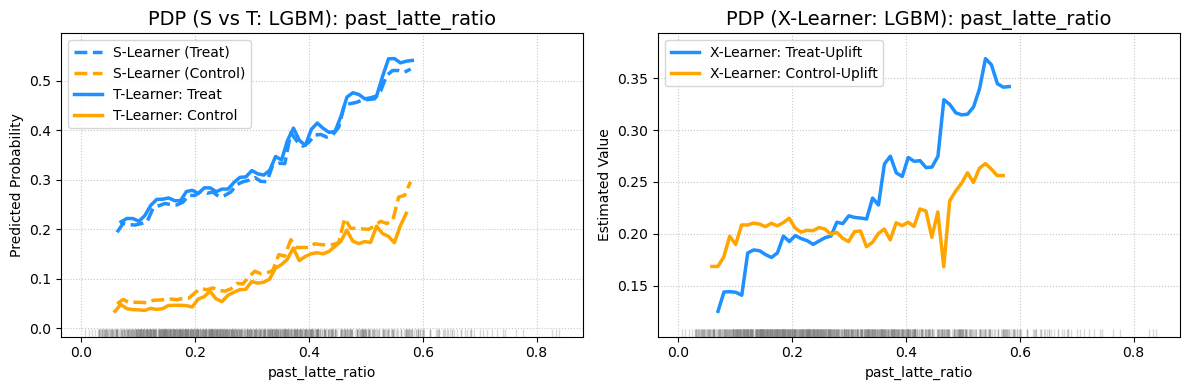

In [73]:
# plot pdp
# 特徴量を単体指定してプロット

# 表示したい特徴量のリスト
# target_features = ['past_coupon_usage_rate']
target_features = ['past_latte_ratio']
# target_features = ['visit_frequency']
# target_features = ['store_id']

n_features = len(target_features)
# 特徴量1つにつき1行（2列）のグラフを作成
fig, axes = plt.subplots(n_features, 2, figsize=(12, 4 * n_features))

# 特徴量が1つだけの場合でも2次元配列として扱えるように調整
if n_features == 1:
    axes = np.expand_dims(axes, axis=0)

for i, f_name in enumerate(target_features):
    # --- 左側: S-Learner & T-Learner (メカニズムの整合性チェック) ---
    ax_left = axes[i, 0]
    plt.sca(ax_left)
    
    # S-Learner (features_sを指定することで自動で2本出る)
    plot_pdp(model_s, X_s_test, f_name, features=features_s, label='S-Learner', show_all=False)
    
    # T-Learner (model_t と model_c を重ねる)
    plot_pdp(model_t, X_t_test, f_name, color='dodgerblue', label='T-Learner: Treat', show_all=False)
    plot_pdp(model_c, X_c_test, f_name, color='orange', label='T-Learner: Control', show_all=False)
    
    sns.rugplot(X_t_test[f_name], color='gray', alpha=0.3, ax=ax_left)
    ax_left.set_title(f'PDP (S vs T: LGBM): {f_name}', fontsize=14)

    # --- 右側: X-Learner (リフトの源泉チェック) ---
    ax_right = axes[i, 1]
    plt.sca(ax_right)
    
    plot_pdp(reg_t, X_t_test, f_name, color='dodgerblue', label='X-Learner: Treat-Uplift', show_all=False)
    plot_pdp(reg_c, X_c_test, f_name, color='orange', label='X-Learner: Control-Uplift', show_all=False)
    
    sns.rugplot(X_t_test[f_name], color='gray', alpha=0.3, ax=ax_right)
    ax_right.set_title(f'PDP (X-Learner: LGBM): {f_name}', fontsize=14)

plt.tight_layout()
plt.show()

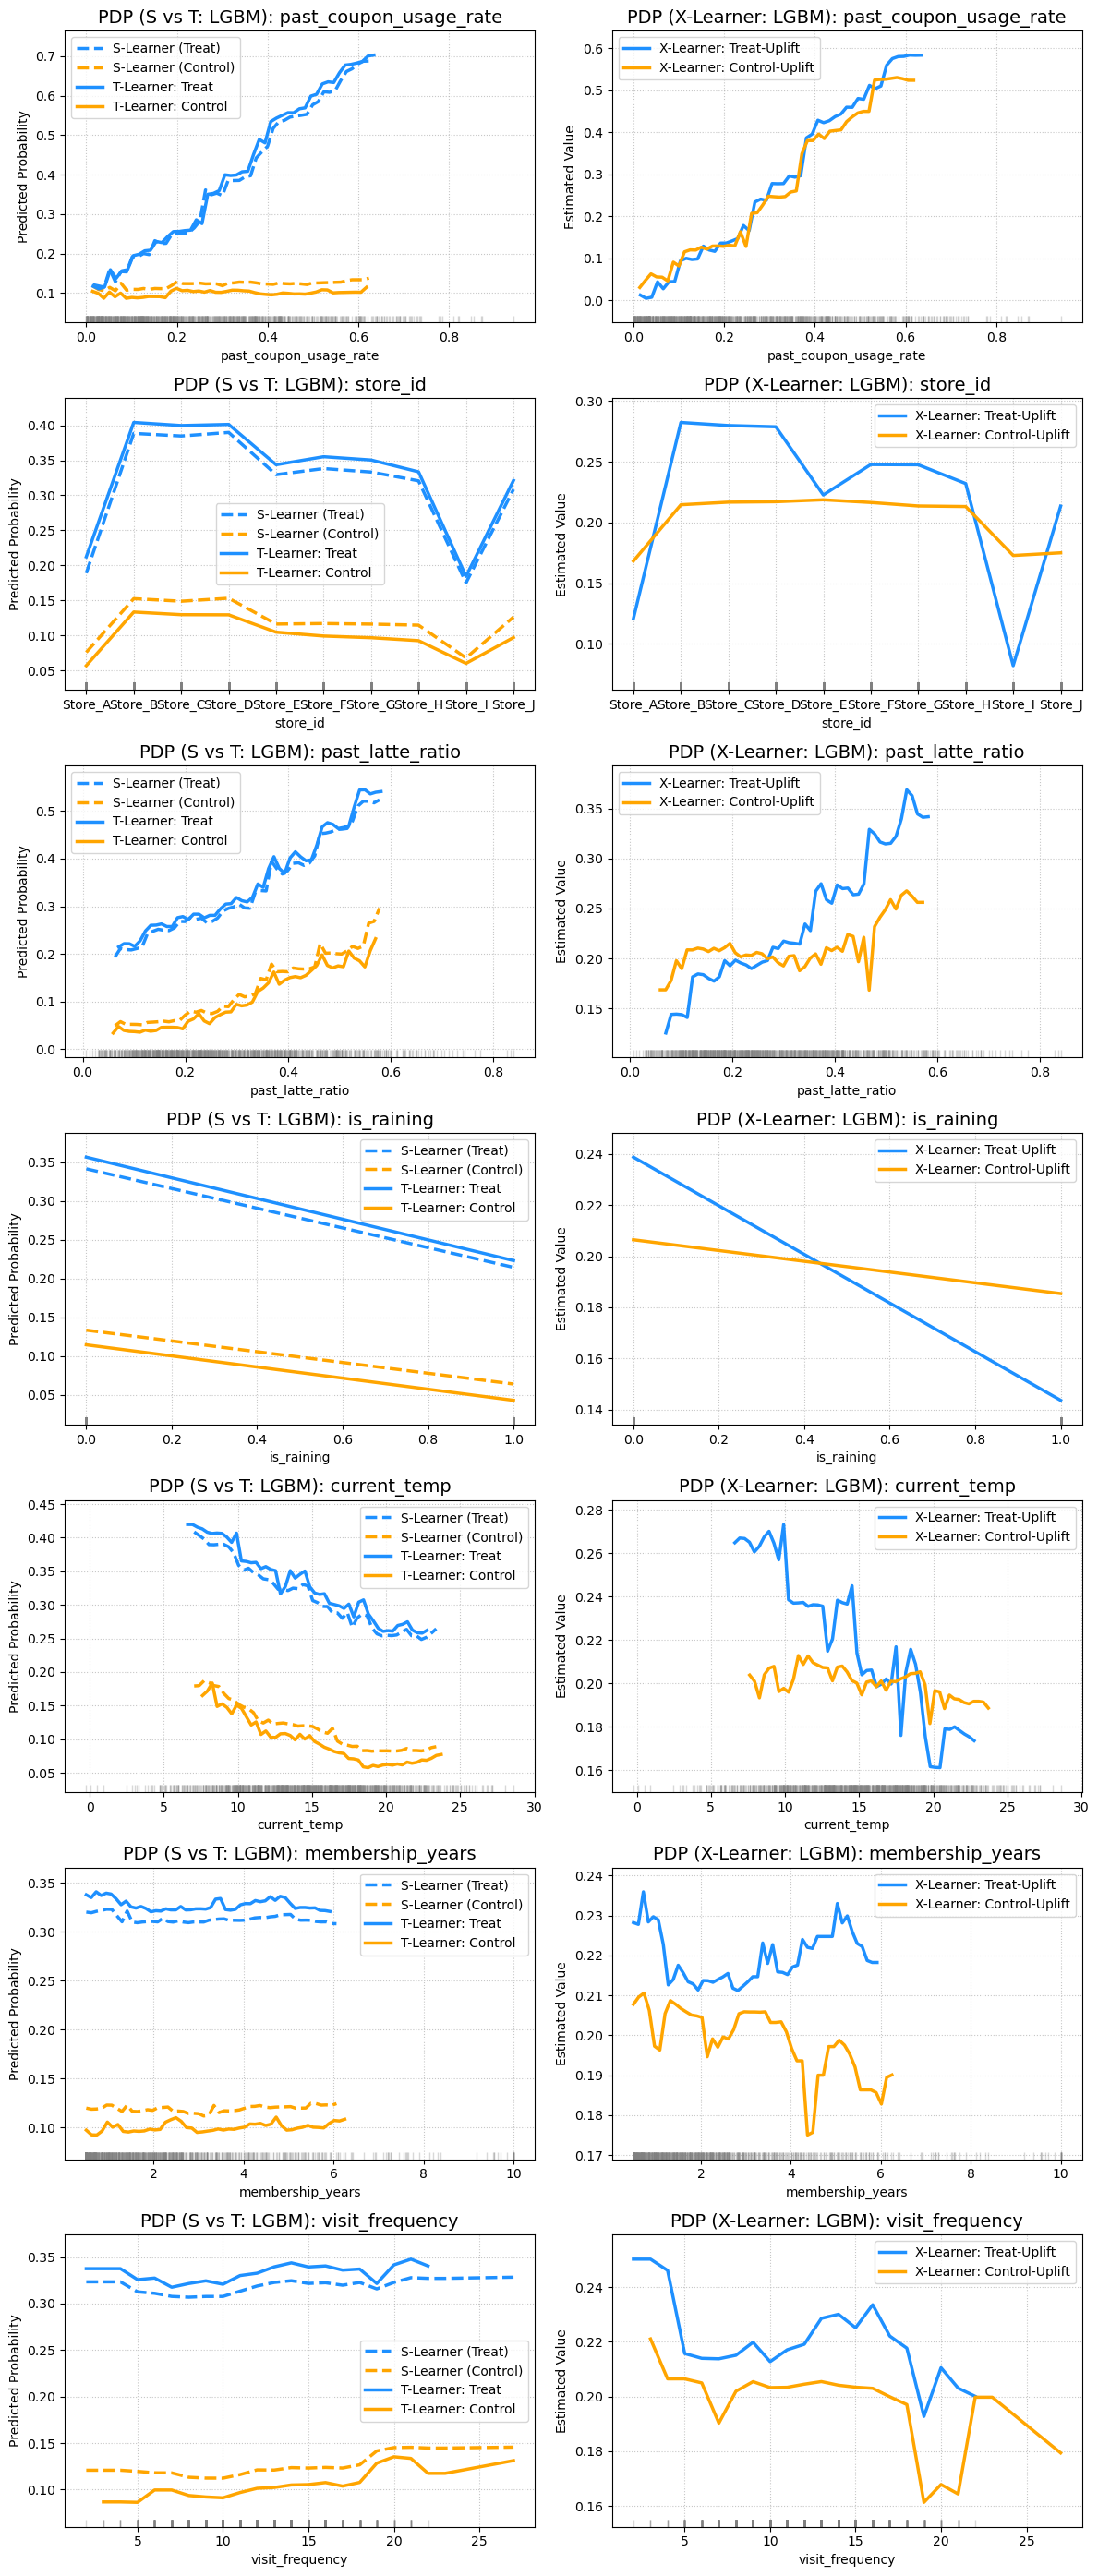

In [74]:
# 特徴量まとめてPDPプロット

# 表示したい特徴量のリスト
target_features = features_x_ranked_by_shap
# target_features = ['past_latte_ratio', 'past_coupon_usage_rate', 'visit_frequency', 'current_temp']

n_features = len(target_features)
# 特徴量1つにつき1行（2列）のグラフを作成
fig, axes = plt.subplots(n_features, 2, figsize=(12, 4 * n_features))

# 特徴量が1つだけの場合でも2次元配列として扱えるように調整
if n_features == 1:
    axes = np.expand_dims(axes, axis=0)

for i, f_name in enumerate(target_features):
    # --- 左側: S-Learner & T-Learner (メカニズムの整合性チェック) ---
    ax_left = axes[i, 0]
    plt.sca(ax_left)
    
    # S-Learner (features_sを指定することで自動で2本出る)
    plot_pdp(model_s, X_s_test, f_name, features=features_s, label='S-Learner', show_all=False)
    
    # T-Learner (model_t と model_c を重ねる)
    plot_pdp(model_t, X_t_test, f_name, color='dodgerblue', label='T-Learner: Treat', show_all=False)
    plot_pdp(model_c, X_c_test, f_name, color='orange', label='T-Learner: Control', show_all=False)
    
    sns.rugplot(X_t_test[f_name], color='gray', alpha=0.3, ax=ax_left)
    ax_left.set_title(f'PDP (S vs T: LGBM): {f_name}', fontsize=14)

    # --- 右側: X-Learner (リフトの源泉チェック) ---
    ax_right = axes[i, 1]
    plt.sca(ax_right)
    
    plot_pdp(reg_t, X_t_test, f_name, color='dodgerblue', label='X-Learner: Treat-Uplift', show_all=False)
    plot_pdp(reg_c, X_c_test, f_name, color='orange', label='X-Learner: Control-Uplift', show_all=False)
    
    sns.rugplot(X_t_test[f_name], color='gray', alpha=0.3, ax=ax_right)
    ax_right.set_title(f'PDP (X-Learner: LGBM): {f_name}', fontsize=14)

plt.tight_layout()
plt.show()

In [75]:
# s,tについて
# ほぼ形が同じ。なので「この特徴量と予測値の関係は、手法に依存しなさそう」と言いやすい。特徴量エンジニアリングがうまくいっている、過学習の心配は薄そうともいえるかな。
# treat,controlの関係性は、past_counpon_usage_rateでは右に行くほどに広がっている。つまり、過去のクーポン利用率が高いと、処置した場合に購入しやすそうなことを表してる

# xについて
# past_coupon_usage_rateを始め、基本的にはtreatとcontrolは似ている。つまり処置効果の押し上げ度合いとしては、反実仮想でも過去のクーポン利用は強い。
# past_latte_ratio: 0.4超えたあたりからtreat青がcontrolオレンジを引き離して上昇してる。クーポンをあげると、ラテ好きな人ほど反応が良くなる（＝リフトが大きくなる）ことの示唆かも。
# is_raining: 雨がマイナスにはたらくのはtreatもcontrolも同じ。晴れだと青が上だが、雨だと青が下がってオレンジが上に。雨の日はクーポンあげても反応が悪くなる。雨がクーポンのリフトをかき消してしまうということかも（current_tempも似た動きしてる）。

# Uplift PDP
- 特徴量の変化による処置効果の変化を見る

In [76]:
def get_uplift_pdp(X, features, feature_name, learner_type, models, grid_resolution=50):
    """
    S, T, X-Learner共通のUplift PDP計算関数（カテゴリ型対策版）
    models: dict形式で必要なモデルを渡す
    """
    is_categorical = X[feature_name].dtype == 'object' or X[feature_name].dtype.name == 'category'
    # カテゴリ型かどうかを判定して、特徴量の範囲を決定する
    if is_categorical:
        # 変換可能なユニーク値をリスト化
        feature_values = sorted(X[feature_name].unique())
    else:
        feature_values = np.linspace(X[feature_name].min(), X[feature_name].max(), grid_resolution)
    
    X_temp = X[features].copy()  # 必要な列だけコピー
    uplift_pd = []

    # ループ処理
    for val in feature_values:
        # 1. 値を代入
        X_temp[feature_name] = val  # 見たい特徴量の値を固定
        
        # 2. 代入直後に、その列をCategory型に強制変換する
        if is_categorical:
            X_temp[feature_name] = X_temp[feature_name].astype('category')
        
        if learner_type == 's':
            # models={'model': model_s}
            X_temp['is_treatment'] = 1
            prob_t = models['model'].predict_proba(X_temp)[:, 1]  # 全員に「処置あり(1)」とした場合の予測
            X_temp['is_treatment'] = 0
            prob_c = models['model'].predict_proba(X_temp)[:, 1]  # 全員に「処置なし(0)」とした場合の予測
            score = prob_t - prob_c
            
        elif learner_type == 't':
            # models={'model_t': model_t, 'model_c': model_c}
            # calibrated_modelそのもののpredict_probaを使う
            # これにより内部の全モデル（CV分）の平均確率が自動で算出される
            prob_t = models['model_t'].predict_proba(X_temp)[:, 1]
            prob_c = models['model_c'].predict_proba(X_temp)[:, 1]
            score = prob_t - prob_c
            
        elif learner_type == 'x':
            # models={'reg_t': reg_t, 'reg_c': reg_c, 'model_g': g}
            # reg_t, reg_c: 第2段階の回帰モデル
            # g: 傾向スコア推定モデル
            tau_t = models['reg_t'].predict(X_temp)  # 処置群ベースと対照群ベースの増分予測
            tau_c = models['reg_c'].predict(X_temp)
            ps = models['model_g'].predict_proba(X_temp)[:, 1]  # 傾向スコアの予測（これはClassifierなのでproba）
            score = (1 - ps) * tau_t + ps * tau_c  # X-Learnerの式でスコアを算出
            
        uplift_pd.append(np.mean(score))  # その差分（Uplift）の平均を格納
        
    return feature_values, uplift_pd

In [77]:
# 特徴量の確認
print(f"S-Learnerの上位特徴量top5: {features_s_ranked_by_shap[:5]}")
print(f"T-Learnerの上位特徴量top5: {features_t_ranked_by_shap[:5]}")
print(f"X-Learnerの上位特徴量top5: {features_x_ranked_by_shap[:5]}")

S-Learnerの上位特徴量top5: ['is_treatment', 'past_latte_ratio', 'past_coupon_usage_rate', 'store_id', 'current_temp']
T-Learnerの上位特徴量top5: ['past_coupon_usage_rate', 'past_latte_ratio', 'store_id', 'is_raining', 'current_temp']
X-Learnerの上位特徴量top5: ['past_coupon_usage_rate', 'store_id', 'past_latte_ratio', 'is_raining', 'current_temp']


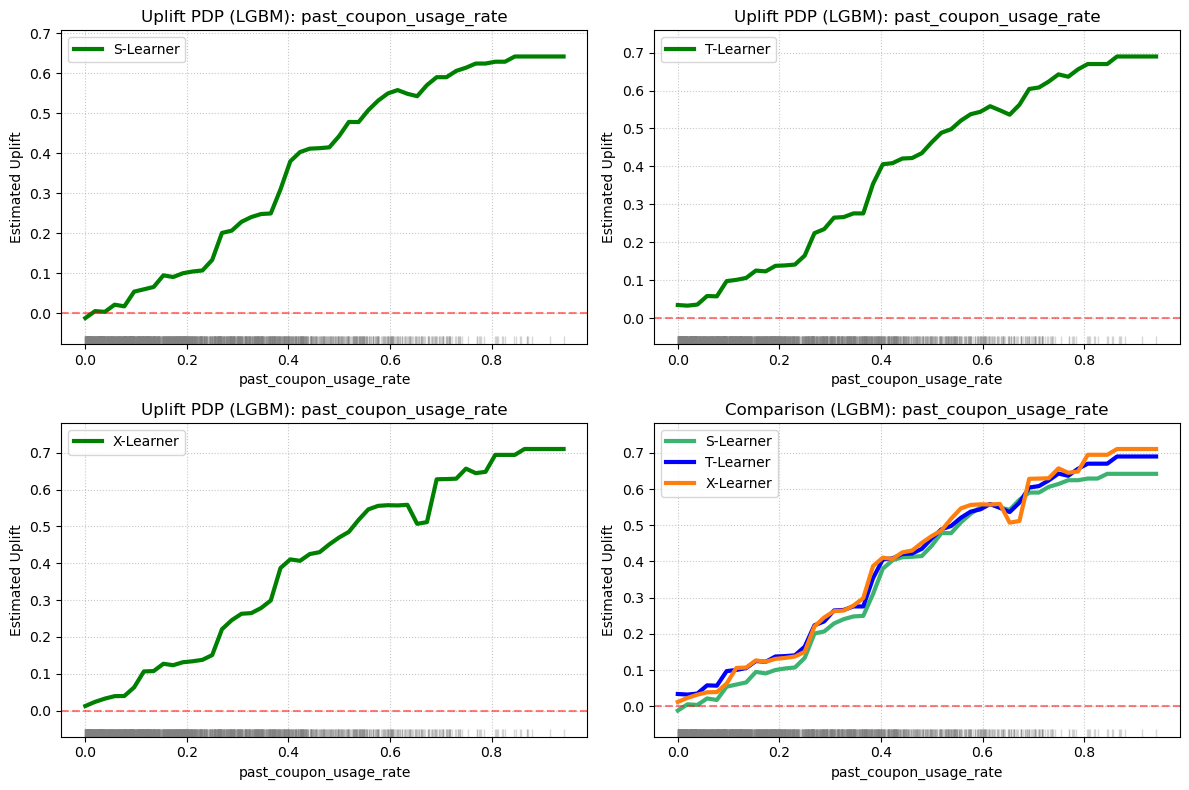

In [78]:
# plot uplift pdp
# 特徴量を単体指定してプロット（S,T,X,comparisonを同時に）
feature_name = 'past_coupon_usage_rate'  # 分析対象に合わせて変更

# 型判定（get_uplift_pdp内のロジックと合わせる）
is_categorical = X_s_test[feature_name].dtype == 'object' or X_s_test[feature_name].dtype.name == 'category'

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes_flat = axes.flatten()

plot_configs = [
    {'type': 's', 'X': X_s_test, 'feats': features_s, 'models': {'model': model_s}, 'title': 'S-Learner'},
    {'type': 't', 'X': X_t_test, 'feats': features,   'models': {'model_t': model_t, 'model_c': model_c}, 'title': 'T-Learner'},
    {'type': 'x', 'X': X_t_test, 'feats': features,   'models': {'reg_t': reg_t, 'reg_c': reg_c, 'model_g': g}, 'title': 'X-Learner'}
]

results = {}

# 2. 個別プロット
for i, config in enumerate(plot_configs):
    ax = axes_flat[i]
    val, pdp = get_uplift_pdp(config['X'], config['feats'], feature_name, config['type'], config['models'])
    results[config['title']] = (val, pdp)
    
    if is_categorical:
        ax.bar(val, pdp, color='green', alpha=0.7, label=config['title'])
        ax.tick_params(axis='x', rotation=45) # カテゴリ名が長い場合の対策
    else:
        ax.plot(val, pdp, color='green', lw=3, label=config['title'])
        
    ax.set_title(f"Uplift PDP (LGBM): {feature_name}")

# 3. 比較プロット
ax_comp = axes_flat[3]
colors = {'S-Learner': 'mediumseagreen', 'T-Learner': 'blue', 'X-Learner': 'tab:orange'}

for label, (val, pdp) in results.items():
    if is_categorical:
        # カテゴリの場合は「線なし・大きなドット」でプロット
        ax_comp.plot(val, pdp, color=colors[label], lw=0, marker='o', markersize=10, label=label, alpha=0.8)
        ax_comp.tick_params(axis='x', rotation=45)
    else:
        ax_comp.plot(val, pdp, color=colors[label], lw=3, label=label)

ax_comp.set_title(f'Comparison (LGBM): {feature_name}')

# 4. 共通装飾
for i, ax in enumerate(axes_flat):
    ax.axhline(0, color='red', linestyle='dashed', alpha=0.5)  # 0のライン（効果なしの境界）
    # rugplotは数値型の時だけ表示（カテゴリ型だとエラーになることがあるため）
    if not is_categorical:
        sns.rugplot(X_s_test[feature_name], color='gray', alpha=0.3, ax=ax)  # データの集中度合いを表示
    
    ax.set_xlabel(feature_name)
    ax.set_ylabel('Estimated Uplift')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

## Uplift PDP (almost) all
- 特徴量をリスト指定してまとめてプロット

In [79]:
def plot_all_uplift_comparisons(feature_names, X_s_test, X_t_test, learner_configs, grid_resolution=50):
    """
    指定された全特徴量を2列構成で比較プロットする。
    奇数の場合は最後の余白を削除する。
    """
    n_features = len(feature_names)
    n_cols = 2
    n_rows = (n_features + n_cols - 1) // n_cols  # 切り上げ計算で必要な行数を出す
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes_flat = axes.flatten() if n_features > 1 else [axes]
    
    colors = {'S-Learner': 'mediumseagreen', 'T-Learner': 'blue', 'X-Learner': 'tab:orange'}

    for i, f_name in enumerate(feature_names):
        ax = axes_flat[i]
        
        # --- 1. 計算 (既存の get_uplift_pdp を使用) ---
        results = {}
        for l_type, config in learner_configs.items():
            val, pdp = get_uplift_pdp(
                config['X'], config['feats'], f_name, l_type, config['models'], grid_resolution
            )
            label = f"{l_type.upper()}-Learner"
            results[label] = (val, pdp)

        # --- 2. 描画判定 ---
        is_categorical = X_s_test[f_name].dtype == 'object' or X_s_test[f_name].dtype.name == 'category'
        
        for label, (val, pdp) in results.items():
            c = colors.get(label, 'gray')
            if is_categorical:
                ax.plot(val, pdp, color=c, lw=0, marker='o', markersize=10, label=label, alpha=0.8)
            else:
                ax.plot(val, pdp, color=c, lw=3, label=label)

        # --- 3. 装飾 ---
        ax.axhline(0, color='red', linestyle='dashed', alpha=0.5)
        ax.set_title(f'Uplift PDP (LGBM): {f_name}', fontsize=15)
        ax.set_xlabel(f_name)
        ax.set_ylabel('Estimated Uplift')
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.7)
        
        if is_categorical:
            ax.tick_params(axis='x', rotation=45)
        else:
            sns.rugplot(X_s_test[f_name], color='gray', alpha=0.2, ax=ax)

    # --- 4. 余ったグラフ領域（Axes）を消す ---
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

In [80]:
# 特徴量の確認
print(f"S-Learnerの上位特徴量top5: {features_s_ranked_by_shap[:5]}")
print(f"T-Learnerの上位特徴量top5: {features_t_ranked_by_shap[:5]}")
print(f"X-Learnerの上位特徴量top5: {features_x_ranked_by_shap[:5]}")

S-Learnerの上位特徴量top5: ['is_treatment', 'past_latte_ratio', 'past_coupon_usage_rate', 'store_id', 'current_temp']
T-Learnerの上位特徴量top5: ['past_coupon_usage_rate', 'past_latte_ratio', 'store_id', 'is_raining', 'current_temp']
X-Learnerの上位特徴量top5: ['past_coupon_usage_rate', 'store_id', 'past_latte_ratio', 'is_raining', 'current_temp']


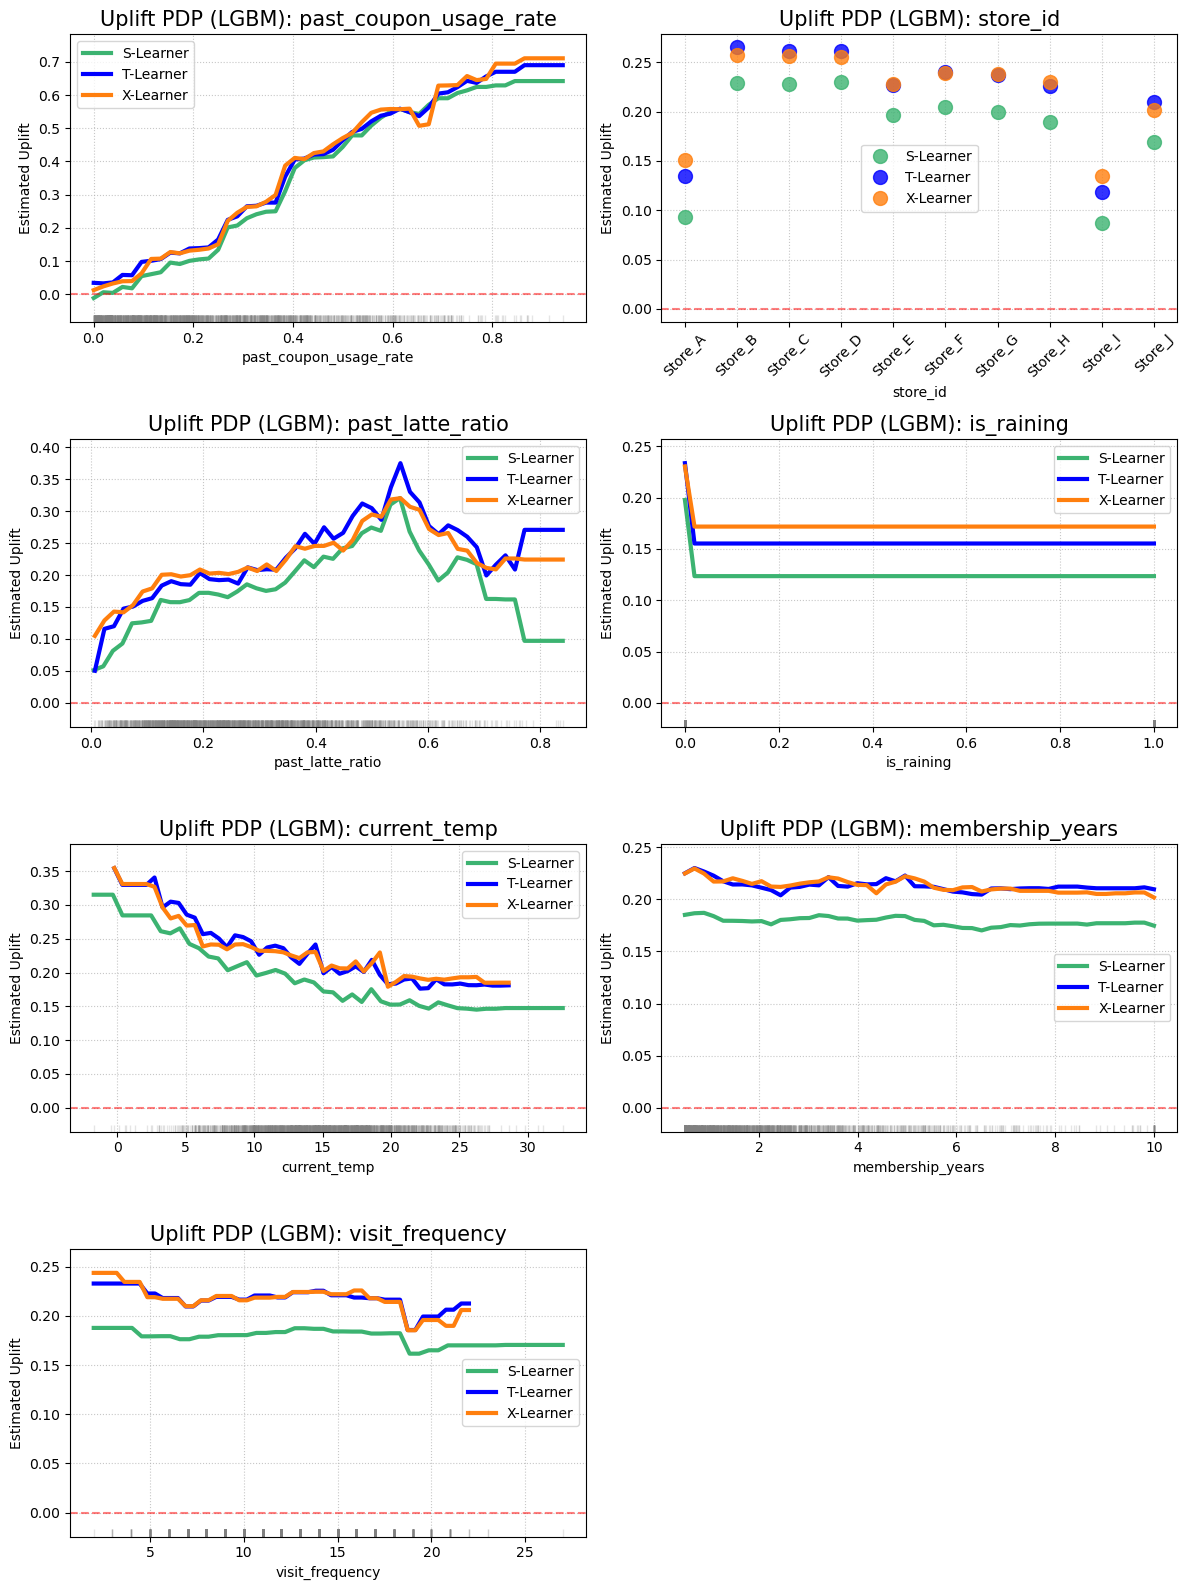

In [81]:
# plot uplift pdp
# 特徴量をリスト指定してまとめてプロット

# 特徴量のリスト
target_features = features_x_ranked_by_shap
# target_features = ['past_coupon_usage_rate', 'past_latte_ratio', 'visit_frequency', 'store_id']

# 呼び出し用の設定
learner_configs = {
    's': {'X': X_s_test, 'feats': features_s, 'models': {'model': model_s}},
    't': {'X': X_t_test, 'feats': features,   'models': {'model_t': model_t, 'model_c': model_c}},
    'x': {'X': X_t_test, 'feats': features,   'models': {'reg_t': reg_t, 'reg_c': reg_c, 'model_g': g}}
}

# 実行
plot_all_uplift_comparisons(target_features, X_s_test, X_t_test, learner_configs)

In [82]:
# 「クーポン利用率」が強い
# 読み解き： 過去にクーポンを使った経験が高いほど、リフト（純増確率）も高くなる傾向。0.7あたりからは頭打ち。
# 戦略： 「例えばクーポン利用率が0.4以上の人」をターゲットにすることで、純増期待しやすい。

# 「ラテ率」にはスイートスポットがある
# 読み解き： ラテ率が 0.6（60%）手前 くらいまではリフトが上がるけど、0.6を超えると低下。
# 戦略： ラテ率が極端に高い「超・常連さん」は、クーポンをあげてもあげなくても勝手に買う（＝増分がない）から、あえてクーポンを送らなくてもいい層っぽい。

# 「気温」は低いほど効きそう
# 読み解き： 気温が5度以下くらいのときはリフトが0.3以上なのが、暖かくなるにつれてリフトは下がっている。
# 戦略： 「寒い日ほどクーポンを配る価値が高い」ということがわかる。寒いとラテを飲みたくなるけど、そこにクーポンという「最後の一押し」があると、より多くの人が動いてくれそう。


# T-Learner（青）が「強気」な理由: 
# 処置群と対照群を完全に別のモデルで学習するから、それぞれの「ノイズ」や「外れ値」の影響をダイレクトに受けて、リフトを過大評価（Overestimate）しやすいん。「本当はそこまで差がないのに、たまたま差が出たところ」を全力で拾いに行っちゃう感じ。

# S-Learner（緑）が「控えめ」な理由: 
# 全データを1つのモデルで学習するから、「処置フラグ」の影響力が他の強い変数（来店頻度など）に埋もれやすい。モデルが保守的になり「とりあえず平均的なリフト」を出す傾向（Regularization的な効果）があるから、低めに出やすい。

# X-Learner（オレンジ）が「中庸（バランス型）」な理由: 
# 処置群ベースと対照群ベースの両方の視点（tau_t, tau_c）を、傾向スコア（g）で賢くブレンドしているから。Tの「過剰な反応」を抑えつつ、Sの「埋もれ」を解消して、「最も現実的な落とし所」を探し当てている感じ。